Check Python environment

In [3]:
# ============================================================
# Check Python environment
# ============================================================

import sys
import platform

# Show Python version
print("Python version:")
print(sys.version)

# Show exact Python executable used by this notebook
print("\nPython executable:")
print(sys.executable)

# Show operating system information
print("\nOperating system:")
print(platform.platform())

Python version:
3.14.5 (main, May 10 2026, 10:21:34) [Clang 21.0.0 (clang-2100.0.123.102)]

Python executable:
/Users/pratapgurung/OSINT/.venv/bin/python

Operating system:
macOS-26.5.1-arm64-arm-64bit-Mach-O


In [4]:
# ============================================================
# Install required packages
# ============================================================

import sys

# Install packages into the exact Python environment used by this notebook
!{sys.executable} -m pip install --upgrade pip

!{sys.executable} -m pip install \
    telethon \
    pandas \
    numpy \
    sentence-transformers \
    scikit-learn \
    networkx \
    pyvis \
    matplotlib \
    langdetect

In [5]:
# ============================================================
# Import and verify packages
# ============================================================

import pandas as pd
import numpy as np
import re
import os
import json
import math
from datetime import datetime, timedelta
from urllib.parse import urlparse
from collections import Counter, defaultdict

# Telegram API client
from telethon import TelegramClient
from telethon.tl.types import User, Channel, Chat

# Semantic embeddings and similarity
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Network analysis and visualization
import networkx as nx
from pyvis.network import Network

# Language detection
from langdetect import detect, DetectorFactory

# Make language detection deterministic
DetectorFactory.seed = 42

print("All packages imported successfully.")

All packages imported successfully.


# Project configuration

In [6]:
# ============================================================
# SERIAL 1 — CELL 4
# Project configuration
# ============================================================

import os
from datetime import datetime, timezone

# ------------------------------------------------------------
# 1. Channel list
# ------------------------------------------------------------
# Add Telegram usernames without @.
# Keep casing as given, but we will normalize later where needed.
CHANNELS = [
    "officialabplive",
    "WIONEWSCHANNEL",
    # "rtnews",
]

# ------------------------------------------------------------
# 2. Collection strategy
# ------------------------------------------------------------
# Recommended for channel correlation:
# Use a shared date window instead of only a fixed message limit.
#
# Why:
# If Channel A posts 500 messages in 2 days and Channel B posts
# 500 messages over 2 years, correlation analysis becomes biased.
#
# Options:
#   "date_window"  = collect messages within START_DATE and END_DATE
#   "message_limit" = collect latest N messages from each channel
#
COLLECTION_MODE = "date_window"

# Shared analysis window.
# Use UTC dates because Telegram timestamps are usually UTC.
START_DATE = "2025-08-01"
END_DATE = "2025-08-31"

# Keep this as a safety cap so collection does not run forever.
# In date_window mode, this is the maximum messages per channel.
MESSAGE_LIMIT_PER_CHANNEL = 3000

# Minimum text length to keep a message for analysis.
MIN_TEXT_LENGTH = 10

# Timezone note.
TIMEZONE = "UTC"

# ------------------------------------------------------------
# 3. Analysis settings
# ------------------------------------------------------------

# For temporal correlation, we will later compare posting behaviour
# in hourly or daily buckets.
TIME_BUCKET = "hour"  # options later: "hour", "day"

# For detecting near-simultaneous posting patterns later.
COORDINATION_WINDOW_MINUTES = 30

# For lead-lag analysis later.
LEAD_LAG_WINDOW_HOURS = 24

# ------------------------------------------------------------
# 4. Output settings
# ------------------------------------------------------------

OUTPUT_DIR = "telegram_osint_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 5. Convert dates to timezone-aware UTC datetime objects
# ------------------------------------------------------------

START_DATETIME = datetime.fromisoformat(START_DATE).replace(tzinfo=timezone.utc)
END_DATETIME = datetime.fromisoformat(END_DATE).replace(tzinfo=timezone.utc)

# End date should include the full day, so add 23:59:59.
END_DATETIME = END_DATETIME.replace(hour=23, minute=59, second=59)

# ------------------------------------------------------------
# 6. Print configuration summary
# ------------------------------------------------------------

print("Configuration loaded.")
print("Channels configured:", CHANNELS)
print("Collection mode:", COLLECTION_MODE)

if COLLECTION_MODE == "date_window":
    print("Collection window:", START_DATETIME, "to", END_DATETIME)
    print("Safety message cap per channel:", MESSAGE_LIMIT_PER_CHANNEL)
else:
    print("Message limit per channel:", MESSAGE_LIMIT_PER_CHANNEL)

print("Minimum text length:", MIN_TEXT_LENGTH)
print("Timezone:", TIMEZONE)
print("Output folder:", OUTPUT_DIR)

Configuration loaded.
Channels configured: ['officialabplive', 'WIONEWSCHANNEL']
Collection mode: date_window
Collection window: 2025-08-01 00:00:00+00:00 to 2025-08-31 23:59:59+00:00
Safety message cap per channel: 3000
Minimum text length: 10
Timezone: UTC
Output folder: telegram_osint_outputs


In [7]:
# ============================================================
# Telegram API credentials
# ============================================================

# Replace these with your Telegram developer credentials
API_ID = 33950223
API_HASH = "e7cebfb1808375747e838058be8ea2e9"

# Local session file name.
# Once login succeeds, Telethon stores your session locally.
SESSION_NAME = "telegram_osint_session"

print("Telegram API configuration prepared.")

Telegram API configuration prepared.


In [9]:
# ============================================================
# Connect to Telegram
# ============================================================

# Create the Telegram client
client = TelegramClient(
    SESSION_NAME,
    API_ID,
    API_HASH
)

# Start the client.
# On first run, Telegram may ask for phone number, login code, and 2FA password.
await client.start()

# Verify authenticated account
me = await client.get_me()

print("Connected to Telegram successfully.")
print("Account name:", me.first_name)
print("Username:", f"@{me.username}" if me.username else "No username")
print("User ID:", me.id)

Connected to Telegram successfully.
Account name: Kkkk
Username: No username
User ID: 8653239004


Cannot get difference since the account is likely misusing the session: database is locked
Unhandled exception from keepalive_handle after cancelling <class '_asyncio.Task'> (<Task finished name='Task-74' coro=<UpdateMethods._keepalive_loop() done, defined at /Users/pratapgurung/OSINT/.venv/lib/python3.14/site-packages/telethon/client/updates.py:516> exception=OperationalError('database is locked')>)
Traceback (most recent call last):
  File "/Users/pratapgurung/OSINT/.venv/lib/python3.14/site-packages/telethon/helpers.py", line 176, in _cancel
    await task
  File "/Users/pratapgurung/OSINT/.venv/lib/python3.14/site-packages/telethon/client/updates.py", line 552, in _keepalive_loop
    await self._save_states_and_entities()
  File "/Users/pratapgurung/OSINT/.venv/lib/python3.14/site-packages/telethon/client/telegrambaseclient.py", line 709, in _save_states_and_entities
    self.session.process_entities(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        types.contacts.ResolvedPeer(None, [typ

# Validating Channels

In [8]:
# ============================================================
# Validate all configured channels
# ============================================================

from telethon.tl.types import User, Channel, Chat

validation_results = []

print("=" * 100)
print("VALIDATING CHANNELS")
print("=" * 100)

for target in CHANNELS:

    print(f"\nChecking: {target}")

    try:

        entity = await client.get_entity(target)

        # Determine entity type
        if isinstance(entity, User):
            entity_type = "User"

        elif isinstance(entity, Channel):

            if getattr(entity, "broadcast", False):
                entity_type = "Broadcast Channel"

            elif getattr(entity, "megagroup", False):
                entity_type = "Mega Group"

            else:
                entity_type = "Channel"

        elif isinstance(entity, Chat):
            entity_type = "Group"

        else:
            entity_type = "Unknown"

        row = {
            "input": target,
            "status": "SUCCESS",
            "entity_type": entity_type,
            "id": getattr(entity, "id", None),
            "title": getattr(entity, "title", None),
            "username": getattr(entity, "username", None)
        }

        validation_results.append(row)

        print(f"✓ SUCCESS")
        print(f"  Type: {entity_type}")
        print(f"  Title: {row['title']}")
        print(f"  Username: {row['username']}")
        print(f"  ID: {row['id']}")

    except Exception as e:

        validation_results.append({
            "input": target,
            "status": "FAILED",
            "entity_type": None,
            "id": None,
            "title": None,
            "username": None
        })

        print(f"✗ FAILED")
        print(f"  Error: {str(e)}")

# Convert results to DataFrame
channel_validation_df = pd.DataFrame(validation_results)

print("\n")
print("=" * 100)
print("SUMMARY")
print("=" * 100)

display(channel_validation_df)

VALIDATING CHANNELS

Checking: officialabplive
✓ SUCCESS
  Type: Broadcast Channel
  Title: ABPLIVE
  Username: officialabplive
  ID: 1938218390

Checking: WIONEWSCHANNEL
✓ SUCCESS
  Type: Broadcast Channel
  Title: WION
  Username: WIONEWSCHANNEL
  ID: 1439201939


SUMMARY


,input,status,entity_type,id,title,username
0,officialabplive,SUCCESS,Broadcast Channel,1938218390,ABPLIVE,officialabplive
1,WIONEWSCHANNEL,SUCCESS,Broadcast Channel,1439201939,WION,WIONEWSCHANNEL


# Multi-channel message collection into one pandas DataFrame

In [9]:
# ============================================================
# Helper functions for extracting OSINT signals
# ============================================================

import re
from urllib.parse import urlparse

def clean_text(text):
    """
    Normalize Telegram message text while preserving useful OSINT content.
    """
    if not text:
        return ""
    
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def extract_urls(text):
    """
    Extract normal URLs and Telegram links from message text.
    """
    if not text:
        return []
    
    return re.findall(r"https?://\S+|t\.me/\S+", text)


def extract_domains(urls):
    """
    Extract domains from URLs.
    Example:
    https://example.com/article -> example.com
    """
    domains = []

    for url in urls:
        try:
            if url.startswith("t.me/"):
                domain = "t.me"
            else:
                parsed = urlparse(url)
                domain = parsed.netloc.replace("www.", "")
            
            if domain:
                domains.append(domain)
        except:
            pass

    return domains


def extract_mentions(text):
    """
    Extract Telegram @mentions from message text.
    """
    if not text:
        return []
    
    return re.findall(r"@([A-Za-z0-9_]{5,})", text)


def extract_hashtags(text):
    """
    Extract hashtags from message text.
    """
    if not text:
        return []
    
    return re.findall(r"#(\w+)", text)


def safe_language_detect(text):
    """
    Detect language safely.
    Returns 'unknown' if detection fails or text is too short.
    """
    try:
        if not text or len(text.strip()) < 20:
            return "unknown"
        return detect(text)
    except:
        return "unknown"


print("Helper functions loaded.")

Helper functions loaded.


In [10]:
# ============================================================
# SERIAL 2 — CELL 10
# Collect messages from one channel
# ============================================================

async def collect_channel_messages(channel_name, limit=MESSAGE_LIMIT_PER_CHANNEL):
    """
    Collect messages from a single Telegram channel.

    Returns:
        pandas DataFrame where each row is one message.
    """

    # Resolve Telegram channel/entity
    entity = await client.get_entity(channel_name)

    rows = []

    async for msg in client.iter_messages(entity, limit=limit):

        original_text = msg.text or ""
        cleaned = clean_text(original_text)

        # Skip very short or empty messages
        if len(cleaned) < MIN_TEXT_LENGTH:
            continue

        urls = extract_urls(cleaned)
        domains = extract_domains(urls)
        mentions = extract_mentions(cleaned)
        hashtags = extract_hashtags(cleaned)

        rows.append({
            "channel": channel_name,
            "channel_title": getattr(entity, "title", None),
            "channel_username": getattr(entity, "username", None),
            "channel_id": getattr(entity, "id", None),

            "message_id": msg.id,
            "date": msg.date,
            "original_text": original_text,
            "clean_text": cleaned,

            "views": getattr(msg, "views", None),
            "forwards": getattr(msg, "forwards", None),

            "urls": urls,
            "domains": domains,
            "mentions": mentions,
            "hashtags": hashtags,

            "forwarded_from": str(getattr(msg, "fwd_from", None)),
            "reply_to_msg_id": getattr(msg, "reply_to_msg_id", None),
            "has_media": msg.media is not None,

            "language": safe_language_detect(cleaned),

            "message_link": f"https://t.me/{channel_name}/{msg.id}"
        })

    return pd.DataFrame(rows)

In [11]:
# ============================================================
# Collect messages from all valid channels
# ============================================================

all_channel_dfs = []

print("=" * 100)
print("COLLECTING TELEGRAM MESSAGES")
print("=" * 100)

for channel_name in CHANNELS:

    print(f"\nCollecting from: {channel_name}")

    try:
        channel_df = await collect_channel_messages(
            channel_name,
            limit=MESSAGE_LIMIT_PER_CHANNEL
        )

        all_channel_dfs.append(channel_df)

        print(f"✓ Collected {len(channel_df)} usable messages")

    except Exception as e:
        print(f"✗ Failed to collect from {channel_name}")
        print("Error:", str(e))


# Combine all collected channel DataFrames
if all_channel_dfs:
    all_messages = pd.concat(all_channel_dfs, ignore_index=True)
else:
    all_messages = pd.DataFrame()

print("\n" + "=" * 100)
print("COLLECTION COMPLETE")
print("=" * 100)
print("Total usable messages:", len(all_messages))
print("Total channels collected:", all_messages["channel"].nunique() if len(all_messages) else 0)

COLLECTING TELEGRAM MESSAGES

✓ Collected 3000 usable messages

✓ Collected 2762 usable messages

COLLECTION COMPLETE
Total usable messages: 5762
Total channels collected: 2


In [12]:
# ============================================================
# Normalize dates and add helper columns
# ============================================================

# Convert date column to pandas datetime
all_messages["date"] = pd.to_datetime(all_messages["date"], errors="coerce")

# Date-only field for daily analysis
all_messages["date_only"] = all_messages["date"].dt.date

# Hour field for posting pattern analysis
all_messages["hour"] = all_messages["date"].dt.hour

# Text size features
all_messages["text_length"] = all_messages["clean_text"].str.len()
all_messages["word_count"] = all_messages["clean_text"].str.split().str.len()

# Fill missing numeric values
all_messages["views"] = all_messages["views"].fillna(0)
all_messages["forwards"] = all_messages["forwards"].fillna(0)

print("Data normalized.")
print("Rows:", len(all_messages))
print("Columns:", len(all_messages.columns))

display(all_messages.head())

Data normalized.
Rows: 5762
Columns: 23


,channel,channel_title,channel_username,channel_id,message_id,date,original_text,clean_text,views,forwards,...,hashtags,forwarded_from,reply_to_msg_id,has_media,language,message_link,date_only,hour,text_length,word_count
0,officialabplive,ABPLIVE,officialabplive,1938218390,43083,2026-06-16 11:16:02+00:00,[**iPhone Fold May Not Make It To Shelves This...,[**iPhone Fold May Not Make It To Shelves This...,8,0,...,[],None,None,True,en,https://t.me/officialabplive/43083,2026-06-16,11,525,45
1,officialabplive,ABPLIVE,officialabplive,1938218390,43082,2026-06-16 10:58:03+00:00,[**GTA 6 Isn't Out Yet But Someone Is Already ...,[**GTA 6 Isn't Out Yet But Someone Is Already ...,8,0,...,[],None,None,True,en,https://t.me/officialabplive/43082,2026-06-16,10,509,50
2,officialabplive,ABPLIVE,officialabplive,1938218390,43081,2026-06-16 10:34:03+00:00,[**Apple Is Shutting Three Stores But Only One...,[**Apple Is Shutting Three Stores But Only One...,9,0,...,[],None,None,True,en,https://t.me/officialabplive/43081,2026-06-16,10,535,46
3,officialabplive,ABPLIVE,officialabplive,1938218390,43080,2026-06-16 10:08:02+00:00,"[**Standard iPhone 18 Skipping September, Only...","[**Standard iPhone 18 Skipping September, Only...",10,0,...,[],None,None,True,en,https://t.me/officialabplive/43080,2026-06-16,10,545,48
4,officialabplive,ABPLIVE,officialabplive,1938218390,43079,2026-06-16 07:16:03+00:00,[**FPI Ownership In Indian Equities Hits 15-Ye...,[**FPI Ownership In Indian Equities Hits 15-Ye...,13,0,...,[],None,None,True,en,https://t.me/officialabplive/43079,2026-06-16,7,466,33


# Individual channel profile

In [13]:
# ============================================================
# Confirm all_messages DataFrame is ready
# ============================================================

# Check that all_messages exists and has data
print("Total rows in all_messages:", len(all_messages))
print("Total channels:", all_messages["channel"].nunique())

# Show available columns
print("\nColumns available:")
for col in all_messages.columns:
    print("-", col)

# Preview first few rows
display(all_messages.head())

Total rows in all_messages: 5762
Total channels: 2

Columns available:
- channel
- channel_title
- channel_username
- channel_id
- message_id
- date
- original_text
- clean_text
- views
- forwards
- urls
- domains
- mentions
- hashtags
- forwarded_from
- reply_to_msg_id
- has_media
- language
- message_link
- date_only
- hour
- text_length
- word_count


,channel,channel_title,channel_username,channel_id,message_id,date,original_text,clean_text,views,forwards,...,hashtags,forwarded_from,reply_to_msg_id,has_media,language,message_link,date_only,hour,text_length,word_count
0,officialabplive,ABPLIVE,officialabplive,1938218390,43083,2026-06-16 11:16:02+00:00,[**iPhone Fold May Not Make It To Shelves This...,[**iPhone Fold May Not Make It To Shelves This...,8,0,...,[],None,None,True,en,https://t.me/officialabplive/43083,2026-06-16,11,525,45
1,officialabplive,ABPLIVE,officialabplive,1938218390,43082,2026-06-16 10:58:03+00:00,[**GTA 6 Isn't Out Yet But Someone Is Already ...,[**GTA 6 Isn't Out Yet But Someone Is Already ...,8,0,...,[],None,None,True,en,https://t.me/officialabplive/43082,2026-06-16,10,509,50
2,officialabplive,ABPLIVE,officialabplive,1938218390,43081,2026-06-16 10:34:03+00:00,[**Apple Is Shutting Three Stores But Only One...,[**Apple Is Shutting Three Stores But Only One...,9,0,...,[],None,None,True,en,https://t.me/officialabplive/43081,2026-06-16,10,535,46
3,officialabplive,ABPLIVE,officialabplive,1938218390,43080,2026-06-16 10:08:02+00:00,"[**Standard iPhone 18 Skipping September, Only...","[**Standard iPhone 18 Skipping September, Only...",10,0,...,[],None,None,True,en,https://t.me/officialabplive/43080,2026-06-16,10,545,48
4,officialabplive,ABPLIVE,officialabplive,1938218390,43079,2026-06-16 07:16:03+00:00,[**FPI Ownership In Indian Equities Hits 15-Ye...,[**FPI Ownership In Indian Equities Hits 15-Ye...,13,0,...,[],None,None,True,en,https://t.me/officialabplive/43079,2026-06-16,7,466,33


In [14]:
# ============================================================
# REPAIR CELL — Rebuild missing channel profile fields
# ============================================================

# Make sure date and helper fields exist
all_messages["date"] = pd.to_datetime(all_messages["date"], errors="coerce")
all_messages["text_length"] = all_messages["clean_text"].astype(str).str.len()
all_messages["word_count"] = all_messages["clean_text"].astype(str).str.split().str.len()

# Rebuild channel_profiles cleanly
channel_profiles = (
    all_messages
    .groupby("channel")
    .agg(
        channel_title=("channel_title", "first"),
        channel_username=("channel_username", "first"),
        channel_id=("channel_id", "first"),

        total_messages=("message_id", "count"),
        first_seen=("date", "min"),
        last_seen=("date", "max"),

        total_views=("views", "sum"),
        avg_views=("views", "mean"),
        max_views=("views", "max"),

        total_forwards=("forwards", "sum"),
        avg_forwards=("forwards", "mean"),
        max_forwards=("forwards", "max"),

        media_messages=("has_media", "sum"),
        avg_text_length=("text_length", "mean"),
        avg_word_count=("word_count", "mean")
    )
    .reset_index()
)

# Media percentage
channel_profiles["media_percent"] = (
    channel_profiles["media_messages"] / channel_profiles["total_messages"] * 100
).round(2)

# Active days and messages per day
channel_profiles["active_days"] = (
    (channel_profiles["last_seen"] - channel_profiles["first_seen"]).dt.days + 1
).replace(0, 1)

channel_profiles["messages_per_day"] = (
    channel_profiles["total_messages"] / channel_profiles["active_days"]
).round(2)

# Peak posting hour
if "hour" not in all_messages.columns:
    all_messages["hour"] = all_messages["date"].dt.hour

hour_counts = (
    all_messages
    .groupby(["channel", "hour"])
    .size()
    .reset_index(name="post_count")
)

peak_hours = (
    hour_counts
    .sort_values(["channel", "post_count"], ascending=[True, False])
    .groupby("channel")
    .head(1)
    .rename(columns={
        "hour": "peak_posting_hour",
        "post_count": "peak_hour_post_count"
    })
)

channel_profiles = channel_profiles.merge(
    peak_hours[["channel", "peak_posting_hour", "peak_hour_post_count"]],
    on="channel",
    how="left"
)

# Top language
language_counts = (
    all_messages
    .groupby(["channel", "language"])
    .size()
    .reset_index(name="language_count")
)

top_languages = (
    language_counts
    .sort_values(["channel", "language_count"], ascending=[True, False])
    .groupby("channel")
    .head(1)
    .rename(columns={
        "language": "top_language",
        "language_count": "top_language_count"
    })
)

channel_profiles = channel_profiles.merge(
    top_languages[["channel", "top_language", "top_language_count"]],
    on="channel",
    how="left"
)

# Round readable numeric fields
for col in ["avg_views", "avg_forwards", "avg_text_length", "avg_word_count"]:
    channel_profiles[col] = channel_profiles[col].round(2)

print("channel_profiles rebuilt successfully.")
display(channel_profiles)

channel_profiles rebuilt successfully.


,channel,channel_title,channel_username,channel_id,total_messages,first_seen,last_seen,total_views,avg_views,max_views,...,media_messages,avg_text_length,avg_word_count,media_percent,active_days,messages_per_day,peak_posting_hour,peak_hour_post_count,top_language,top_language_count
0,WIONEWSCHANNEL,WION,WIONEWSCHANNEL,1439201939,2762,2020-01-16 12:11:36+00:00,2025-04-22 06:37:34+00:00,4355415,1576.91,13654,...,2708,292.73,44.97,98.04,1923,1.44,5,464,en,2476
1,officialabplive,ABPLIVE,officialabplive,1938218390,3000,2026-01-24 12:22:03+00:00,2026-06-16 11:16:02+00:00,55283,18.43,220,...,3000,524.00,42.84,100.00,143,20.98,5,337,en,3000


# Channel Activity Analysis

## Objective

The first step in understanding a Telegram channel is to analyse its overall activity.

This analysis answers the following questions:

- Which channel publishes the most content?
- Which channel is the most active over time?
- Is the collection balanced across channels?
- Are there channels that are unusually quiet or extremely active?

At this stage, we are **not** making any conclusions about influence or narratives. We are only establishing the baseline activity of each channel.

This information will later help contextualise narrative volume and correlation scores.

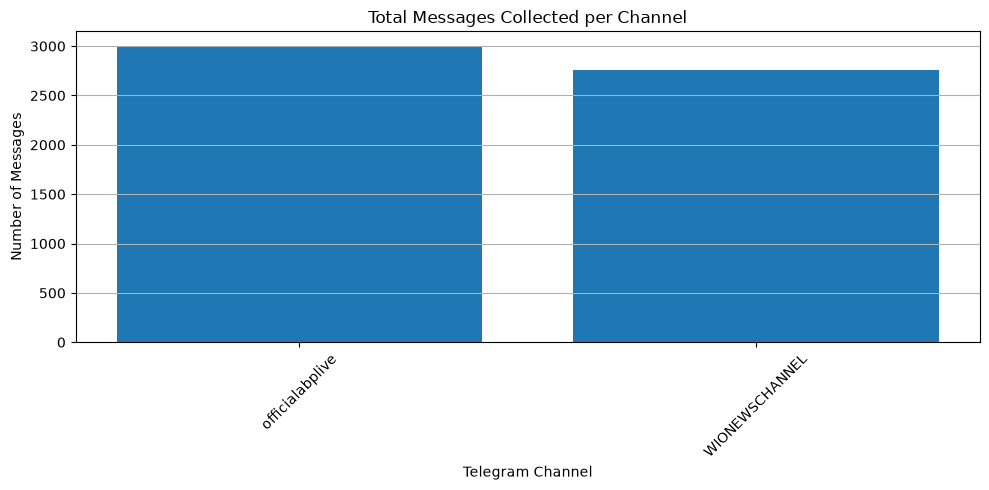

In [15]:
# ============================================================
# SERIAL 3A — CHANNEL ACTIVITY
# Compare total messages collected from each channel
# ============================================================

import matplotlib.pyplot as plt

# Sort channels by message count
activity_df = (
    channel_profiles
    .sort_values("total_messages", ascending=False)
)

# Create figure
plt.figure(figsize=(10,5))

plt.bar(
    activity_df["channel"],
    activity_df["total_messages"]
)

plt.title("Total Messages Collected per Channel")

plt.xlabel("Telegram Channel")

plt.ylabel("Number of Messages")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [16]:
# ============================================================
# Analyst Interpretation
# ============================================================

print("="*80)
print("CHANNEL ACTIVITY SUMMARY")
print("="*80)

highest = activity_df.iloc[0]
lowest = activity_df.iloc[-1]

print(f"\nMost active channel:")
print(f"• {highest['channel']}")
print(f"• {highest['total_messages']} collected messages")

print(f"\nLeast active channel:")
print(f"• {lowest['channel']}")
print(f"• {lowest['total_messages']} collected messages")

print("\nObservations:")

if highest["total_messages"] > lowest["total_messages"] * 2:
    print("- Large difference in collected message volume between channels.")
    print("- Future comparisons should preferably use a common time window.")
else:
    print("- Collection volume is relatively balanced.")

print("- Message count alone does NOT indicate influence.")
print("- It only measures publishing activity.")

CHANNEL ACTIVITY SUMMARY

Most active channel:
• officialabplive
• 3000 collected messages

Least active channel:
• WIONEWSCHANNEL
• 2762 collected messages

Observations:
- Collection volume is relatively balanced.
- Message count alone does NOT indicate influence.
- It only measures publishing activity.


# Posting Behaviour Analysis

## Objective

This section examines when each Telegram channel publishes content.

The analysis answers the following questions:

- During which hours is the channel most active?
- Is posting evenly distributed throughout the day?
- Does the channel exhibit scheduled publishing behaviour?
- Are there noticeable spikes in activity?

Posting behaviour provides valuable contextual information that can later be compared across multiple channels to identify similar operational patterns or potential coordination.

**Important**

This analysis is descriptive only. Similar posting times alone do **not** imply coordination.

In [17]:
# ============================================================
# SERIAL 3B — POSTING BEHAVIOUR KPIs
# ============================================================

print("=" * 80)
print("POSTING BEHAVIOUR DASHBOARD")
print("=" * 80)

print(f"\nChannels analysed : {all_messages['channel'].nunique()}")
print(f"Total messages    : {len(all_messages):,}")

print("\nPeak posting hour by channel")

display(
    channel_profiles[
        [
            "channel",
            "peak_posting_hour",
            "peak_hour_post_count",
            "messages_per_day"
        ]
    ]
)

POSTING BEHAVIOUR DASHBOARD

Channels analysed : 2
Total messages    : 5,762

Peak posting hour by channel


,channel,peak_posting_hour,peak_hour_post_count,messages_per_day
0,WIONEWSCHANNEL,5,464,1.44
1,officialabplive,5,337,20.98


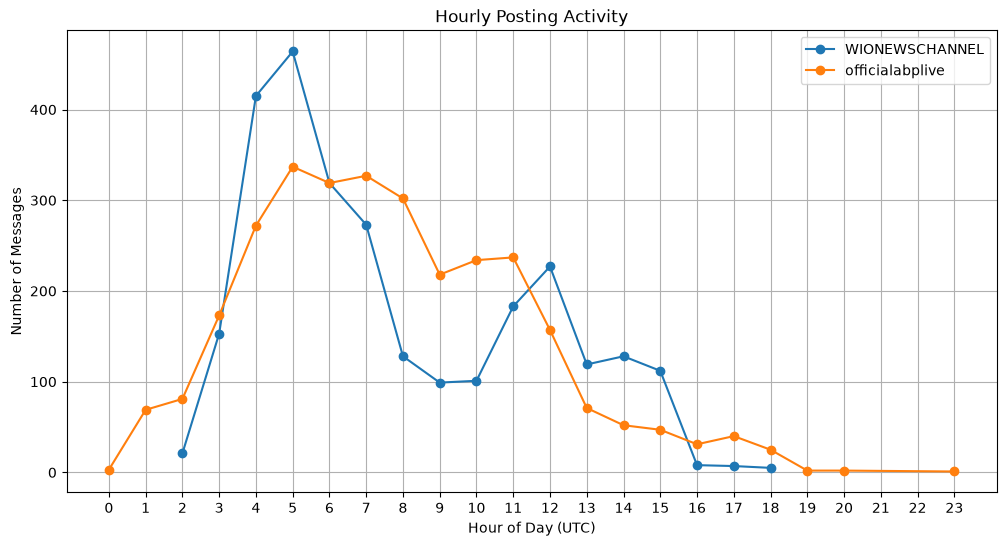

In [18]:
import matplotlib.pyplot as plt

# Count messages by channel and hour
hourly_activity = (
    all_messages
    .groupby(["channel", "hour"])
    .size()
    .reset_index(name="messages")
)

plt.figure(figsize=(12,6))

for channel in hourly_activity["channel"].unique():

    subset = hourly_activity[
        hourly_activity["channel"] == channel
    ]

    plt.plot(
        subset["hour"],
        subset["messages"],
        marker="o",
        label=channel
    )

plt.xticks(range(24))
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Number of Messages")
plt.title("Hourly Posting Activity")
plt.grid(True)
plt.legend()

plt.show()

In [19]:
hour_matrix = (
    all_messages
    .groupby(["channel","hour"])
    .size()
    .unstack(fill_value=0)
)

display(hour_matrix)

hour,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,23
channel,,,,,,,,,,,,,,,,,,,,,
WIONEWSCHANNEL,0,0,21,153,415,464,319,273,128,99,...,227,119,128,112,8,7,5,0,0,0
officialabplive,3,69,81,173,272,337,319,327,302,218,...,157,71,52,47,31,40,25,2,2,1


In [20]:
print("=" * 80)
print("ANALYST INTERPRETATION")
print("=" * 80)

for _, row in channel_profiles.iterrows():

    print(f"\nChannel: {row['channel']}")

    print(f"• Peak posting hour : {int(row['peak_posting_hour']):02d}:00 UTC")

    print(f"• Messages during peak hour : {int(row['peak_hour_post_count'])}")

    print(f"• Average messages/day : {row['messages_per_day']:.2f}")

    print()

print("Observations")

print("- Posting behaviour establishes a behavioural fingerprint for each channel.")
print("- Similar posting schedules do not imply coordination.")
print("- Later, posting behaviour will become one feature in the overall correlation score.")

ANALYST INTERPRETATION

Channel: WIONEWSCHANNEL
• Peak posting hour : 05:00 UTC
• Messages during peak hour : 464
• Average messages/day : 1.44


Channel: officialabplive
• Peak posting hour : 05:00 UTC
• Messages during peak hour : 337
• Average messages/day : 20.98

Observations
- Posting behaviour establishes a behavioural fingerprint for each channel.
- Similar posting schedules do not imply coordination.
- Later, posting behaviour will become one feature in the overall correlation score.


# Audience Engagement Analysis

## Objective

This section analyses how much attention each channel's messages receive.

The analysis focuses on:

- Average views per message
- Total views
- Average forwards
- Total forwards
- Most viewed messages
- Most forwarded messages
- Whether engagement is concentrated in a few posts or distributed evenly

Engagement should not be interpreted as influence by itself. A channel may have high views because of subscriber count, reposting behaviour, platform recommendation, or historical audience size.

This section provides a baseline for later influence and amplification analysis.

In [21]:
# ============================================================
# SERIAL 3C — ENGAGEMENT KPI PANEL
# ============================================================

print("=" * 80)
print("AUDIENCE ENGAGEMENT DASHBOARD")
print("=" * 80)

print(f"\nChannels analysed : {all_messages['channel'].nunique()}")
print(f"Total messages    : {len(all_messages):,}")
print(f"Total views       : {int(all_messages['views'].sum()):,}")
print(f"Total forwards    : {int(all_messages['forwards'].sum()):,}")

print("\nEngagement summary by channel:")

engagement_summary = channel_profiles[
    [
        "channel",
        "total_messages",
        "total_views",
        "avg_views",
        "max_views",
        "total_forwards",
        "avg_forwards",
        "max_forwards"
    ]
].sort_values("avg_views", ascending=False)

display(engagement_summary)

AUDIENCE ENGAGEMENT DASHBOARD

Channels analysed : 2
Total messages    : 5,762
Total views       : 4,410,698
Total forwards    : 10,051

Engagement summary by channel:


,channel,total_messages,total_views,avg_views,max_views,total_forwards,avg_forwards,max_forwards
0,WIONEWSCHANNEL,2762,4355415,1576.91,13654,9996,3.62,56
1,officialabplive,3000,55283,18.43,220,55,0.02,2


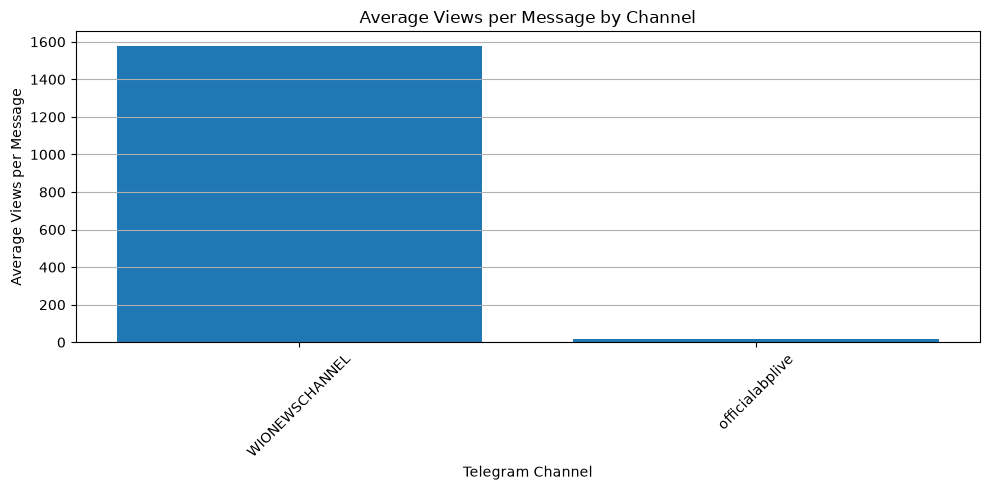

In [22]:
# ============================================================
# SERIAL 3C — AVERAGE VIEWS BY CHANNEL
# ============================================================

import matplotlib.pyplot as plt

views_df = (
    channel_profiles
    .sort_values("avg_views", ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(
    views_df["channel"],
    views_df["avg_views"]
)

plt.title("Average Views per Message by Channel")
plt.xlabel("Telegram Channel")
plt.ylabel("Average Views per Message")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

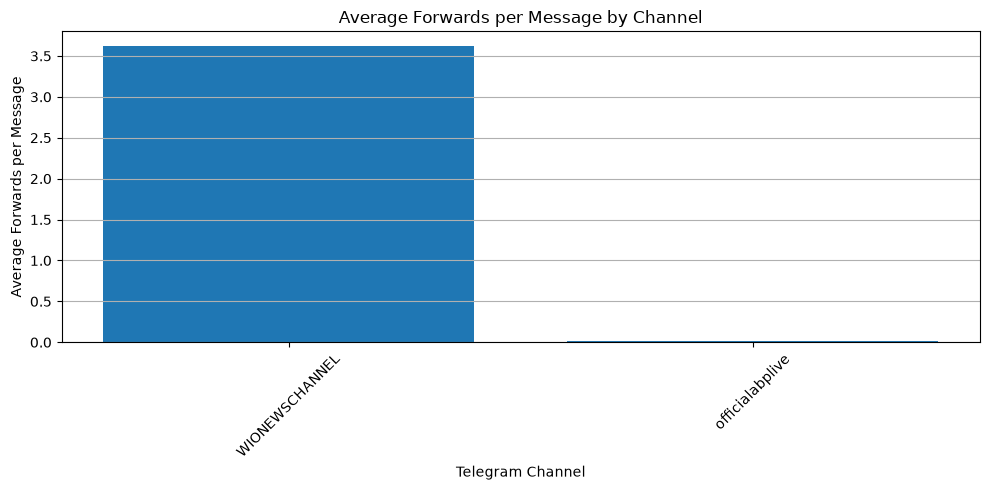

In [23]:
# ============================================================
# SERIAL 3C — AVERAGE FORWARDS BY CHANNEL
# ============================================================

forwards_df = (
    channel_profiles
    .sort_values("avg_forwards", ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(
    forwards_df["channel"],
    forwards_df["avg_forwards"]
)

plt.title("Average Forwards per Message by Channel")
plt.xlabel("Telegram Channel")
plt.ylabel("Average Forwards per Message")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

<Figure size 1000x500 with 0 Axes>

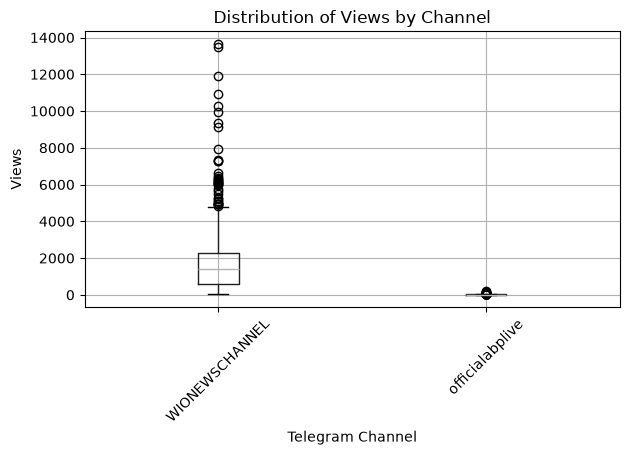

In [24]:
# ============================================================
# SERIAL 3C — VIEWS DISTRIBUTION BY CHANNEL
# ============================================================

plt.figure(figsize=(10,5))

all_messages.boxplot(
    column="views",
    by="channel",
    grid=True
)

plt.title("Distribution of Views by Channel")
plt.suptitle("")
plt.xlabel("Telegram Channel")
plt.ylabel("Views")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

<Figure size 1000x500 with 0 Axes>

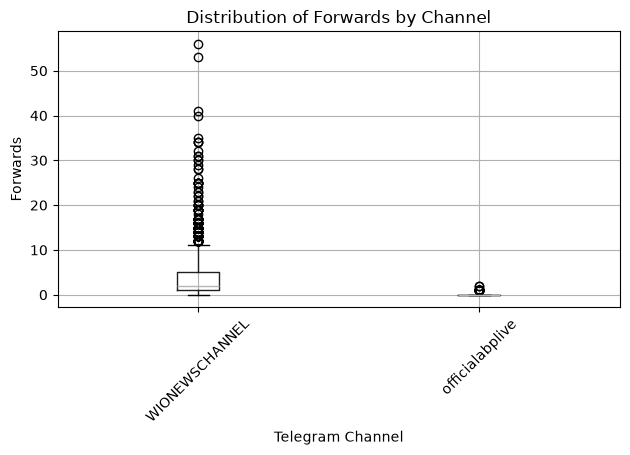

In [25]:
# ============================================================
# SERIAL 3C — FORWARDS DISTRIBUTION BY CHANNEL
# ============================================================

plt.figure(figsize=(10,5))

all_messages.boxplot(
    column="forwards",
    by="channel",
    grid=True
)

plt.title("Distribution of Forwards by Channel")
plt.suptitle("")
plt.xlabel("Telegram Channel")
plt.ylabel("Forwards")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [26]:
# ============================================================
# SERIAL 3C — TOP VIEWED MESSAGES
# ============================================================

top_viewed_messages = (
    all_messages
    .sort_values("views", ascending=False)
    [
        [
            "channel",
            "date",
            "views",
            "forwards",
            "clean_text",
            "message_link"
        ]
    ]
    .head(20)
)

display(top_viewed_messages)

,channel,date,views,forwards,clean_text,message_link
3003,WIONEWSCHANNEL,2024-04-23 06:00:24+00:00,13654,9,Two Malaysian navy choppers collide mid-air an...,https://t.me/WIONEWSCHANNEL/2964
3004,WIONEWSCHANNEL,2024-04-12 04:56:56+00:00,13468,7,Biden warns on Beijing's South China sea moves...,https://t.me/WIONEWSCHANNEL/2963
3005,WIONEWSCHANNEL,2024-04-08 12:06:11+00:00,11885,8,ISRO Chief S Somanath speaks to WION,https://t.me/WIONEWSCHANNEL/2962
3157,WIONEWSCHANNEL,2022-12-09 05:37:12+00:00,10917,13,*Gravitas as on 8th December 2022* *Gravitas: ...,https://t.me/WIONEWSCHANNEL/2809
3726,WIONEWSCHANNEL,2022-05-07 03:56:41+00:00,10300,56,#Gravitas | China is replacing all foreign com...,https://t.me/WIONEWSCHANNEL/2225
3006,WIONEWSCHANNEL,2024-04-08 12:05:59+00:00,9971,3,Moscow: Attacks on N-plant dangerous and other...,https://t.me/WIONEWSCHANNEL/2961
3009,WIONEWSCHANNEL,2024-01-22 05:47:57+00:00,9325,7,https://www.youtube.com/watch?v=v4VEffvl7zw,https://t.me/WIONEWSCHANNEL/2957
3002,WIONEWSCHANNEL,2024-09-03 06:04:59+00:00,9148,6,'Israel must retain key corridor' and other WI...,https://t.me/WIONEWSCHANNEL/2966
3007,WIONEWSCHANNEL,2024-04-08 04:58:50+00:00,7926,4,Russia's foreign minister arrives in China and...,https://t.me/WIONEWSCHANNEL/2960
3008,WIONEWSCHANNEL,2024-04-03 05:55:22+00:00,7323,3,"Quake jolts Taiwan, at least 4 dead and other ...",https://t.me/WIONEWSCHANNEL/2959


In [27]:
# ============================================================
# SERIAL 3C — TOP FORWARDED MESSAGES
# ============================================================

top_forwarded_messages = (
    all_messages
    .sort_values("forwards", ascending=False)
    [
        [
            "channel",
            "date",
            "views",
            "forwards",
            "clean_text",
            "message_link"
        ]
    ]
    .head(20)
)

display(top_forwarded_messages)

,channel,date,views,forwards,clean_text,message_link
3726,WIONEWSCHANNEL,2022-05-07 03:56:41+00:00,10300,56,#Gravitas | China is replacing all foreign com...,https://t.me/WIONEWSCHANNEL/2225
3488,WIONEWSCHANNEL,2022-07-18 05:26:25+00:00,3124,53,Gravitas Plus: The truth behind preserved and ...,https://t.me/WIONEWSCHANNEL/2466
3794,WIONEWSCHANNEL,2022-04-11 08:38:09+00:00,4378,41,#GravitasPlus | Are Electric Vehicles really c...,https://t.me/WIONEWSCHANNEL/2152
4521,WIONEWSCHANNEL,2021-06-12 08:59:48+00:00,2958,40,#Gravitas | Sexual abuse has been normalised i...,https://t.me/WIONEWSCHANNEL/1384
4037,WIONEWSCHANNEL,2021-12-18 05:10:52+00:00,4450,35,#Gravitas | Modern-day wars will be about cont...,https://t.me/WIONEWSCHANNEL/1902
3402,WIONEWSCHANNEL,2022-08-13 08:49:12+00:00,4627,34,#Gravitas | Johnson & Johnson will stop sellin...,https://t.me/WIONEWSCHANNEL/2557
4466,WIONEWSCHANNEL,2021-07-05 06:18:44+00:00,2291,34,Did you know non-stick cookware can be deadly?...,https://t.me/WIONEWSCHANNEL/1449
3740,WIONEWSCHANNEL,2022-04-30 07:26:06+00:00,4036,34,#Gravitas | German energy giants like Uniper a...,https://t.me/WIONEWSCHANNEL/2210
3854,WIONEWSCHANNEL,2022-03-11 09:19:29+00:00,4020,32,Gravitas | Newly published documents from the ...,https://t.me/WIONEWSCHANNEL/2091
4445,WIONEWSCHANNEL,2021-07-11 05:46:20+00:00,3945,31,#GravitasPlus | We're spending billions on bom...,https://t.me/WIONEWSCHANNEL/1471


In [28]:
# ============================================================
# SERIAL 3C — ENGAGEMENT ANALYST INTERPRETATION
# ============================================================

print("=" * 80)
print("ANALYST INTERPRETATION")
print("=" * 80)

highest_avg_views = engagement_summary.iloc[0]

print(f"\nHighest average views:")
print(f"• {highest_avg_views['channel']}")
print(f"• {highest_avg_views['avg_views']:.2f} average views per message")

highest_total_views = channel_profiles.sort_values(
    "total_views",
    ascending=False
).iloc[0]

print(f"\nHighest total views:")
print(f"• {highest_total_views['channel']}")
print(f"• {int(highest_total_views['total_views']):,} total views")

highest_avg_forwards = channel_profiles.sort_values(
    "avg_forwards",
    ascending=False
).iloc[0]

print(f"\nHighest average forwards:")
print(f"• {highest_avg_forwards['channel']}")
print(f"• {highest_avg_forwards['avg_forwards']:.2f} average forwards per message")

print("\nAnalyst notes:")
print("- Views indicate attention, but not necessarily influence.")
print("- Forwards are more relevant for amplification analysis than views.")
print("- Averages should be interpreted alongside distribution charts.")
print("- A single viral post can distort average engagement.")
print("- Top-performing messages should be reviewed manually for narrative or event context.")

ANALYST INTERPRETATION

Highest average views:
• WIONEWSCHANNEL
• 1576.91 average views per message

Highest total views:
• WIONEWSCHANNEL
• 4,355,415 total views

Highest average forwards:
• WIONEWSCHANNEL
• 3.62 average forwards per message

Analyst notes:
- Views indicate attention, but not necessarily influence.
- Forwards are more relevant for amplification analysis than views.
- Averages should be interpreted alongside distribution charts.
- A single viral post can distort average engagement.
- Top-performing messages should be reviewed manually for narrative or event context.


# Content Characteristics Analysis

## Objective

This section examines the content style of each Telegram channel.

The analysis focuses on:

- Text length
- Word count
- Media usage
- Language distribution
- Hashtag usage

This helps build a behavioural fingerprint for each channel before comparing channels for correlation.

A channel that posts short breaking-news alerts behaves differently from a channel that posts long commentary, even if both discuss similar topics.

In [29]:
# Check what columns currently exist
print(channel_profiles.columns.tolist())

['channel', 'channel_title', 'channel_username', 'channel_id', 'total_messages', 'first_seen', 'last_seen', 'total_views', 'avg_views', 'max_views', 'total_forwards', 'avg_forwards', 'max_forwards', 'media_messages', 'avg_text_length', 'avg_word_count', 'media_percent', 'active_days', 'messages_per_day', 'peak_posting_hour', 'peak_hour_post_count', 'top_language', 'top_language_count']


In [30]:
# ============================================================
# REPAIR CELL — Rebuild missing channel profile fields
# ============================================================

# Make sure date and helper fields exist
all_messages["date"] = pd.to_datetime(all_messages["date"], errors="coerce")
all_messages["text_length"] = all_messages["clean_text"].astype(str).str.len()
all_messages["word_count"] = all_messages["clean_text"].astype(str).str.split().str.len()

# Rebuild channel_profiles cleanly
channel_profiles = (
    all_messages
    .groupby("channel")
    .agg(
        channel_title=("channel_title", "first"),
        channel_username=("channel_username", "first"),
        channel_id=("channel_id", "first"),

        total_messages=("message_id", "count"),
        first_seen=("date", "min"),
        last_seen=("date", "max"),

        total_views=("views", "sum"),
        avg_views=("views", "mean"),
        max_views=("views", "max"),

        total_forwards=("forwards", "sum"),
        avg_forwards=("forwards", "mean"),
        max_forwards=("forwards", "max"),

        media_messages=("has_media", "sum"),
        avg_text_length=("text_length", "mean"),
        avg_word_count=("word_count", "mean")
    )
    .reset_index()
)

# Media percentage
channel_profiles["media_percent"] = (
    channel_profiles["media_messages"] / channel_profiles["total_messages"] * 100
).round(2)

# Active days and messages per day
channel_profiles["active_days"] = (
    (channel_profiles["last_seen"] - channel_profiles["first_seen"]).dt.days + 1
).replace(0, 1)

channel_profiles["messages_per_day"] = (
    channel_profiles["total_messages"] / channel_profiles["active_days"]
).round(2)

# Peak posting hour
if "hour" not in all_messages.columns:
    all_messages["hour"] = all_messages["date"].dt.hour

hour_counts = (
    all_messages
    .groupby(["channel", "hour"])
    .size()
    .reset_index(name="post_count")
)

peak_hours = (
    hour_counts
    .sort_values(["channel", "post_count"], ascending=[True, False])
    .groupby("channel")
    .head(1)
    .rename(columns={
        "hour": "peak_posting_hour",
        "post_count": "peak_hour_post_count"
    })
)

channel_profiles = channel_profiles.merge(
    peak_hours[["channel", "peak_posting_hour", "peak_hour_post_count"]],
    on="channel",
    how="left"
)

# Top language
language_counts = (
    all_messages
    .groupby(["channel", "language"])
    .size()
    .reset_index(name="language_count")
)

top_languages = (
    language_counts
    .sort_values(["channel", "language_count"], ascending=[True, False])
    .groupby("channel")
    .head(1)
    .rename(columns={
        "language": "top_language",
        "language_count": "top_language_count"
    })
)

channel_profiles = channel_profiles.merge(
    top_languages[["channel", "top_language", "top_language_count"]],
    on="channel",
    how="left"
)

# Round readable numeric fields
for col in ["avg_views", "avg_forwards", "avg_text_length", "avg_word_count"]:
    channel_profiles[col] = channel_profiles[col].round(2)

print("channel_profiles rebuilt successfully.")
display(channel_profiles)

channel_profiles rebuilt successfully.


,channel,channel_title,channel_username,channel_id,total_messages,first_seen,last_seen,total_views,avg_views,max_views,...,media_messages,avg_text_length,avg_word_count,media_percent,active_days,messages_per_day,peak_posting_hour,peak_hour_post_count,top_language,top_language_count
0,WIONEWSCHANNEL,WION,WIONEWSCHANNEL,1439201939,2762,2020-01-16 12:11:36+00:00,2025-04-22 06:37:34+00:00,4355415,1576.91,13654,...,2708,292.73,44.97,98.04,1923,1.44,5,464,en,2476
1,officialabplive,ABPLIVE,officialabplive,1938218390,3000,2026-01-24 12:22:03+00:00,2026-06-16 11:16:02+00:00,55283,18.43,220,...,3000,524.00,42.84,100.00,143,20.98,5,337,en,3000


In [31]:
# ============================================================
# SERIAL 3D — CONTENT KPI PANEL
# ============================================================

print("=" * 80)
print("CONTENT CHARACTERISTICS DASHBOARD")
print("=" * 80)

content_summary = channel_profiles[
    [
        "channel",
        "total_messages",
        "avg_text_length",
        "avg_word_count",
        "media_messages",
        "media_percent",
        "top_language"
    ]
].sort_values("avg_word_count", ascending=False)

display(content_summary)

CONTENT CHARACTERISTICS DASHBOARD


,channel,total_messages,avg_text_length,avg_word_count,media_messages,media_percent,top_language
0,WIONEWSCHANNEL,2762,292.73,44.97,2708,98.04,en
1,officialabplive,3000,524.00,42.84,3000,100.00,en


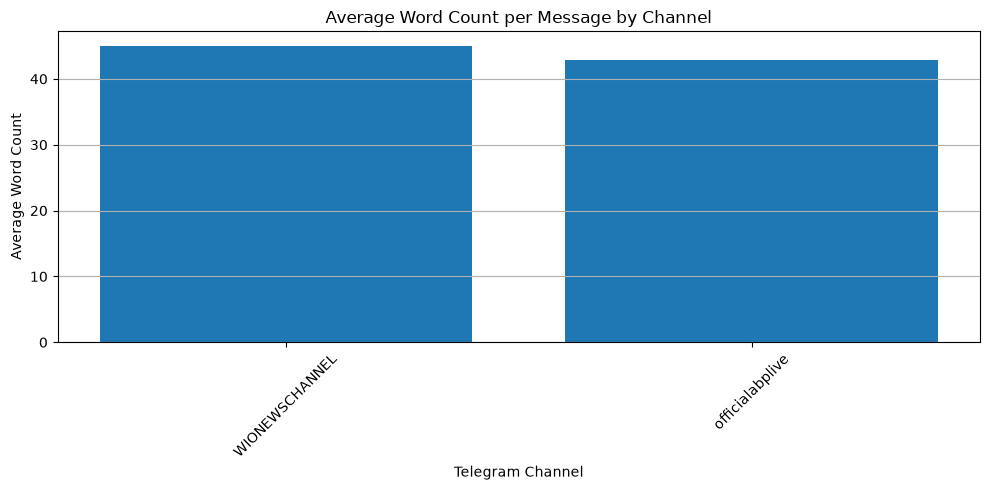

In [32]:
# ============================================================
# SERIAL 3D — AVERAGE WORD COUNT BY CHANNEL
# ============================================================

import matplotlib.pyplot as plt

word_df = channel_profiles.sort_values(
    "avg_word_count",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    word_df["channel"],
    word_df["avg_word_count"]
)

plt.title("Average Word Count per Message by Channel")
plt.xlabel("Telegram Channel")
plt.ylabel("Average Word Count")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

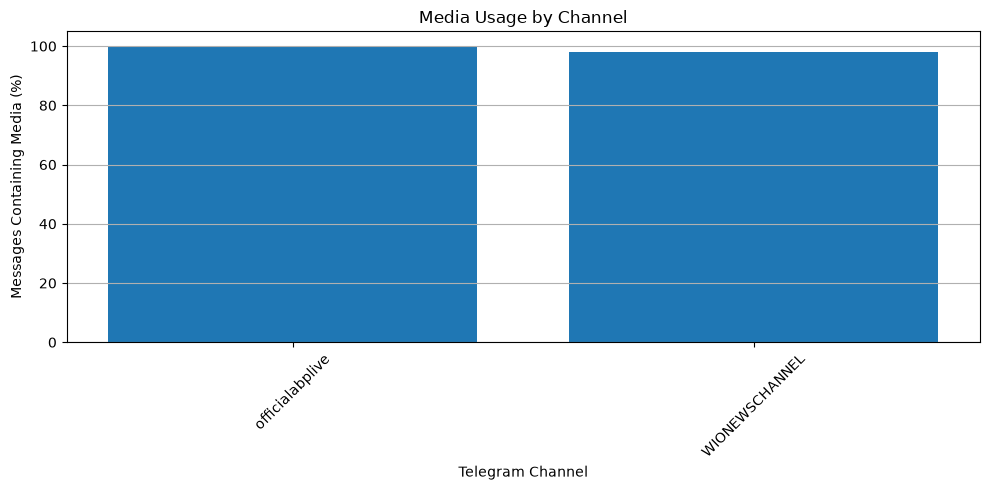

In [33]:
# ============================================================
# SERIAL 3D — MEDIA USAGE BY CHANNEL
# ============================================================

media_df = channel_profiles.sort_values(
    "media_percent",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    media_df["channel"],
    media_df["media_percent"]
)

plt.title("Media Usage by Channel")
plt.xlabel("Telegram Channel")
plt.ylabel("Messages Containing Media (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [34]:
# ============================================================
# SERIAL 3D — LANGUAGE DISTRIBUTION
# ============================================================

language_distribution = (
    all_messages
    .groupby(["channel", "language"])
    .size()
    .reset_index(name="message_count")
    .sort_values(["channel", "message_count"], ascending=[True, False])
)

display(language_distribution)

,channel,language,message_count
3,WIONEWSCHANNEL,en,2476
7,WIONEWSCHANNEL,unknown,273
2,WIONEWSCHANNEL,de,8
0,WIONEWSCHANNEL,af,1
1,WIONEWSCHANNEL,ca,1
4,WIONEWSCHANNEL,et,1
5,WIONEWSCHANNEL,id,1
6,WIONEWSCHANNEL,no,1
8,officialabplive,en,3000


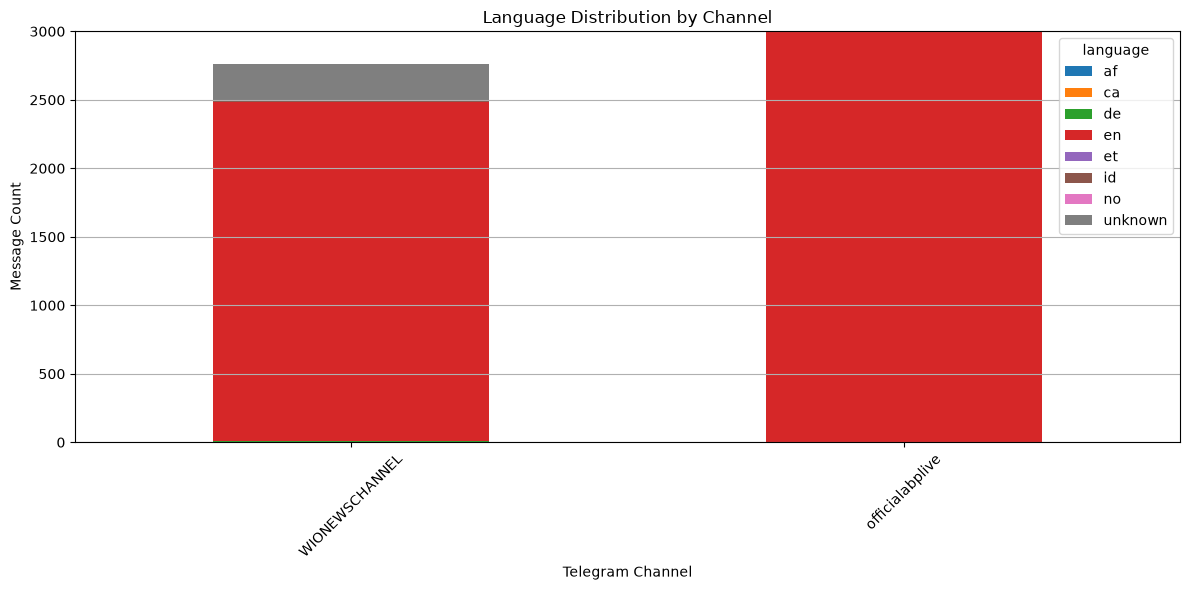

In [35]:
# ============================================================
# SERIAL 3D — LANGUAGE DISTRIBUTION CHART
# ============================================================

language_pivot = language_distribution.pivot_table(
    index="channel",
    columns="language",
    values="message_count",
    fill_value=0
)

language_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Language Distribution by Channel")
plt.xlabel("Telegram Channel")
plt.ylabel("Message Count")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [36]:
# ============================================================
# SERIAL 3D — HASHTAG USAGE SUMMARY
# ============================================================

# Build hashtag dataframe from all_messages

hashtag_rows = []

for _, row in all_messages.iterrows():

    for hashtag in row["hashtags"]:

        hashtag_rows.append({
            "channel": row["channel"],
            "hashtag": hashtag.lower(),
            "message_id": row["message_id"]
        })

hashtags_df = pd.DataFrame(hashtag_rows)

if hashtags_df.empty:

    print("No hashtags were found in the collected messages.")

else:

    hashtag_summary = (
        hashtags_df
        .groupby("channel")
        .agg(
            total_hashtag_uses=("hashtag", "count"),
            unique_hashtags=("hashtag", "nunique")
        )
        .reset_index()
    )

    display(hashtag_summary)

,channel,total_hashtag_uses,unique_hashtags
0,WIONEWSCHANNEL,1819,362
1,officialabplive,116,115


In [37]:
# ============================================================
# SERIAL 3D — TOP HASHTAGS BY CHANNEL
# ============================================================

if len(hashtags_df) > 0:
    top_hashtags_per_channel = (
        hashtags_df
        .groupby(["channel", "hashtag"])
        .size()
        .reset_index(name="count")
        .sort_values(["channel", "count"], ascending=[True, False])
    )

    display(
        top_hashtags_per_channel
        .groupby("channel")
        .head(10)
    )

else:
    top_hashtags_per_channel = pd.DataFrame()
    print("No hashtags found.")

,channel,hashtag,count
123,WIONEWSCHANNEL,gravitas,923
125,WIONEWSCHANNEL,gravitasplus,99
52,WIONEWSCHANNEL,china,49
268,WIONEWSCHANNEL,southasiadiary,41
286,WIONEWSCHANNEL,taliban,35
1,WIONEWSCHANNEL,afghanistan,26
257,WIONEWSCHANNEL,saveafghanwomen,22
294,WIONEWSCHANNEL,thewestasiapost,22
218,WIONEWSCHANNEL,pakistan,20
68,WIONEWSCHANNEL,covid19,18


In [38]:
# ============================================================
# SERIAL 3D — CONTENT ANALYST INTERPRETATION
# ============================================================

print("=" * 80)
print("ANALYST INTERPRETATION")
print("=" * 80)

longest = content_summary.iloc[0]
shortest = content_summary.iloc[-1]

print(f"\nLongest average messages:")
print(f"• {longest['channel']}")
print(f"• {longest['avg_word_count']:.2f} words per message")

print(f"\nShortest average messages:")
print(f"• {shortest['channel']}")
print(f"• {shortest['avg_word_count']:.2f} words per message")

highest_media = channel_profiles.sort_values(
    "media_percent",
    ascending=False
).iloc[0]

print(f"\nHighest media usage:")
print(f"• {highest_media['channel']}")
print(f"• {highest_media['media_percent']:.2f}% of messages contain media")

print("\nAnalyst notes:")
print("- Short messages may indicate breaking-news style posting.")
print("- Long messages may indicate commentary, analysis, or editorial framing.")
print("- High media usage may indicate visual amplification strategy.")
print("- Language distribution is important for cross-language narrative analysis.")
print("- Hashtag usage can reveal campaign-style framing or editorial categorisation.")

ANALYST INTERPRETATION

Longest average messages:
• WIONEWSCHANNEL
• 44.97 words per message

Shortest average messages:
• officialabplive
• 42.84 words per message

Highest media usage:
• officialabplive
• 100.00% of messages contain media

Analyst notes:
- Short messages may indicate breaking-news style posting.
- Long messages may indicate commentary, analysis, or editorial framing.
- High media usage may indicate visual amplification strategy.
- Language distribution is important for cross-language narrative analysis.
- Hashtag usage can reveal campaign-style framing or editorial categorisation.


# Sources Dashboard

## Objective

This section analyses the sources referenced by each Telegram channel.

The analysis focuses on:

- External domains
- Exact URLs
- Telegram links
- Source diversity
- Shared sources across channels

This is important because channels that repeatedly share the same sources may belong to the same information ecosystem or rely on similar upstream material.

Source overlap is one of the strongest non-AI signals for later channel correlation.

In [39]:
# ============================================================
# SERIAL 3E — CELL 1
# Build source DataFrames
# ============================================================

source_rows = []

for _, row in all_messages.iterrows():

    urls = row.get("urls", [])

    if not isinstance(urls, list):
        continue

    for url in urls:

        domain = None
        is_telegram_link = False

        try:
            if url.startswith("t.me/"):
                domain = "t.me"
                is_telegram_link = True
                normalized_url = "https://" + url

            else:
                parsed = urlparse(url)
                domain = parsed.netloc.replace("www.", "").lower()
                normalized_url = url
                is_telegram_link = "t.me" in domain

        except:
            domain = None
            normalized_url = url

        source_rows.append({
            "channel": row["channel"],
            "message_id": row["message_id"],
            "date": row["date"],
            "url": normalized_url,
            "domain": domain,
            "is_telegram_link": is_telegram_link,
            "message_link": row["message_link"],
            "clean_text": row["clean_text"]
        })

urls_df = pd.DataFrame(source_rows)

if len(urls_df) > 0:
    domains_df = urls_df.dropna(subset=["domain"]).copy()
    telegram_links_df = urls_df[urls_df["is_telegram_link"] == True].copy()
else:
    domains_df = pd.DataFrame()
    telegram_links_df = pd.DataFrame()

print("URLs extracted:", len(urls_df))
print("Domains extracted:", domains_df["domain"].nunique() if len(domains_df) else 0)
print("Telegram links extracted:", len(telegram_links_df))

URLs extracted: 7377
Domains extracted: 11
Telegram links extracted: 0


In [40]:
# ============================================================
# SERIAL 3E — CELL 2
# Source KPI Panel
# ============================================================

print("=" * 80)
print("SOURCES DASHBOARD")
print("=" * 80)

print(f"\nChannels analysed : {all_messages['channel'].nunique()}")
print(f"Total messages    : {len(all_messages):,}")
print(f"Messages with URLs: {all_messages['urls'].apply(lambda x: len(x) if isinstance(x, list) else 0).gt(0).sum():,}")
print(f"Total URLs        : {len(urls_df):,}")
print(f"Unique URLs       : {urls_df['url'].nunique() if len(urls_df) else 0:,}")
print(f"Unique domains    : {domains_df['domain'].nunique() if len(domains_df) else 0:,}")
print(f"Telegram links    : {len(telegram_links_df):,}")

SOURCES DASHBOARD

Channels analysed : 2
Total messages    : 5,762
Messages with URLs: 3,436
Total URLs        : 7,377
Unique URLs       : 4,308
Unique domains    : 11
Telegram links    : 0


In [41]:
# ============================================================
# SERIAL 3E — CELL 3
# Top domains by channel
# ============================================================

if len(domains_df) > 0:

    top_domains_by_channel = (
        domains_df
        .groupby(["channel", "domain"])
        .size()
        .reset_index(name="count")
        .sort_values(["channel", "count"], ascending=[True, False])
    )

    display(
        top_domains_by_channel
        .groupby("channel")
        .head(10)
    )

else:
    top_domains_by_channel = pd.DataFrame()
    print("No domains found.")

,channel,domain,count
8,WIONEWSCHANNEL,youtu.be,619
9,WIONEWSCHANNEL,youtube.com,529
7,WIONEWSCHANNEL,wionews.com,174
6,WIONEWSCHANNEL,twitter.com,19
0,WIONEWSCHANNEL,bit.ly,16
5,WIONEWSCHANNEL,t.co,15
1,WIONEWSCHANNEL,facebook.com,2
2,WIONEWSCHANNEL,glewed.tv,1
3,WIONEWSCHANNEL,open.spotify.com,1
4,WIONEWSCHANNEL,podcasts.google.com,1


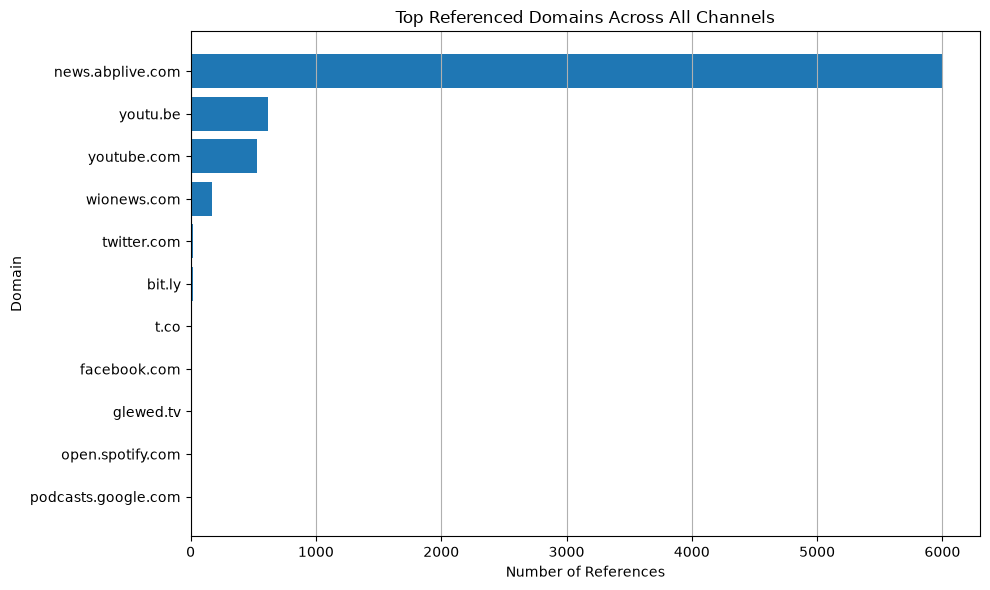

In [42]:
# ============================================================
# SERIAL 3E — CELL 4
# Domain usage chart
# ============================================================

if len(domains_df) > 0:

    top_domains_global = (
        domains_df
        .groupby("domain")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10,6))

    plt.barh(
        top_domains_global["domain"],
        top_domains_global["count"]
    )

    plt.title("Top Referenced Domains Across All Channels")
    plt.xlabel("Number of References")
    plt.ylabel("Domain")
    plt.gca().invert_yaxis()
    plt.grid(axis="x")
    plt.tight_layout()

    plt.show()

else:
    print("No domains available for chart.")

In [43]:
# ============================================================
# SERIAL 3E — CELL 5
# Top exact URLs
# ============================================================

if len(urls_df) > 0:

    top_urls = (
        urls_df
        .groupby("url")
        .agg(
            count=("url", "count"),
            channels=("channel", lambda x: sorted(set(x))),
            first_seen=("date", "min"),
            last_seen=("date", "max")
        )
        .reset_index()
        .sort_values("count", ascending=False)
    )

    display(top_urls.head(20))

else:
    top_urls = pd.DataFrame()
    print("No URLs found.")

,url,count,channels,first_seen,last_seen
3088,https://www.wionews.com/live-tv,44,[WIONEWSCHANNEL],2020-01-30 15:10:31+00:00,2022-07-29 14:19:56+00:00
3033,https://twitter.com/WIONews,12,[WIONEWSCHANNEL],2020-01-30 15:10:31+00:00,2020-02-21 15:14:01+00:00
3340,https://www.youtube.com/watch?v=KyUT37gNm5w,5,[WIONEWSCHANNEL],2022-06-16 15:33:31+00:00,2022-06-23 15:32:20+00:00
3089,https://www.wionews.com/live-tv*,4,[WIONEWSCHANNEL],2020-07-15 15:03:56+00:00,2020-09-03 14:23:53+00:00
3041,https://wionews.com/live-tv,4,[WIONEWSCHANNEL],2020-05-14 15:00:03+00:00,2021-09-15 11:32:21+00:00
2154,https://news.abplive.com/sports/cricket/highes...,2,[officialabplive],2026-03-08 14:16:04+00:00,2026-03-08 14:16:04+00:00
2020,https://news.abplive.com/news/world/trump-chin...,2,[officialabplive],2026-05-15 02:40:05+00:00,2026-05-15 02:40:05+00:00
2011,https://news.abplive.com/news/world/several-ki...,2,[officialabplive],2026-01-26 17:26:04+00:00,2026-01-26 17:26:04+00:00
2012,https://news.abplive.com/news/world/shehbaz-sh...,2,[officialabplive],2026-01-31 10:06:04+00:00,2026-01-31 10:06:04+00:00
2013,https://news.abplive.com/news/world/strait-of-...,2,[officialabplive],2026-05-06 01:26:03+00:00,2026-05-06 01:26:03+00:00


In [44]:
# ============================================================
# SERIAL 3E — CELL 6
# Telegram links referenced
# ============================================================

if len(telegram_links_df) > 0:

    top_telegram_links = (
        telegram_links_df
        .groupby("url")
        .agg(
            count=("url", "count"),
            channels=("channel", lambda x: sorted(set(x))),
            first_seen=("date", "min"),
            last_seen=("date", "max")
        )
        .reset_index()
        .sort_values("count", ascending=False)
    )

    display(top_telegram_links.head(20))

else:
    top_telegram_links = pd.DataFrame()
    print("No Telegram links found.")

No Telegram links found.


In [45]:
# ============================================================
# SERIAL 3E — CELL 7
# Source diversity by channel
# ============================================================

if len(domains_df) > 0:

    source_diversity = (
        domains_df
        .groupby("channel")
        .agg(
            total_domain_references=("domain", "count"),
            unique_domains=("domain", "nunique")
        )
        .reset_index()
    )

    source_diversity["domain_diversity_ratio"] = (
        source_diversity["unique_domains"] /
        source_diversity["total_domain_references"]
    ).round(3)

    display(
        source_diversity.sort_values(
            "domain_diversity_ratio",
            ascending=False
        )
    )

else:
    source_diversity = pd.DataFrame()
    print("No domain data available.")

,channel,total_domain_references,unique_domains,domain_diversity_ratio
0,WIONEWSCHANNEL,1377,10,0.007
1,officialabplive,6000,1,0.000


In [46]:
# ============================================================
# SERIAL 3E — CELL 8
# Shared domains across channels
# ============================================================

if len(domains_df) > 0:

    domain_channel_counts = (
        domains_df
        .groupby("domain")
        .agg(
            channels=("channel", lambda x: sorted(set(x))),
            channel_count=("channel", "nunique"),
            total_mentions=("domain", "count")
        )
        .reset_index()
        .sort_values(["channel_count", "total_mentions"], ascending=False)
    )

    shared_domains = domain_channel_counts[
        domain_channel_counts["channel_count"] > 1
    ]

    display(shared_domains.head(30))

else:
    shared_domains = pd.DataFrame()
    print("No shared domains found.")

,domain,channels,channel_count,total_mentions


In [47]:
# ============================================================
# SERIAL 3E — CELL 9
# Shared exact URLs across channels
# ============================================================

if len(urls_df) > 0:

    url_channel_counts = (
        urls_df
        .groupby("url")
        .agg(
            channels=("channel", lambda x: sorted(set(x))),
            channel_count=("channel", "nunique"),
            total_mentions=("url", "count"),
            first_seen=("date", "min"),
            last_seen=("date", "max")
        )
        .reset_index()
        .sort_values(["channel_count", "total_mentions"], ascending=False)
    )

    shared_urls = url_channel_counts[
        url_channel_counts["channel_count"] > 1
    ]

    display(shared_urls.head(30))

else:
    shared_urls = pd.DataFrame()
    print("No shared URLs found.")

,url,channels,channel_count,total_mentions,first_seen,last_seen


In [48]:
# ============================================================
# SERIAL 3E — CELL 10
# Source analyst interpretation
# ============================================================

print("=" * 80)
print("ANALYST INTERPRETATION")
print("=" * 80)

if len(domains_df) == 0:

    print("No source links were detected in the collected messages.")

else:

    most_used_domain = (
        domains_df
        .groupby("domain")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .iloc[0]
    )

    print(f"\nMost referenced domain:")
    print(f"• {most_used_domain['domain']}")
    print(f"• {most_used_domain['count']} references")

    if len(source_diversity) > 0:
        most_diverse = source_diversity.sort_values(
            "domain_diversity_ratio",
            ascending=False
        ).iloc[0]

        least_diverse = source_diversity.sort_values(
            "domain_diversity_ratio",
            ascending=True
        ).iloc[0]

        print(f"\nMost source-diverse channel:")
        print(f"• {most_diverse['channel']}")
        print(f"• Diversity ratio: {most_diverse['domain_diversity_ratio']}")

        print(f"\nLeast source-diverse channel:")
        print(f"• {least_diverse['channel']}")
        print(f"• Diversity ratio: {least_diverse['domain_diversity_ratio']}")

    print("\nShared source findings:")

    if len(shared_domains) > 0:
        print(f"• Shared domains found: {len(shared_domains)}")
    else:
        print("• No shared domains found across channels.")

    if len(shared_urls) > 0:
        print(f"• Shared exact URLs found: {len(shared_urls)}")
    else:
        print("• No shared exact URLs found across channels.")

    print("\nAnalyst notes:")
    print("- Shared domains indicate similar source ecosystems.")
    print("- Shared exact URLs are stronger evidence of content overlap.")
    print("- Telegram links may reveal references to other Telegram channels.")
    print("- Source overlap alone does not prove coordination.")
    print("- Source overlap should later be combined with timing, narratives, and message similarity.")

ANALYST INTERPRETATION

Most referenced domain:
• news.abplive.com
• 6000 references

Most source-diverse channel:
• WIONEWSCHANNEL
• Diversity ratio: 0.007

Least source-diverse channel:
• officialabplive
• Diversity ratio: 0.0

Shared source findings:
• No shared domains found across channels.
• No shared exact URLs found across channels.

Analyst notes:
- Shared domains indicate similar source ecosystems.
- Shared exact URLs are stronger evidence of content overlap.
- Telegram links may reveal references to other Telegram channels.
- Source overlap alone does not prove coordination.
- Source overlap should later be combined with timing, narratives, and message similarity.


# Telegram Reference Intelligence

## Objective

This section identifies how Telegram channels reference other Telegram entities.

The analysis focuses on:

- Telegram usernames mentioned in messages
- Telegram channel links
- Mention frequency
- Outgoing references
- Cross-channel references

These references provide valuable evidence for understanding communication patterns and later constructing network graphs.

A mention alone does not imply coordination. It simply represents an observable relationship.

In [49]:
# ============================================================
# SERIAL 3F — CELL 1
# Build Mention DataFrame
# ============================================================

mention_rows = []

for _, row in all_messages.iterrows():

    mentions = row.get("mentions", [])

    if not isinstance(mentions, list):
        continue

    for mention in mentions:

        mention_rows.append({

            "source_channel": row["channel"],

            "mentioned_username": mention.lower(),

            "message_id": row["message_id"],

            "date": row["date"],

            "message_link": row["message_link"],

            "text": row["clean_text"]

        })

mentions_df = pd.DataFrame(mention_rows)

print("Mentions extracted:", len(mentions_df))

display(mentions_df.head())

Mentions extracted: 59


,source_channel,mentioned_username,message_id,date,message_link,text
0,officialabplive,cockroachjantaparty,42515,2026-05-21 02:42:05+00:00,https://t.me/officialabplive/42515,[**Cockroach Janta Party Surpasses BJP On Inst...
1,WIONEWSCHANNEL,marowardak,2697,2022-09-26 13:48:56+00:00,https://t.me/WIONEWSCHANNEL/2697,*On South Asia Diary with @MaroWardak* + Flood...
2,WIONEWSCHANNEL,palkisu,2643,2022-09-06 10:23:21+00:00,https://t.me/WIONEWSCHANNEL/2643,"#Gravitas | As India celebrates Teachers' Day,..."
3,WIONEWSCHANNEL,palkisu,2642,2022-09-06 10:22:42+00:00,https://t.me/WIONEWSCHANNEL/2642,#Gravitas | @NASA had to postpone the launch o...
4,WIONEWSCHANNEL,palkisu,2637,2022-09-05 11:36:38+00:00,https://t.me/WIONEWSCHANNEL/2637,Gravitas Plus: Why children need to be taught ...


In [50]:
# ============================================================
# SERIAL 3F — CELL 2
# Mention KPI Panel
# ============================================================

print("=" * 80)
print("TELEGRAM REFERENCE / MENTION DASHBOARD")
print("=" * 80)

total_messages = len(all_messages)
total_mentions = len(mentions_df)
unique_mentions = mentions_df["mentioned_username"].nunique() if len(mentions_df) else 0

messages_with_mentions = (
    all_messages["mentions"]
    .apply(lambda x: len(x) if isinstance(x, list) else 0)
    .gt(0)
    .sum()
)

avg_mentions_per_message = (
    total_mentions / total_messages
    if total_messages > 0 else 0
)

print(f"\nChannels analysed        : {all_messages['channel'].nunique()}")
print(f"Total messages           : {total_messages:,}")
print(f"Messages with mentions   : {messages_with_mentions:,}")
print(f"Total mentions extracted : {total_mentions:,}")
print(f"Unique mentioned accounts: {unique_mentions:,}")
print(f"Avg mentions per message : {avg_mentions_per_message:.3f}")

TELEGRAM REFERENCE / MENTION DASHBOARD

Channels analysed        : 2
Total messages           : 5,762
Messages with mentions   : 45
Total mentions extracted : 59
Unique mentioned accounts: 27
Avg mentions per message : 0.010


In [51]:
# ============================================================
# SERIAL 3F — CELL 3
# Top Mentioned Telegram Accounts
# ============================================================

if len(mentions_df) > 0:

    top_mentions_global = (
        mentions_df
        .groupby("mentioned_username")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(20)
    )

    display(top_mentions_global)

else:
    top_mentions_global = pd.DataFrame()
    print("No Telegram mentions found.")

,mentioned_username,count
19,palkisu,24
15,marowardak,4
6,ghadifrancis,4
10,joinsumit,3
9,joebiden,2
0,airindiain,1
25,whatsapp,1
24,walidr_nassar,1
23,vjosaosmaniprks,1
22,tutejankit,1


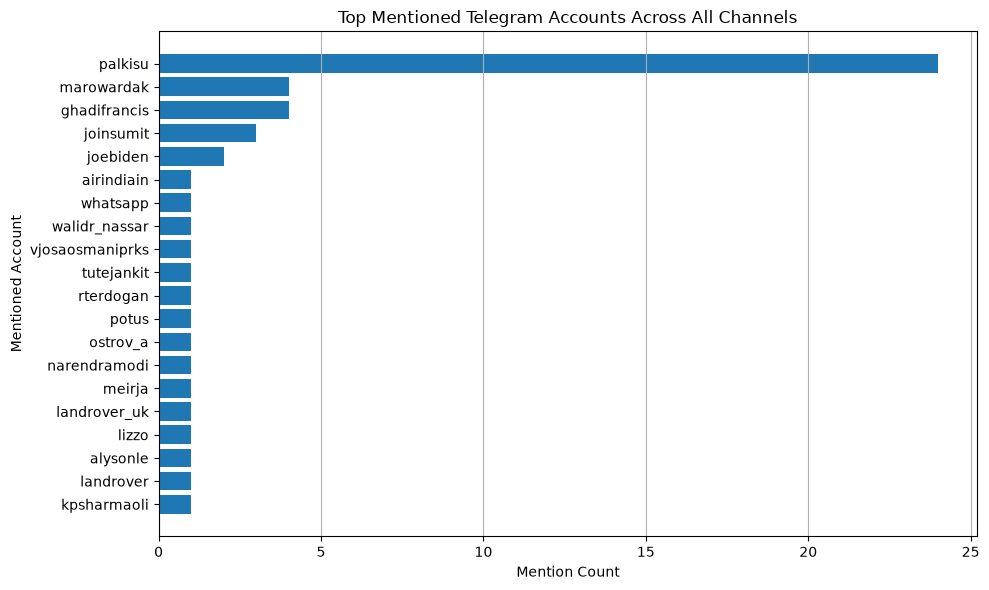

In [52]:
# ============================================================
# SERIAL 3F — CELL 4
# Top Mentioned Accounts Chart
# ============================================================

if len(top_mentions_global) > 0:

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_mentions_global["mentioned_username"],
        top_mentions_global["count"]
    )

    plt.title("Top Mentioned Telegram Accounts Across All Channels")
    plt.xlabel("Mention Count")
    plt.ylabel("Mentioned Account")
    plt.gca().invert_yaxis()
    plt.grid(axis="x")
    plt.tight_layout()

    plt.show()

else:
    print("No mention data available for chart.")

In [53]:
# ============================================================
# SERIAL 3F — CELL 5
# Which Channel Mentions Whom
# ============================================================

if len(mentions_df) > 0:

    mentions_by_channel = (
        mentions_df
        .groupby(["source_channel", "mentioned_username"])
        .size()
        .reset_index(name="mention_count")
        .sort_values(["source_channel", "mention_count"], ascending=[True, False])
    )

    display(
        mentions_by_channel
        .groupby("source_channel")
        .head(15)
    )

else:
    mentions_by_channel = pd.DataFrame()
    print("No mentions found.")

,source_channel,mentioned_username,mention_count
18,WIONEWSCHANNEL,palkisu,24
5,WIONEWSCHANNEL,ghadifrancis,4
14,WIONEWSCHANNEL,marowardak,4
9,WIONEWSCHANNEL,joinsumit,3
8,WIONEWSCHANNEL,joebiden,2
0,WIONEWSCHANNEL,airindiain,1
1,WIONEWSCHANNEL,alysonle,1
2,WIONEWSCHANNEL,cop26,1
3,WIONEWSCHANNEL,databeings,1
4,WIONEWSCHANNEL,fatfnews,1


In [54]:
# ============================================================
# SERIAL 3F — CELL 6
# Mention Diversity by Channel
# ============================================================

if len(mentions_df) > 0:

    mention_diversity = (
        mentions_df
        .groupby("source_channel")
        .agg(
            total_mentions=("mentioned_username", "count"),
            unique_mentions=("mentioned_username", "nunique")
        )
        .reset_index()
    )

    mention_diversity["mention_diversity_ratio"] = (
        mention_diversity["unique_mentions"] /
        mention_diversity["total_mentions"]
    ).round(3)

    mention_diversity = mention_diversity.sort_values(
        "mention_diversity_ratio",
        ascending=False
    )

    display(mention_diversity)

else:
    mention_diversity = pd.DataFrame()
    print("No mention diversity can be calculated.")

,source_channel,total_mentions,unique_mentions,mention_diversity_ratio
1,officialabplive,1,1,1.000
0,WIONEWSCHANNEL,58,26,0.448


In [55]:
# ============================================================
# SERIAL 3F — CELL 7
# Shared Mentioned Accounts Across Channels
# ============================================================

if len(mentions_df) > 0:

    mention_channel_counts = (
        mentions_df
        .groupby("mentioned_username")
        .agg(
            channels=("source_channel", lambda x: sorted(set(x))),
            channel_count=("source_channel", "nunique"),
            total_mentions=("mentioned_username", "count"),
            first_seen=("date", "min"),
            last_seen=("date", "max")
        )
        .reset_index()
        .sort_values(["channel_count", "total_mentions"], ascending=False)
    )

    shared_mentions = mention_channel_counts[
        mention_channel_counts["channel_count"] > 1
    ]

    display(shared_mentions.head(30))

else:
    shared_mentions = pd.DataFrame()
    print("No shared mentions found.")

,mentioned_username,channels,channel_count,total_mentions,first_seen,last_seen


In [56]:
# ============================================================
# SERIAL 3F — CELL 8
# Outgoing Mention Edges
# ============================================================

if len(mentions_df) > 0:

    mention_edges = (
        mentions_df
        .groupby(["source_channel", "mentioned_username"])
        .agg(
            weight=("mentioned_username", "count"),
            first_seen=("date", "min"),
            last_seen=("date", "max")
        )
        .reset_index()
        .rename(columns={
            "source_channel": "source",
            "mentioned_username": "target"
        })
    )

    mention_edges["edge_type"] = "mention"

    mention_edges = mention_edges.sort_values(
        "weight",
        ascending=False
    )

    display(mention_edges.head(30))

else:
    mention_edges = pd.DataFrame(
        columns=["source", "target", "weight", "first_seen", "last_seen", "edge_type"]
    )
    print("No mention edges created.")

,source,target,weight,first_seen,last_seen,edge_type
18,WIONEWSCHANNEL,palkisu,24,2020-04-30 07:58:13+00:00,2022-09-06 10:23:21+00:00,mention
5,WIONEWSCHANNEL,ghadifrancis,4,2021-07-02 14:22:27+00:00,2022-06-24 14:16:32+00:00,mention
14,WIONEWSCHANNEL,marowardak,4,2020-02-22 07:55:41+00:00,2022-09-26 13:48:56+00:00,mention
9,WIONEWSCHANNEL,joinsumit,3,2020-02-08 08:40:12+00:00,2020-02-22 12:48:16+00:00,mention
8,WIONEWSCHANNEL,joebiden,2,2021-09-01 11:48:38+00:00,2022-06-02 13:39:24+00:00,mention
0,WIONEWSCHANNEL,airindiain,1,2020-02-22 12:48:16+00:00,2020-02-22 12:48:16+00:00,mention
16,WIONEWSCHANNEL,narendramodi,1,2022-05-23 14:38:43+00:00,2022-05-23 14:38:43+00:00,mention
25,WIONEWSCHANNEL,zeemedia,1,2021-02-03 14:33:36+00:00,2021-02-03 14:33:36+00:00,mention
24,WIONEWSCHANNEL,whatsapp,1,2021-01-17 07:36:21+00:00,2021-01-17 07:36:21+00:00,mention
23,WIONEWSCHANNEL,walidr_nassar,1,2022-06-24 14:16:32+00:00,2022-06-24 14:16:32+00:00,mention


In [57]:
# ============================================================
# SERIAL 3F — CELL 9
# Mention Network Preview using NetworkX
# ============================================================

if len(mention_edges) > 0:

    G_mentions = nx.DiGraph()

    for _, row in mention_edges.iterrows():

        G_mentions.add_node(
            row["source"],
            node_type="source_channel"
        )

        G_mentions.add_node(
            row["target"],
            node_type="mentioned_account"
        )

        G_mentions.add_edge(
            row["source"],
            row["target"],
            weight=row["weight"],
            edge_type=row["edge_type"]
        )

    print("Mention network created.")
    print("Nodes:", G_mentions.number_of_nodes())
    print("Edges:", G_mentions.number_of_edges())

    mention_degree = sorted(
        G_mentions.degree(),
        key=lambda x: x[1],
        reverse=True
    )[:20]

    print("\nTop nodes by degree:")
    for node, degree in mention_degree:
        print(f"{node:<30} {degree}")

else:
    G_mentions = nx.DiGraph()
    print("No mention network created.")

Mention network created.
Nodes: 29
Edges: 27

Top nodes by degree:
WIONEWSCHANNEL                 26
palkisu                        1
ghadifrancis                   1
marowardak                     1
joinsumit                      1
joebiden                       1
airindiain                     1
narendramodi                   1
zeemedia                       1
whatsapp                       1
walidr_nassar                  1
vjosaosmaniprks                1
tutejankit                     1
rterdogan                      1
potus                          1
ostrov_a                       1
lizzo                          1
meirja                         1
alysonle                       1
landrover_uk                   1


In [58]:
# ============================================================
# SERIAL 3F — CELL 10
# Mention Analyst Interpretation
# ============================================================

print("=" * 80)
print("ANALYST INTERPRETATION")
print("=" * 80)

if len(mentions_df) == 0:

    print("No Telegram mentions were detected in the collected messages.")

else:

    most_mentioned = top_mentions_global.iloc[0]

    print(f"\nMost mentioned Telegram account:")
    print(f"• @{most_mentioned['mentioned_username']}")
    print(f"• {most_mentioned['count']} mentions")

    if len(mention_diversity) > 0:

        most_diverse = mention_diversity.iloc[0]
        least_diverse = mention_diversity.iloc[-1]

        print(f"\nMost mention-diverse channel:")
        print(f"• {most_diverse['source_channel']}")
        print(f"• Diversity ratio: {most_diverse['mention_diversity_ratio']}")

        print(f"\nLeast mention-diverse channel:")
        print(f"• {least_diverse['source_channel']}")
        print(f"• Diversity ratio: {least_diverse['mention_diversity_ratio']}")

    print("\nShared mention findings:")

    if len(shared_mentions) > 0:
        print(f"• Shared mentioned accounts found: {len(shared_mentions)}")
    else:
        print("• No shared mentioned accounts found across channels.")

    print("\nNetwork findings:")
    print(f"• Mention network nodes: {G_mentions.number_of_nodes()}")
    print(f"• Mention network edges: {G_mentions.number_of_edges()}")

    print("\nAnalyst notes:")
    print("- Mentions represent observable outgoing references.")
    print("- Repeated mentions may indicate source reliance, promotion, or editorial focus.")
    print("- Shared mentioned accounts are useful channel-correlation signals.")
    print("- Mention overlap alone does not prove coordination.")
    print("- These mention edges will later feed into the full network graph.")

ANALYST INTERPRETATION

Most mentioned Telegram account:
• @palkisu
• 24 mentions

Most mention-diverse channel:
• officialabplive
• Diversity ratio: 1.0

Least mention-diverse channel:
• WIONEWSCHANNEL
• Diversity ratio: 0.448

Shared mention findings:
• No shared mentioned accounts found across channels.

Network findings:
• Mention network nodes: 29
• Mention network edges: 27

Analyst notes:
- Mentions represent observable outgoing references.
- Repeated mentions may indicate source reliance, promotion, or editorial focus.
- Shared mentioned accounts are useful channel-correlation signals.
- Mention overlap alone does not prove coordination.
- These mention edges will later feed into the full network graph.


# Cross-Channel Overlap Dashboard

## Objective

This section compares Telegram channels against each other using observable overlap signals.

The analysis focuses on:

- Shared external domains
- Shared exact URLs
- Shared Telegram mentions
- Shared Telegram links
- Overall source/reference overlap

This is the first stage of channel correlation.

At this stage, we are not yet using AI, narratives, or semantic similarity. We are comparing channels based only on hard observable evidence.

Important: overlap does not prove coordination. It indicates that channels may share sources, references, or information ecosystems.

In [59]:
# ============================================================
# SERIAL 4 — CELL 1
# Rebuild overlap source tables safely
# ============================================================

# This cell is intentionally self-contained.
# It rebuilds URL, domain, Telegram-link, and mention tables from all_messages.

overlap_url_rows = []
overlap_domain_rows = []
overlap_telegram_link_rows = []
overlap_mention_rows = []

for _, row in all_messages.iterrows():

    channel = row["channel"]
    message_id = row["message_id"]
    date = row["date"]
    message_link = row["message_link"]
    text = row["clean_text"]

    # ----------------------------
    # URLs and domains
    # ----------------------------
    urls = row.get("urls", [])

    if isinstance(urls, list):
        for url in urls:

            normalized_url = url.strip()

            if normalized_url.startswith("t.me/"):
                normalized_url = "https://" + normalized_url

            try:
                parsed = urlparse(normalized_url)
                domain = parsed.netloc.replace("www.", "").lower()
            except:
                domain = None

            if normalized_url:
                overlap_url_rows.append({
                    "channel": channel,
                    "message_id": message_id,
                    "date": date,
                    "url": normalized_url,
                    "domain": domain,
                    "message_link": message_link,
                    "text": text
                })

            if domain:
                overlap_domain_rows.append({
                    "channel": channel,
                    "message_id": message_id,
                    "date": date,
                    "domain": domain,
                    "url": normalized_url,
                    "message_link": message_link
                })

            if domain == "t.me":
                overlap_telegram_link_rows.append({
                    "channel": channel,
                    "message_id": message_id,
                    "date": date,
                    "telegram_url": normalized_url,
                    "message_link": message_link,
                    "text": text
                })

    # ----------------------------
    # Mentions
    # ----------------------------
    mentions = row.get("mentions", [])

    if isinstance(mentions, list):
        for mention in mentions:
            overlap_mention_rows.append({
                "channel": channel,
                "message_id": message_id,
                "date": date,
                "mentioned_username": mention.lower(),
                "message_link": message_link,
                "text": text
            })


overlap_urls_df = pd.DataFrame(overlap_url_rows)
overlap_domains_df = pd.DataFrame(overlap_domain_rows)
overlap_telegram_links_df = pd.DataFrame(overlap_telegram_link_rows)
overlap_mentions_df = pd.DataFrame(overlap_mention_rows)

print("Overlap tables rebuilt.")
print("URLs:", len(overlap_urls_df))
print("Domains:", len(overlap_domains_df))
print("Telegram links:", len(overlap_telegram_links_df))
print("Mentions:", len(overlap_mentions_df))

Overlap tables rebuilt.
URLs: 7377
Domains: 7377
Telegram links: 0
Mentions: 59


In [60]:
# ============================================================
# SERIAL 4 — CELL 2
# Cross-channel overlap KPI panel
# ============================================================

print("=" * 80)
print("CROSS-CHANNEL OVERLAP DASHBOARD")
print("=" * 80)

print(f"\nChannels analysed       : {all_messages['channel'].nunique()}")
print(f"Total messages          : {len(all_messages):,}")
print(f"Total URLs              : {len(overlap_urls_df):,}")
print(f"Total domain references : {len(overlap_domains_df):,}")
print(f"Telegram links          : {len(overlap_telegram_links_df):,}")
print(f"Telegram mentions       : {len(overlap_mentions_df):,}")

CROSS-CHANNEL OVERLAP DASHBOARD

Channels analysed       : 2
Total messages          : 5,762
Total URLs              : 7,377
Total domain references : 7,377
Telegram links          : 0
Telegram mentions       : 59


In [61]:
# ============================================================
# SERIAL 4 — CELL 3
# Shared domains across channels
# ============================================================

if len(overlap_domains_df) > 0:

    shared_domains = (
        overlap_domains_df
        .groupby("domain")
        .agg(
            channels=("channel", lambda x: sorted(set(x))),
            channel_count=("channel", "nunique"),
            total_references=("domain", "count"),
            first_seen=("date", "min"),
            last_seen=("date", "max")
        )
        .reset_index()
    )

    shared_domains = shared_domains[
        shared_domains["channel_count"] > 1
    ].sort_values(
        ["channel_count", "total_references"],
        ascending=False
    )

    display(shared_domains.head(30))

else:
    shared_domains = pd.DataFrame()
    print("No domain references found.")

,domain,channels,channel_count,total_references,first_seen,last_seen


In [62]:
# ============================================================
# SERIAL 4 — CELL 4
# Shared exact URLs across channels
# ============================================================

if len(overlap_urls_df) > 0:

    shared_urls = (
        overlap_urls_df
        .groupby("url")
        .agg(
            channels=("channel", lambda x: sorted(set(x))),
            channel_count=("channel", "nunique"),
            total_references=("url", "count"),
            first_seen=("date", "min"),
            last_seen=("date", "max")
        )
        .reset_index()
    )

    shared_urls = shared_urls[
        shared_urls["channel_count"] > 1
    ].sort_values(
        ["channel_count", "total_references"],
        ascending=False
    )

    display(shared_urls.head(30))

else:
    shared_urls = pd.DataFrame()
    print("No URLs found.")

,url,channels,channel_count,total_references,first_seen,last_seen


In [63]:
# ============================================================
# SERIAL 4 — CELL 5
# Shared Telegram mentions across channels
# ============================================================

if len(overlap_mentions_df) > 0:

    shared_mentions = (
        overlap_mentions_df
        .groupby("mentioned_username")
        .agg(
            channels=("channel", lambda x: sorted(set(x))),
            channel_count=("channel", "nunique"),
            total_mentions=("mentioned_username", "count"),
            first_seen=("date", "min"),
            last_seen=("date", "max")
        )
        .reset_index()
    )

    shared_mentions = shared_mentions[
        shared_mentions["channel_count"] > 1
    ].sort_values(
        ["channel_count", "total_mentions"],
        ascending=False
    )

    display(shared_mentions.head(30))

else:
    shared_mentions = pd.DataFrame()
    print("No Telegram mentions found.")

,mentioned_username,channels,channel_count,total_mentions,first_seen,last_seen


In [64]:
# ============================================================
# SERIAL 4 — CELL 6
# Shared Telegram links across channels
# ============================================================

if len(overlap_telegram_links_df) > 0:

    shared_telegram_links = (
        overlap_telegram_links_df
        .groupby("telegram_url")
        .agg(
            channels=("channel", lambda x: sorted(set(x))),
            channel_count=("channel", "nunique"),
            total_references=("telegram_url", "count"),
            first_seen=("date", "min"),
            last_seen=("date", "max")
        )
        .reset_index()
    )

    shared_telegram_links = shared_telegram_links[
        shared_telegram_links["channel_count"] > 1
    ].sort_values(
        ["channel_count", "total_references"],
        ascending=False
    )

    display(shared_telegram_links.head(30))

else:
    shared_telegram_links = pd.DataFrame()
    print("No Telegram links found.")

No Telegram links found.


In [65]:
# ============================================================
# SERIAL 4 — CELL 7
# Build channel-pair overlap scores
# ============================================================

from itertools import combinations

channels = sorted(all_messages["channel"].unique())

pair_rows = []

for ch_a, ch_b in combinations(channels, 2):

    # Domains used by each channel
    domains_a = set(
        overlap_domains_df[overlap_domains_df["channel"] == ch_a]["domain"]
    ) if len(overlap_domains_df) else set()

    domains_b = set(
        overlap_domains_df[overlap_domains_df["channel"] == ch_b]["domain"]
    ) if len(overlap_domains_df) else set()

    # Exact URLs used by each channel
    urls_a = set(
        overlap_urls_df[overlap_urls_df["channel"] == ch_a]["url"]
    ) if len(overlap_urls_df) else set()

    urls_b = set(
        overlap_urls_df[overlap_urls_df["channel"] == ch_b]["url"]
    ) if len(overlap_urls_df) else set()

    # Telegram mentions used by each channel
    mentions_a = set(
        overlap_mentions_df[overlap_mentions_df["channel"] == ch_a]["mentioned_username"]
    ) if len(overlap_mentions_df) else set()

    mentions_b = set(
        overlap_mentions_df[overlap_mentions_df["channel"] == ch_b]["mentioned_username"]
    ) if len(overlap_mentions_df) else set()

    # Telegram links used by each channel
    tlinks_a = set(
        overlap_telegram_links_df[overlap_telegram_links_df["channel"] == ch_a]["telegram_url"]
    ) if len(overlap_telegram_links_df) else set()

    tlinks_b = set(
        overlap_telegram_links_df[overlap_telegram_links_df["channel"] == ch_b]["telegram_url"]
    ) if len(overlap_telegram_links_df) else set()


    def jaccard(set_a, set_b):
        """
        Jaccard similarity = shared items / total unique items.
        Returns 0 if both sets are empty.
        """
        union = set_a | set_b
        if len(union) == 0:
            return 0
        return len(set_a & set_b) / len(union)


    domain_overlap = jaccard(domains_a, domains_b)
    url_overlap = jaccard(urls_a, urls_b)
    mention_overlap = jaccard(mentions_a, mentions_b)
    telegram_link_overlap = jaccard(tlinks_a, tlinks_b)

    # Weighted overlap score.
    # Exact URL overlap is stronger than domain overlap.
    source_reference_overlap_score = (
        domain_overlap * 0.25 +
        url_overlap * 0.35 +
        mention_overlap * 0.25 +
        telegram_link_overlap * 0.15
    )

    pair_rows.append({
        "channel_a": ch_a,
        "channel_b": ch_b,
        "domain_overlap": round(domain_overlap, 3),
        "url_overlap": round(url_overlap, 3),
        "mention_overlap": round(mention_overlap, 3),
        "telegram_link_overlap": round(telegram_link_overlap, 3),
        "source_reference_overlap_score": round(source_reference_overlap_score, 3),

        "shared_domains_count": len(domains_a & domains_b),
        "shared_urls_count": len(urls_a & urls_b),
        "shared_mentions_count": len(mentions_a & mentions_b),
        "shared_telegram_links_count": len(tlinks_a & tlinks_b)
    })

channel_overlap_scores = pd.DataFrame(pair_rows).sort_values(
    "source_reference_overlap_score",
    ascending=False
)

display(channel_overlap_scores)

,channel_a,channel_b,domain_overlap,url_overlap,mention_overlap,telegram_link_overlap,source_reference_overlap_score,shared_domains_count,shared_urls_count,shared_mentions_count,shared_telegram_links_count
0,WIONEWSCHANNEL,officialabplive,0.0,0.0,0.0,0,0.0,0,0,0,0


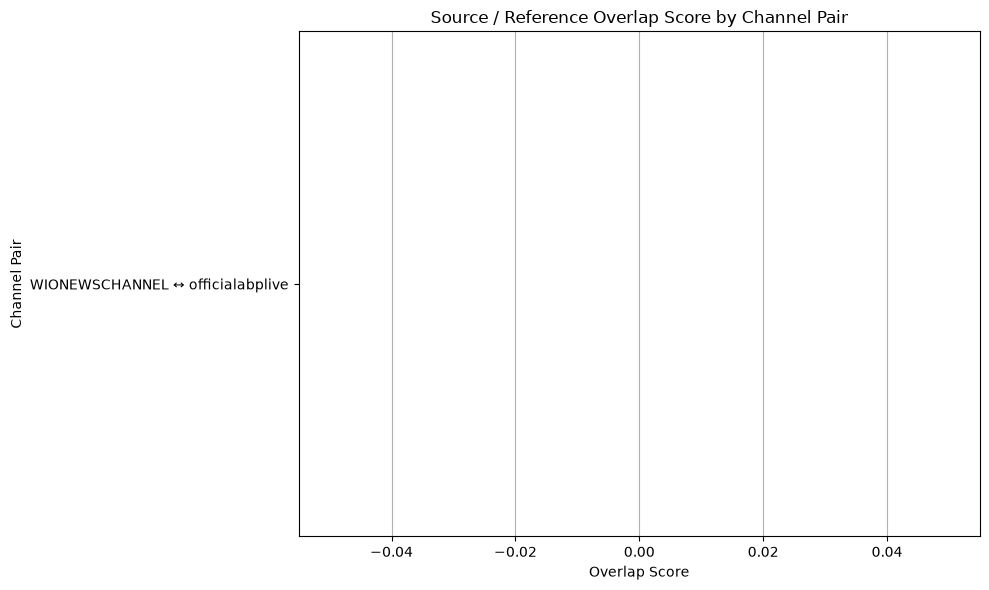

In [66]:
# ============================================================
# SERIAL 4 — CELL 8
# Channel-pair overlap score chart
# ============================================================

if len(channel_overlap_scores) > 0:

    plot_df = channel_overlap_scores.copy()

    plot_df["pair"] = (
        plot_df["channel_a"] + " ↔ " + plot_df["channel_b"]
    )

    plot_df = plot_df.sort_values(
        "source_reference_overlap_score",
        ascending=True
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_df["pair"],
        plot_df["source_reference_overlap_score"]
    )

    plt.title("Source / Reference Overlap Score by Channel Pair")
    plt.xlabel("Overlap Score")
    plt.ylabel("Channel Pair")
    plt.grid(axis="x")
    plt.tight_layout()

    plt.show()

else:
    print("No channel pairs available for overlap chart.")

In [67]:
# ============================================================
# SERIAL 4 — CELL 9
# Evidence table for strongest overlap pair
# ============================================================

if len(channel_overlap_scores) > 0:

    strongest_pair = channel_overlap_scores.iloc[0]

    ch_a = strongest_pair["channel_a"]
    ch_b = strongest_pair["channel_b"]

    print("=" * 80)
    print("STRONGEST SOURCE / REFERENCE OVERLAP PAIR")
    print("=" * 80)
    print(f"{ch_a} ↔ {ch_b}")
    print(f"Overlap score: {strongest_pair['source_reference_overlap_score']}")

    shared_domains_set = set(
        overlap_domains_df[overlap_domains_df["channel"] == ch_a]["domain"]
    ) & set(
        overlap_domains_df[overlap_domains_df["channel"] == ch_b]["domain"]
    )

    shared_urls_set = set(
        overlap_urls_df[overlap_urls_df["channel"] == ch_a]["url"]
    ) & set(
        overlap_urls_df[overlap_urls_df["channel"] == ch_b]["url"]
    )

    shared_mentions_set = set(
        overlap_mentions_df[overlap_mentions_df["channel"] == ch_a]["mentioned_username"]
    ) & set(
        overlap_mentions_df[overlap_mentions_df["channel"] == ch_b]["mentioned_username"]
    )

    print("\nShared domains:")
    print(sorted(shared_domains_set)[:20])

    print("\nShared exact URLs:")
    print(sorted(shared_urls_set)[:20])

    print("\nShared mentions:")
    print(sorted(shared_mentions_set)[:20])

else:
    print("No overlap scores available.")

STRONGEST SOURCE / REFERENCE OVERLAP PAIR
WIONEWSCHANNEL ↔ officialabplive
Overlap score: 0.0

Shared domains:
[]

Shared exact URLs:
[]

Shared mentions:
[]


In [68]:
# ============================================================
# SERIAL 4 — CELL 10
# Analyst interpretation
# ============================================================

print("=" * 80)
print("ANALYST INTERPRETATION")
print("=" * 80)

if len(channel_overlap_scores) == 0:

    print("No cross-channel overlap scores could be calculated.")

else:

    top_pair = channel_overlap_scores.iloc[0]

    print("\nHighest overlap pair:")
    print(f"• {top_pair['channel_a']} ↔ {top_pair['channel_b']}")
    print(f"• Source/reference overlap score: {top_pair['source_reference_overlap_score']}")

    print("\nEvidence counts:")
    print(f"• Shared domains: {top_pair['shared_domains_count']}")
    print(f"• Shared exact URLs: {top_pair['shared_urls_count']}")
    print(f"• Shared mentions: {top_pair['shared_mentions_count']}")
    print(f"• Shared Telegram links: {top_pair['shared_telegram_links_count']}")

    print("\nAnalyst notes:")
    print("- Shared domains indicate similar source ecosystems.")
    print("- Shared exact URLs are stronger than shared domains.")
    print("- Shared mentions indicate overlapping Telegram reference patterns.")
    print("- Shared Telegram links may reveal common upstream Telegram sources.")
    print("- This is an overlap signal, not proof of coordination.")
    print("- Later, this score should be combined with narrative similarity, semantic similarity, and timing analysis.")

ANALYST INTERPRETATION

Highest overlap pair:
• WIONEWSCHANNEL ↔ officialabplive
• Source/reference overlap score: 0.0

Evidence counts:
• Shared domains: 0
• Shared exact URLs: 0
• Shared mentions: 0
• Shared Telegram links: 0

Analyst notes:
- Shared domains indicate similar source ecosystems.
- Shared exact URLs are stronger than shared domains.
- Shared mentions indicate overlapping Telegram reference patterns.
- Shared Telegram links may reveal common upstream Telegram sources.
- This is an overlap signal, not proof of coordination.
- Later, this score should be combined with narrative similarity, semantic similarity, and timing analysis.


# Temporal Correlation and Lead-Lag Dashboard

## Objective

This section compares the timing behaviour of Telegram channels.

The analysis focuses on:

- Daily posting activity
- Hourly posting behaviour
- Cross-channel posting correlation
- Same-day activity spikes
- Lead-lag patterns between channels

Temporal similarity does not prove coordination. However, repeated timing patterns can indicate shared editorial cycles, reaction to the same events, or possible amplification behaviour.

In [69]:
# ============================================================
# SERIAL 5 — CELL 1
# Build temporal activity tables
# ============================================================

# Ensure date fields exist
all_messages["date"] = pd.to_datetime(all_messages["date"], errors="coerce")
all_messages["date_only"] = all_messages["date"].dt.date
all_messages["hour"] = all_messages["date"].dt.hour

# Daily message count per channel
daily_activity = (
    all_messages
    .groupby(["channel", "date_only"])
    .size()
    .reset_index(name="message_count")
)

# Hourly message count per channel
hourly_activity = (
    all_messages
    .groupby(["channel", "hour"])
    .size()
    .reset_index(name="message_count")
)

print("Daily activity rows:", len(daily_activity))
print("Hourly activity rows:", len(hourly_activity))

display(daily_activity.head())
display(hourly_activity.head())

Daily activity rows: 1087
Hourly activity rows: 39


,channel,date_only,message_count
0,WIONEWSCHANNEL,2020-01-16,3
1,WIONEWSCHANNEL,2020-01-17,3
2,WIONEWSCHANNEL,2020-01-18,4
3,WIONEWSCHANNEL,2020-01-20,3
4,WIONEWSCHANNEL,2020-01-21,3


,channel,hour,message_count
0,WIONEWSCHANNEL,2,21
1,WIONEWSCHANNEL,3,153
2,WIONEWSCHANNEL,4,415
3,WIONEWSCHANNEL,5,464
4,WIONEWSCHANNEL,6,319


In [70]:
# ============================================================
# SERIAL 5 — CELL 2
# Temporal KPI Panel
# ============================================================

print("=" * 80)
print("TEMPORAL CORRELATION DASHBOARD")
print("=" * 80)

print(f"\nChannels analysed : {all_messages['channel'].nunique()}")
print(f"Total messages    : {len(all_messages):,}")
print(f"First message     : {all_messages['date'].min()}")
print(f"Last message      : {all_messages['date'].max()}")

print("\nMessages per channel:")
display(
    all_messages
    .groupby("channel")
    .size()
    .reset_index(name="message_count")
    .sort_values("message_count", ascending=False)
)

TEMPORAL CORRELATION DASHBOARD

Channels analysed : 2
Total messages    : 5,762
First message     : 2020-01-16 12:11:36+00:00
Last message      : 2026-06-16 11:16:02+00:00

Messages per channel:


,channel,message_count
1,officialabplive,3000
0,WIONEWSCHANNEL,2762


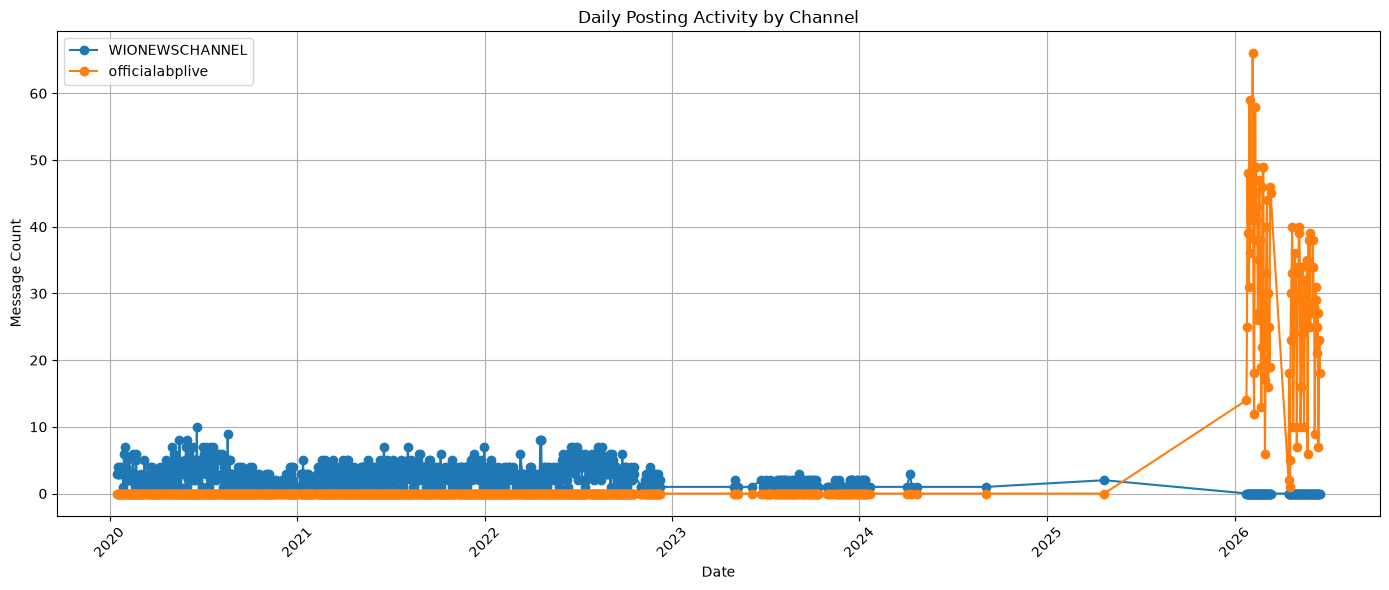

In [71]:
# ============================================================
# SERIAL 5 — CELL 3
# Daily posting timeline
# ============================================================

import matplotlib.pyplot as plt

daily_pivot = daily_activity.pivot_table(
    index="date_only",
    columns="channel",
    values="message_count",
    fill_value=0
)

plt.figure(figsize=(14, 6))

for channel in daily_pivot.columns:
    plt.plot(
        daily_pivot.index,
        daily_pivot[channel],
        marker="o",
        label=channel
    )

plt.title("Daily Posting Activity by Channel")
plt.xlabel("Date")
plt.ylabel("Message Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# SERIAL 5 — CELL 4
# Daily activity correlation matrix
# ============================================================

daily_correlation = daily_pivot.corr()

print("Daily posting correlation matrix:")
display(daily_correlation)

Daily posting correlation matrix:


channel,WIONEWSCHANNEL,officialabplive
channel,,
WIONEWSCHANNEL,1.00000,-0.43596
officialabplive,-0.43596,1.00000


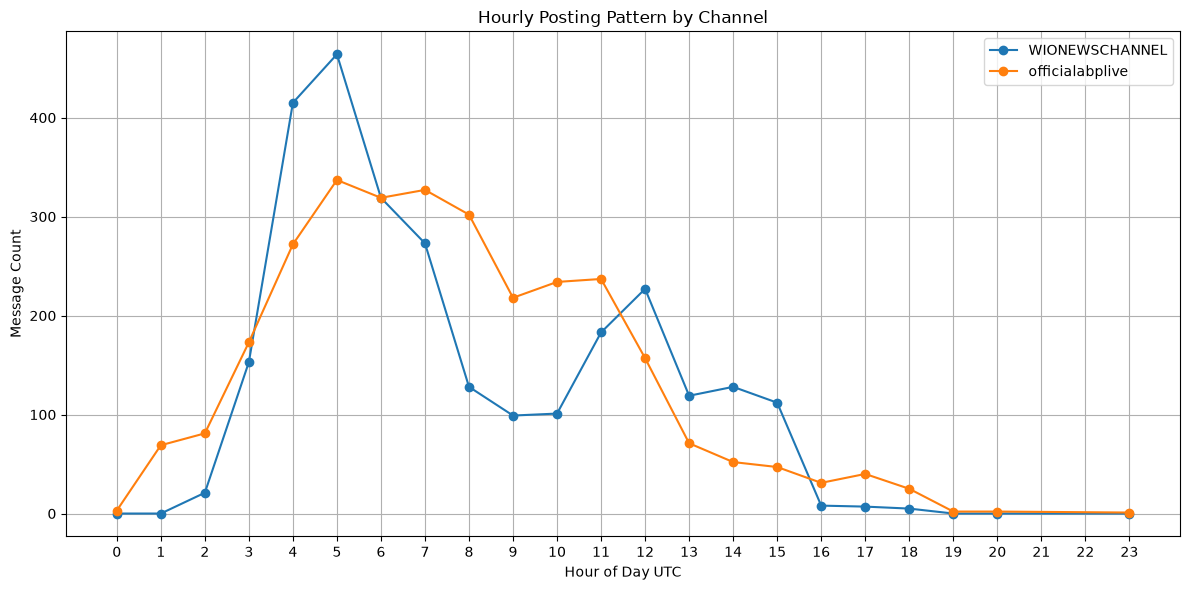

In [73]:
# ============================================================
# SERIAL 5 — CELL 5
# Hourly activity comparison
# ============================================================

hourly_pivot = hourly_activity.pivot_table(
    index="hour",
    columns="channel",
    values="message_count",
    fill_value=0
)

plt.figure(figsize=(12, 6))

for channel in hourly_pivot.columns:
    plt.plot(
        hourly_pivot.index,
        hourly_pivot[channel],
        marker="o",
        label=channel
    )

plt.title("Hourly Posting Pattern by Channel")
plt.xlabel("Hour of Day UTC")
plt.ylabel("Message Count")
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# SERIAL 5 — CELL 6
# Hourly activity correlation matrix
# ============================================================

hourly_correlation = hourly_pivot.corr()

print("Hourly posting correlation matrix:")
display(hourly_correlation)

Hourly posting correlation matrix:


channel,WIONEWSCHANNEL,officialabplive
channel,,
WIONEWSCHANNEL,1.000000,0.826254
officialabplive,0.826254,1.000000


In [75]:
# ============================================================
# SERIAL 5 — CELL 7
# Detect daily posting spikes
# ============================================================

spike_rows = []

for channel in daily_pivot.columns:

    series = daily_pivot[channel]

    mean_val = series.mean()
    std_val = series.std()

    # A spike is defined as activity more than 2 standard deviations above the channel's average
    threshold = mean_val + (2 * std_val)

    spike_days = series[series > threshold]

    for date, count in spike_days.items():
        spike_rows.append({
            "channel": channel,
            "date": date,
            "message_count": count,
            "average_daily_messages": round(mean_val, 2),
            "spike_threshold": round(threshold, 2)
        })

daily_spikes = pd.DataFrame(spike_rows)

if len(daily_spikes) > 0:
    display(daily_spikes.sort_values(["date", "message_count"], ascending=[True, False]))
else:
    print("No major daily spikes detected using the current threshold.")

,channel,date,message_count,average_daily_messages,spike_threshold
0,WIONEWSCHANNEL,2020-01-30,6.0,2.54,5.93
1,WIONEWSCHANNEL,2020-01-31,7.0,2.54,5.93
2,WIONEWSCHANNEL,2020-02-15,6.0,2.54,5.93
3,WIONEWSCHANNEL,2020-02-21,6.0,2.54,5.93
4,WIONEWSCHANNEL,2020-05-01,7.0,2.54,5.93
...,...,...,...,...,...
129,officialabplive,2026-06-08,31.0,2.76,21.78
130,officialabplive,2026-06-09,29.0,2.76,21.78
131,officialabplive,2026-06-10,25.0,2.76,21.78
132,officialabplive,2026-06-12,27.0,2.76,21.78


In [76]:
# ============================================================
# SERIAL 5 — CELL 8
# Shared spike days across channels
# ============================================================

if len(daily_spikes) > 0:

    shared_spike_days = (
        daily_spikes
        .groupby("date")
        .agg(
            channels=("channel", lambda x: sorted(set(x))),
            channel_count=("channel", "nunique"),
            total_spike_messages=("message_count", "sum")
        )
        .reset_index()
        .sort_values(["channel_count", "total_spike_messages"], ascending=False)
    )

    shared_spike_days = shared_spike_days[
        shared_spike_days["channel_count"] > 1
    ]

    display(shared_spike_days)

else:
    shared_spike_days = pd.DataFrame()
    print("No spike data available.")

,date,channels,channel_count,total_spike_messages


In [77]:
# ============================================================
# SERIAL 5 — CELL 9
# Simple daily lead-lag analysis
# ============================================================

from itertools import combinations

lead_lag_rows = []

channels = sorted(all_messages["channel"].unique())

for ch_a, ch_b in combinations(channels, 2):

    a_daily_first = (
        all_messages[all_messages["channel"] == ch_a]
        .groupby("date_only")["date"]
        .min()
        .reset_index(name="a_first_post")
    )

    b_daily_first = (
        all_messages[all_messages["channel"] == ch_b]
        .groupby("date_only")["date"]
        .min()
        .reset_index(name="b_first_post")
    )

    merged = a_daily_first.merge(
        b_daily_first,
        on="date_only",
        how="inner"
    )

    if len(merged) == 0:
        continue

    a_leads = (merged["a_first_post"] < merged["b_first_post"]).sum()
    b_leads = (merged["b_first_post"] < merged["a_first_post"]).sum()
    ties = (merged["a_first_post"] == merged["b_first_post"]).sum()

    lead_lag_rows.append({
        "channel_a": ch_a,
        "channel_b": ch_b,
        "shared_active_days": len(merged),
        "a_leads_days": int(a_leads),
        "b_leads_days": int(b_leads),
        "ties": int(ties),
        "a_lead_ratio": round(a_leads / len(merged), 3),
        "b_lead_ratio": round(b_leads / len(merged), 3)
    })

lead_lag_daily = pd.DataFrame(lead_lag_rows)

display(lead_lag_daily)

""


In [78]:
# ============================================================
# SERIAL 5 — CELL 10
# Temporal Analyst Interpretation
# ============================================================

print("=" * 80)
print("ANALYST INTERPRETATION")
print("=" * 80)

if len(hourly_correlation) > 1:
    print("\nHourly posting correlation:")
    display(hourly_correlation)

if len(daily_correlation) > 1:
    print("\nDaily posting correlation:")
    display(daily_correlation)

if len(daily_spikes) > 0:
    print(f"\nDaily spikes detected: {len(daily_spikes)}")
else:
    print("\nNo major daily posting spikes detected.")

if len(shared_spike_days) > 0:
    print(f"Shared spike days across channels: {len(shared_spike_days)}")
else:
    print("No shared spike days detected.")

if len(lead_lag_daily) > 0:
    strongest_lead = lead_lag_daily.sort_values(
        ["a_lead_ratio", "shared_active_days"],
        ascending=False
    ).iloc[0]

    print("\nStrongest observed daily lead pattern:")
    print(f"• {strongest_lead['channel_a']} leads {strongest_lead['channel_b']}")
    print(f"• Lead ratio: {strongest_lead['a_lead_ratio']}")
    print(f"• Shared active days: {strongest_lead['shared_active_days']}")

print("\nAnalyst notes:")
print("- Daily correlation shows whether channels become active on the same days.")
print("- Hourly correlation shows whether channels share similar posting schedules.")
print("- Shared spike days may indicate common reaction to major events.")
print("- Lead-lag patterns are preliminary and should later be tested against similar narratives or similar messages.")
print("- Timing alone does not prove coordination.")

ANALYST INTERPRETATION

Hourly posting correlation:


channel,WIONEWSCHANNEL,officialabplive
channel,,
WIONEWSCHANNEL,1.000000,0.826254
officialabplive,0.826254,1.000000



Daily posting correlation:


channel,WIONEWSCHANNEL,officialabplive
channel,,
WIONEWSCHANNEL,1.00000,-0.43596
officialabplive,-0.43596,1.00000



Daily spikes detected: 134
No shared spike days detected.

Analyst notes:
- Daily correlation shows whether channels become active on the same days.
- Hourly correlation shows whether channels share similar posting schedules.
- Shared spike days may indicate common reaction to major events.
- Lead-lag patterns are preliminary and should later be tested against similar narratives or similar messages.
- Timing alone does not prove coordination.


# Semantic Clustering: From Messages to Narrative Objects

## Objective

This section transforms raw Telegram messages into semantic clusters.

Instead of comparing every message with every other message, we group messages by meaning.

Each semantic cluster will later become a Narrative Object.

This approach is faster, more scalable, and more useful for OSINT because the goal is not to analyse isolated messages, but to understand which narratives appear across channels.

In [79]:
# ============================================================
# SERIAL 6A — CELL 1
# Prepare messages for semantic clustering
# ============================================================

semantic_messages = all_messages.copy()

# Ensure text is clean and usable
semantic_messages["clean_text"] = (
    semantic_messages["clean_text"]
    .fillna("")
    .astype(str)
)

# Keep only messages with enough text
semantic_messages = semantic_messages[
    semantic_messages["clean_text"].str.len() >= MIN_TEXT_LENGTH
].copy()

# Reset index so embedding rows match dataframe rows
semantic_messages = semantic_messages.reset_index(drop=True)

print("Messages available for semantic clustering:", len(semantic_messages))
print("Channels represented:", semantic_messages["channel"].nunique())

display(
    semantic_messages[
        ["channel", "date", "clean_text", "message_link"]
    ].head()
)

Messages available for semantic clustering: 5762
Channels represented: 2


,channel,date,clean_text,message_link
0,officialabplive,2026-06-16 11:16:02+00:00,[**iPhone Fold May Not Make It To Shelves This...,https://t.me/officialabplive/43083
1,officialabplive,2026-06-16 10:58:03+00:00,[**GTA 6 Isn't Out Yet But Someone Is Already ...,https://t.me/officialabplive/43082
2,officialabplive,2026-06-16 10:34:03+00:00,[**Apple Is Shutting Three Stores But Only One...,https://t.me/officialabplive/43081
3,officialabplive,2026-06-16 10:08:02+00:00,"[**Standard iPhone 18 Skipping September, Only...",https://t.me/officialabplive/43080
4,officialabplive,2026-06-16 07:16:03+00:00,[**FPI Ownership In Indian Equities Hits 15-Ye...,https://t.me/officialabplive/43079


In [80]:
# ============================================================
# SERIAL 6A — CELL 2
# Load multilingual embedding model
# ============================================================

from sentence_transformers import SentenceTransformer

# Faster multilingual model for notebook prototyping
EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

print("Loaded embedding model:")
print(EMBEDDING_MODEL_NAME)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded embedding model:
paraphrase-multilingual-MiniLM-L12-v2


In [81]:
# ============================================================
# SERIAL 6A — CELL 3
# Generate message embeddings
# ============================================================

texts = semantic_messages["clean_text"].tolist()

message_embeddings = embedding_model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings generated.")
print("Shape:", message_embeddings.shape)

Batches:   0%|          | 0/181 [00:00<?, ?it/s]

Embeddings generated.
Shape: (5762, 384)


In [82]:
# ============================================================
# SERIAL 6A — CELL 4
# Cache embeddings locally
# ============================================================

import numpy as np
import os

embedding_path = f"{OUTPUT_DIR}/message_embeddings.npy"
semantic_messages_path = f"{OUTPUT_DIR}/semantic_messages.csv"

np.save(embedding_path, message_embeddings)
semantic_messages.to_csv(semantic_messages_path, index=False)

print("Saved embeddings to:", embedding_path)
print("Saved semantic messages to:", semantic_messages_path)

Saved embeddings to: telegram_osint_outputs/message_embeddings.npy
Saved semantic messages to: telegram_osint_outputs/semantic_messages.csv


In [83]:
# ============================================================
# SERIAL 6A — CELL 5
# Reduce embedding dimensions with PCA
# ============================================================

from sklearn.decomposition import PCA

# Keep dimensions reasonable for clustering
PCA_COMPONENTS = min(50, message_embeddings.shape[1], len(message_embeddings) - 1)

pca = PCA(
    n_components=PCA_COMPONENTS,
    random_state=42
)

reduced_embeddings = pca.fit_transform(message_embeddings)

print("Original embedding shape:", message_embeddings.shape)
print("Reduced embedding shape:", reduced_embeddings.shape)
print("Explained variance retained:", round(pca.explained_variance_ratio_.sum(), 3))

Original embedding shape: (5762, 384)
Reduced embedding shape: (5762, 50)
Explained variance retained: 0.694


In [84]:
# ============================================================
# SERIAL 6A — CELL 6
# Cluster messages into semantic groups
# ============================================================

from sklearn.cluster import KMeans

# Rule of thumb for first test:
# roughly one cluster per 50 messages, bounded between 3 and 20.
NUM_CLUSTERS = min(
    20,
    max(3, len(semantic_messages) // 50)
)

kmeans = KMeans(
    n_clusters=NUM_CLUSTERS,
    random_state=42,
    n_init=10
)

semantic_messages["semantic_cluster"] = kmeans.fit_predict(reduced_embeddings)

print("Semantic clusters created:", NUM_CLUSTERS)

cluster_counts = (
    semantic_messages["semantic_cluster"]
    .value_counts()
    .reset_index()
)

cluster_counts.columns = ["semantic_cluster", "message_count"]

display(
    cluster_counts.sort_values("semantic_cluster")
)

Semantic clusters created: 20


,semantic_cluster,message_count
17,0,128
9,1,268
3,2,447
0,3,525
14,4,185
13,5,198
5,6,394
2,7,469
4,8,440
18,9,107


In [85]:
# ============================================================
# SERIAL 6A — CELL 7
# Inspect representative messages by semantic cluster
# ============================================================

for cluster_id in sorted(semantic_messages["semantic_cluster"].unique()):

    cluster_df = semantic_messages[
        semantic_messages["semantic_cluster"] == cluster_id
    ].copy()

    print("\n" + "=" * 100)
    print(f"SEMANTIC CLUSTER {cluster_id}")
    print(f"Messages: {len(cluster_df)}")
    print(f"Channels: {sorted(cluster_df['channel'].unique())}")
    print("=" * 100)

    # Show high-view messages first because they are often analyst-relevant
    sample_df = (
        cluster_df
        .sort_values("views", ascending=False)
        .head(5)
    )

    for _, row in sample_df.iterrows():
        print("\nChannel:", row["channel"])
        print("Date:", row["date"])
        print("Views:", row["views"])
        print("Forwards:", row["forwards"])
        print("Link:", row["message_link"])
        print("Text:", row["clean_text"][:700])
        print("-" * 100)


SEMANTIC CLUSTER 0
Messages: 128
Channels: ['officialabplive']

Channel: officialabplive
Date: 2026-03-12 05:28:02+00:00
Views: 41
Forwards: 0
Link: https://t.me/officialabplive/41722
Text: [**NYT Connections Answers (March 12): Puzzle #1004 Blew You Brain Out? Check Hints, & Solution**](https://news.abplive.com/gaming/nyt-connections-answers-march-12-tips-clues-hints-solution-how-to-play-1004-1830888) NYT Connections March 12 puzzle links sand, motion, exercise classes, and birds. See all hints and the full answers for today’s game. [ **Read More**](https://news.abplive.com/gaming/nyt-connections-answers-march-12-tips-clues-hints-solution-how-to-play-1004-1830888)
----------------------------------------------------------------------------------------------------

Channel: officialabplive
Date: 2026-05-11 05:00:02+00:00
Views: 28
Forwards: 0
Link: https://t.me/officialabplive/42293
Text: [**Wordle Answer Today (May 11): Puzzle #1787 Caught You Off-Guard? Check Hints, & Solution**](ht

In [86]:
# ============================================================
# SERIAL 6A — CELL 8
# Create semantic cluster centroids
# ============================================================

cluster_centroids = {}

for cluster_id in sorted(semantic_messages["semantic_cluster"].unique()):

    cluster_indices = semantic_messages[
        semantic_messages["semantic_cluster"] == cluster_id
    ].index.tolist()

    vectors = message_embeddings[cluster_indices]

    centroid = np.mean(vectors, axis=0)

    # Normalize centroid
    centroid = centroid / np.linalg.norm(centroid)

    cluster_centroids[cluster_id] = centroid

print("Cluster centroids created:", len(cluster_centroids))

Cluster centroids created: 20


In [87]:
# ============================================================
# SERIAL 6A — CELL 9
# Build Narrative Objects from semantic clusters
# ============================================================

narrative_rows = []

for cluster_id in sorted(semantic_messages["semantic_cluster"].unique()):

    cluster_df = semantic_messages[
        semantic_messages["semantic_cluster"] == cluster_id
    ].copy()

    channel_counts = (
        cluster_df["channel"]
        .value_counts()
        .to_dict()
    )

    language_counts = (
        cluster_df["language"]
        .value_counts()
        .to_dict()
        if "language" in cluster_df.columns
        else {}
    )

    representative_messages = (
        cluster_df
        .sort_values("views", ascending=False)
        [["channel", "date", "views", "forwards", "clean_text", "message_link"]]
        .head(5)
        .to_dict("records")
    )

    narrative_rows.append({
        "narrative_id": f"NARRATIVE_{cluster_id}",
        "semantic_cluster": cluster_id,
        "message_count": len(cluster_df),
        "channel_count": cluster_df["channel"].nunique(),
        "channels_present": sorted(cluster_df["channel"].unique()),
        "channel_message_counts": channel_counts,
        "language_counts": language_counts,
        "first_seen": cluster_df["date"].min(),
        "last_seen": cluster_df["date"].max(),
        "representative_messages": representative_messages,
        "placeholder_label": f"Semantic Narrative {cluster_id}"
    })

narrative_objects = pd.DataFrame(narrative_rows)

narrative_objects = narrative_objects.sort_values(
    ["channel_count", "message_count"],
    ascending=False
)

display(narrative_objects)

,narrative_id,semantic_cluster,message_count,channel_count,channels_present,channel_message_counts,language_counts,first_seen,last_seen,representative_messages,placeholder_label
3,NARRATIVE_3,3,525,2,"[WIONEWSCHANNEL, officialabplive]","{'WIONEWSCHANNEL': 391, 'officialabplive': 134}","{'en': 524, 'unknown': 1}",2020-01-17 10:10:12+00:00,2026-06-16 03:44:03+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2022-12...",Semantic Narrative 3
11,NARRATIVE_11,11,485,2,"[WIONEWSCHANNEL, officialabplive]","{'WIONEWSCHANNEL': 456, 'officialabplive': 29}","{'en': 483, 'no': 1, 'unknown': 1}",2020-02-01 04:11:43+00:00,2026-06-15 06:28:04+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2024-01...",Semantic Narrative 11
7,NARRATIVE_7,7,469,2,"[WIONEWSCHANNEL, officialabplive]","{'officialabplive': 312, 'WIONEWSCHANNEL': 157}",{'en': 469},2020-01-27 07:30:10+00:00,2026-06-16 02:32:03+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2023-11...",Semantic Narrative 7
2,NARRATIVE_2,2,447,2,"[WIONEWSCHANNEL, officialabplive]","{'officialabplive': 357, 'WIONEWSCHANNEL': 90}","{'en': 446, 'id': 1}",2020-01-16 12:13:47+00:00,2026-06-16 04:44:03+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2023-12...",Semantic Narrative 2
8,NARRATIVE_8,8,440,2,"[WIONEWSCHANNEL, officialabplive]","{'WIONEWSCHANNEL': 420, 'officialabplive': 20}","{'en': 439, 'de': 1}",2020-01-17 10:09:40+00:00,2026-06-10 06:46:05+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2024-04...",Semantic Narrative 8
6,NARRATIVE_6,6,394,2,"[WIONEWSCHANNEL, officialabplive]","{'officialabplive': 297, 'WIONEWSCHANNEL': 97}",{'en': 394},2020-01-31 12:19:33+00:00,2026-06-16 07:16:03+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2022-04...",Semantic Narrative 6
16,NARRATIVE_16,16,358,2,"[WIONEWSCHANNEL, officialabplive]","{'officialabplive': 339, 'WIONEWSCHANNEL': 19}",{'en': 358},2020-04-09 13:40:28+00:00,2026-06-02 10:16:05+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2022-08...",Semantic Narrative 16
13,NARRATIVE_13,13,339,2,"[WIONEWSCHANNEL, officialabplive]","{'officialabplive': 257, 'WIONEWSCHANNEL': 82}","{'en': 336, 'ca': 1, 'unknown': 1, 'af': 1}",2020-01-22 09:24:21+00:00,2026-06-16 10:58:03+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2021-10...",Semantic Narrative 13
17,NARRATIVE_17,17,293,2,"[WIONEWSCHANNEL, officialabplive]","{'officialabplive': 272, 'WIONEWSCHANNEL': 21}",{'en': 293},2020-02-01 11:05:31+00:00,2026-06-16 05:30:02+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2022-05...",Semantic Narrative 17
1,NARRATIVE_1,1,268,2,"[WIONEWSCHANNEL, officialabplive]","{'WIONEWSCHANNEL': 255, 'officialabplive': 13}","{'en': 267, 'de': 1}",2020-01-22 06:43:31+00:00,2026-06-02 05:26:04+00:00,"[{'channel': 'WIONEWSCHANNEL', 'date': 2023-10...",Semantic Narrative 1


In [88]:
# ============================================================
# SERIAL 6A — CELL 10
# Build Channel Narrative Profile
# ============================================================

channel_narrative_matrix = semantic_messages.pivot_table(
    index="channel",
    columns="semantic_cluster",
    values="message_id",
    aggfunc="count",
    fill_value=0
)

display(channel_narrative_matrix)

semantic_cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
channel,,,,,,,,,,,,,,,,,,,,
WIONEWSCHANNEL,0,255,90,391,185,8,97,157,420,0,74,456,230,82,2,257,19,21,9,9
officialabplive,128,13,357,134,0,190,297,312,20,107,0,29,4,257,142,7,339,272,237,155


In [89]:
# ============================================================
# SERIAL 6A — CELL 11
# Compare channels by narrative participation
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

channel_narrative_similarity_matrix = cosine_similarity(
    channel_narrative_matrix.values
)

channel_narrative_similarity = pd.DataFrame(
    channel_narrative_similarity_matrix,
    index=channel_narrative_matrix.index,
    columns=channel_narrative_matrix.index
)

display(channel_narrative_similarity)

channel,WIONEWSCHANNEL,officialabplive
channel,,
WIONEWSCHANNEL,1.000000,0.292736
officialabplive,0.292736,1.000000


In [90]:
# ============================================================
# SERIAL 6A — CELL 12
# Channel pair semantic/narrative similarity table
# ============================================================

from itertools import combinations

pair_rows = []

channels = list(channel_narrative_matrix.index)

for ch_a, ch_b in combinations(channels, 2):

    similarity = channel_narrative_similarity.loc[ch_a, ch_b]

    pair_rows.append({
        "channel_a": ch_a,
        "channel_b": ch_b,
        "narrative_participation_similarity": round(float(similarity), 4)
    })

channel_narrative_similarity_pairs = pd.DataFrame(pair_rows).sort_values(
    "narrative_participation_similarity",
    ascending=False
)

display(channel_narrative_similarity_pairs)

,channel_a,channel_b,narrative_participation_similarity
0,WIONEWSCHANNEL,officialabplive,0.2927


In [91]:
# ============================================================
# SERIAL 6A — CELL 13
# Analyst interpretation
# ============================================================

print("=" * 80)
print("SEMANTIC CLUSTERING / NARRATIVE OBJECTS SUMMARY")
print("=" * 80)

print(f"\nMessages clustered: {len(semantic_messages):,}")
print(f"Channels analysed : {semantic_messages['channel'].nunique()}")
print(f"Narrative objects : {len(narrative_objects)}")

top_narrative = narrative_objects.iloc[0]

print("\nMost cross-channel narrative object:")
print(f"• Narrative ID: {top_narrative['narrative_id']}")
print(f"• Messages: {top_narrative['message_count']}")
print(f"• Channels present: {top_narrative['channel_count']}")
print(f"• Channels: {top_narrative['channels_present']}")

if len(channel_narrative_similarity_pairs) > 0:
    top_pair = channel_narrative_similarity_pairs.iloc[0]

    print("\nMost similar channel pair by narrative participation:")
    print(f"• {top_pair['channel_a']} ↔ {top_pair['channel_b']}")
    print(f"• Similarity: {top_pair['narrative_participation_similarity']}")

print("\nAnalyst notes:")
print("- Messages are now grouped into semantic clusters.")
print("- Each cluster is treated as a candidate Narrative Object.")
print("- Channel comparison is now based on participation in shared narratives.")
print("- This is more scalable than comparing every message to every other message.")
print("- Next step: use an LLM to label each Narrative Object with a human-readable narrative name.")

SEMANTIC CLUSTERING / NARRATIVE OBJECTS SUMMARY

Messages clustered: 5,762
Channels analysed : 2
Narrative objects : 20

Most cross-channel narrative object:
• Narrative ID: NARRATIVE_3
• Messages: 525
• Channels present: 2
• Channels: ['WIONEWSCHANNEL', 'officialabplive']

Most similar channel pair by narrative participation:
• WIONEWSCHANNEL ↔ officialabplive
• Similarity: 0.2927

Analyst notes:
- Messages are now grouped into semantic clusters.
- Each cluster is treated as a candidate Narrative Object.
- Channel comparison is now based on participation in shared narratives.
- This is more scalable than comparing every message to every other message.
- Next step: use an LLM to label each Narrative Object with a human-readable narrative name.


# LLM Narrative Object Labelling

## Objective

This section uses an LLM to label each Narrative Object.

Each Narrative Object already contains:

- Representative messages
- Channels involved
- First seen / last seen
- Languages
- Message count
- Channel count

The LLM will review representative messages and return:

- Narrative label
- Short summary
- Main actors
- Tone / framing
- Confidence score

This makes the semantic clusters human-readable and analyst-friendly.

In [93]:
# ============================================================
# SERIAL 6B — CELL 1
# Create LLM input package for each Narrative Object
# ============================================================

def build_narrative_prompt(row):
    """
    Build a compact prompt for one Narrative Object.

    The LLM receives only representative messages from the cluster,
    not every message in the cluster.
    """

    messages_text = ""

    for i, msg in enumerate(row["representative_messages"], start=1):

        # Safely extract message fields
        channel = msg.get("channel", "unknown")
        date = msg.get("date", "unknown")
        views = msg.get("views", "unknown")
        text = str(msg.get("clean_text", ""))[:1200]

        messages_text += f"""
Message {i}
Channel: {channel}
Date: {date}
Views: {views}
Text:
{text}
"""

    prompt = f"""
You are an OSINT analyst reviewing a Telegram semantic cluster.

Your task is to label the cluster as a human-readable narrative or topic.

Narrative Object:
ID: {row["narrative_id"]}
Message count: {row["message_count"]}
Channels present: {row["channels_present"]}
First seen: {row["first_seen"]}
Last seen: {row["last_seen"]}

Representative messages:
{messages_text}

Return JSON only with this structure:

{{
  "narrative_label": "...",
  "summary": "...",
  "main_actors": ["..."],
  "tone_or_framing": "...",
  "confidence": 0.0,
  "reason": "..."
}}
"""

    return prompt


# Create prompts for every Narrative Object
narrative_objects["llm_prompt"] = narrative_objects.apply(
    build_narrative_prompt,
    axis=1
)

print("LLM prompts created:", len(narrative_objects))

# Preview first prompt package
display(
    narrative_objects[
        [
            "narrative_id",
            "message_count",
            "channel_count",
            "llm_prompt"
        ]
    ].head(1)
)

LLM prompts created: 20


,narrative_id,message_count,channel_count,llm_prompt
3,NARRATIVE_3,525,2,\nYou are an OSINT analyst reviewing a Telegra...


In [94]:
# ============================================================
# SERIAL 6B — CELL 2
# Preview one LLM prompt
# ============================================================

sample_prompt = narrative_objects.iloc[0]["llm_prompt"]

print(sample_prompt[:4000])


You are an OSINT analyst reviewing a Telegram semantic cluster.

Your task is to label the cluster as a human-readable narrative or topic.

Narrative Object:
ID: NARRATIVE_3
Message count: 525
Channels present: ['WIONEWSCHANNEL', 'officialabplive']
First seen: 2020-01-17 10:10:12+00:00
Last seen: 2026-06-16 03:44:03+00:00

Representative messages:

Message 1
Channel: WIONEWSCHANNEL
Date: 2022-12-09 05:37:12+00:00
Views: 10917
Text:
*Gravitas as on 8th December 2022* *Gravitas: A new axis between China, Saudi Arabia, Pakistan* A new axis is in the making between China, Saudi Arabia and Pakistan. Riyadh, Beijing have signed 34 agreements. Has India become collateral damage? Molly Gambhir tells you. https://www.youtube.com/watch?v=ty9aFGnjwrI *Gravitas: Iran Supreme leader's family slams crackdown* Iran has carried out its first protest-related execution. A 23-yr-old has been executed for allegedly attacking an Iranian security official. Is this the beginning of a more brutal crackdown? 

In [95]:
# ============================================================
# SERIAL 6B — CELL 3
# Manual labelling fallback
# ============================================================

narrative_labels_manual = {}

for _, row in narrative_objects.iterrows():

    narrative_id = row["narrative_id"]

    print("\n" + "=" * 100)
    print(narrative_id)
    print("=" * 100)

    for msg in row["representative_messages"][:3]:
        print("\nChannel:", msg.get("channel"))
        print("Date:", msg.get("date"))
        print("Text:", msg.get("clean_text")[:700])
        print("-" * 80)

    # Default placeholder; you can edit this dictionary manually later.
    narrative_labels_manual[narrative_id] = {
        "narrative_label": row["placeholder_label"],
        "summary": "Manual review required.",
        "main_actors": [],
        "tone_or_framing": "Unknown",
        "confidence": 0.0,
        "reason": "Placeholder label created without LLM."
    }

print("\nManual placeholder labels created.")


NARRATIVE_3

Channel: WIONEWSCHANNEL
Date: 2022-12-09 05:37:12+00:00
Text: *Gravitas as on 8th December 2022* *Gravitas: A new axis between China, Saudi Arabia, Pakistan* A new axis is in the making between China, Saudi Arabia and Pakistan. Riyadh, Beijing have signed 34 agreements. Has India become collateral damage? Molly Gambhir tells you. https://www.youtube.com/watch?v=ty9aFGnjwrI *Gravitas: Iran Supreme leader's family slams crackdown* Iran has carried out its first protest-related execution. A 23-yr-old has been executed for allegedly attacking an Iranian security official. Is this the beginning of a more brutal crackdown? Molly Gambhir reports. https://www.youtube.com/watch?v=bnHUIPpcxOY *Gravitas: Taliban stages first public execution since coming to power
--------------------------------------------------------------------------------

Channel: WIONEWSCHANNEL
Date: 2024-09-03 06:04:59+00:00
Text: 'Israel must retain key corridor' and other WION headlines
--------------------

In [97]:
# ============================================================
# SERIAL 6B — CELL 4
# Apply manual labels to Narrative Objects
# ============================================================

label_rows = []

for narrative_id, label_data in narrative_labels_manual.items():

    label_rows.append({
        "narrative_id": narrative_id,
        "narrative_label": label_data["narrative_label"],
        "summary": label_data["summary"],
        "main_actors": label_data["main_actors"],
        "tone_or_framing": label_data["tone_or_framing"],
        "label_confidence": label_data["confidence"],
        "label_reason": label_data["reason"]
    })

narrative_labels_df = pd.DataFrame(label_rows)

narrative_objects_labelled = narrative_objects.merge(
    narrative_labels_df,
    on="narrative_id",
    how="left"
)

display(
    narrative_objects_labelled[
        [
            "narrative_id",
            "narrative_label",
            "message_count",
            "channel_count",
            "channels_present",
            "summary",
            "tone_or_framing",
            "label_confidence"
        ]
    ]
)

,narrative_id,narrative_label,message_count,channel_count,channels_present,summary,tone_or_framing,label_confidence
0,NARRATIVE_3,Semantic Narrative 3,525,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0
1,NARRATIVE_11,Semantic Narrative 11,485,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0
2,NARRATIVE_7,Semantic Narrative 7,469,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0
3,NARRATIVE_2,Semantic Narrative 2,447,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0
4,NARRATIVE_8,Semantic Narrative 8,440,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0
5,NARRATIVE_6,Semantic Narrative 6,394,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0
6,NARRATIVE_16,Semantic Narrative 16,358,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0
7,NARRATIVE_13,Semantic Narrative 13,339,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0
8,NARRATIVE_17,Semantic Narrative 17,293,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0
9,NARRATIVE_1,Semantic Narrative 1,268,2,"[WIONEWSCHANNEL, officialabplive]",Manual review required.,Unknown,0.0


In [98]:
# ============================================================
# SERIAL 6B — CELL 5
# Map Narrative Object labels back to messages
# ============================================================

cluster_to_narrative_id = dict(
    zip(
        narrative_objects_labelled["semantic_cluster"],
        narrative_objects_labelled["narrative_id"]
    )
)

cluster_to_label = dict(
    zip(
        narrative_objects_labelled["semantic_cluster"],
        narrative_objects_labelled["narrative_label"]
    )
)

semantic_messages["narrative_id"] = semantic_messages["semantic_cluster"].map(
    cluster_to_narrative_id
)

semantic_messages["narrative_label"] = semantic_messages["semantic_cluster"].map(
    cluster_to_label
)

display(
    semantic_messages[
        [
            "channel",
            "date",
            "semantic_cluster",
            "narrative_id",
            "narrative_label",
            "clean_text",
            "message_link"
        ]
    ].head()
)

,channel,date,semantic_cluster,narrative_id,narrative_label,clean_text,message_link
0,officialabplive,2026-06-16 11:16:02+00:00,14,NARRATIVE_14,Semantic Narrative 14,[**iPhone Fold May Not Make It To Shelves This...,https://t.me/officialabplive/43083
1,officialabplive,2026-06-16 10:58:03+00:00,13,NARRATIVE_13,Semantic Narrative 13,[**GTA 6 Isn't Out Yet But Someone Is Already ...,https://t.me/officialabplive/43082
2,officialabplive,2026-06-16 10:34:03+00:00,13,NARRATIVE_13,Semantic Narrative 13,[**Apple Is Shutting Three Stores But Only One...,https://t.me/officialabplive/43081
3,officialabplive,2026-06-16 10:08:02+00:00,14,NARRATIVE_14,Semantic Narrative 14,"[**Standard iPhone 18 Skipping September, Only...",https://t.me/officialabplive/43080
4,officialabplive,2026-06-16 07:16:03+00:00,6,NARRATIVE_6,Semantic Narrative 6,[**FPI Ownership In Indian Equities Hits 15-Ye...,https://t.me/officialabplive/43079


In [99]:
# ============================================================
# SERIAL 6B — CELL 6
# Build labelled channel narrative profile
# ============================================================

labelled_channel_narrative_matrix = semantic_messages.pivot_table(
    index="channel",
    columns="narrative_label",
    values="message_id",
    aggfunc="count",
    fill_value=0
)

display(labelled_channel_narrative_matrix)

narrative_label,Semantic Narrative 0,Semantic Narrative 1,Semantic Narrative 10,Semantic Narrative 11,Semantic Narrative 12,Semantic Narrative 13,Semantic Narrative 14,Semantic Narrative 15,Semantic Narrative 16,Semantic Narrative 17,Semantic Narrative 18,Semantic Narrative 19,Semantic Narrative 2,Semantic Narrative 3,Semantic Narrative 4,Semantic Narrative 5,Semantic Narrative 6,Semantic Narrative 7,Semantic Narrative 8,Semantic Narrative 9
channel,,,,,,,,,,,,,,,,,,,,
WIONEWSCHANNEL,0,255,74,456,230,82,2,257,19,21,9,9,90,391,185,8,97,157,420,0
officialabplive,128,13,0,29,4,257,142,7,339,272,237,155,357,134,0,190,297,312,20,107


In [100]:
# ============================================================
# SERIAL 6B — CELL 7
# Narrative distribution by channel
# ============================================================

narrative_distribution = (
    semantic_messages
    .groupby(["channel", "narrative_label"])
    .size()
    .reset_index(name="message_count")
    .sort_values(["channel", "message_count"], ascending=[True, False])
)

display(narrative_distribution)

,channel,narrative_label,message_count
2,WIONEWSCHANNEL,Semantic Narrative 11,456
17,WIONEWSCHANNEL,Semantic Narrative 8,420
12,WIONEWSCHANNEL,Semantic Narrative 3,391
6,WIONEWSCHANNEL,Semantic Narrative 15,257
0,WIONEWSCHANNEL,Semantic Narrative 1,255
3,WIONEWSCHANNEL,Semantic Narrative 12,230
13,WIONEWSCHANNEL,Semantic Narrative 4,185
16,WIONEWSCHANNEL,Semantic Narrative 7,157
15,WIONEWSCHANNEL,Semantic Narrative 6,97
11,WIONEWSCHANNEL,Semantic Narrative 2,90


In [101]:
# ============================================================
# SERIAL 6B — CELL 8
# Analyst interpretation
# ============================================================

print("=" * 80)
print("LLM / MANUAL NARRATIVE LABELLING SUMMARY")
print("=" * 80)

print(f"\nNarrative objects labelled: {len(narrative_objects_labelled)}")
print(f"Messages mapped to narratives: {semantic_messages['narrative_id'].notna().sum()}")

top_narratives = (
    semantic_messages
    .groupby("narrative_label")
    .size()
    .reset_index(name="message_count")
    .sort_values("message_count", ascending=False)
)

print("\nTop narratives by message volume:")
display(top_narratives.head(10))

print("\nAnalyst notes:")
print("- Semantic clusters are now human-readable Narrative Objects.")
print("- Labels should be reviewed by an analyst before drawing conclusions.")
print("- Later, an LLM API can replace the manual placeholder labelling step.")
print("- These labelled narratives are now ready for propagation and correlation analysis.")

LLM / MANUAL NARRATIVE LABELLING SUMMARY

Narrative objects labelled: 20
Messages mapped to narratives: 5762

Top narratives by message volume:


,narrative_label,message_count
13,Semantic Narrative 3,525
3,Semantic Narrative 11,485
17,Semantic Narrative 7,469
12,Semantic Narrative 2,447
18,Semantic Narrative 8,440
16,Semantic Narrative 6,394
8,Semantic Narrative 16,358
5,Semantic Narrative 13,339
9,Semantic Narrative 17,293
1,Semantic Narrative 1,268



Analyst notes:
- Semantic clusters are now human-readable Narrative Objects.
- Labels should be reviewed by an analyst before drawing conclusions.
- Later, an LLM API can replace the manual placeholder labelling step.
- These labelled narratives are now ready for propagation and correlation analysis.


# Narrative Propagation Engine

## Objective

This section analyses how labelled narratives appear and move across Telegram channels over time.

For each narrative, we identify:

- First observed channel
- First observed message
- Early adopter channels
- Later amplifier channels
- Channel-level narrative timelines
- Narrative spread sequence

This analysis is based only on the channels and messages collected in the notebook.

Important:

"First observed channel" means the earliest occurrence in the collected dataset. It does not prove the true origin of the narrative.

In [103]:
# ============================================================
# SERIAL 6C — CELL 1
# Validate required objects
# ============================================================

required_objects = [
    "semantic_messages",
    "narrative_objects_labelled"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"{obj} is missing. Run Serial 6A and 6B first.")

required_columns = [
    "channel",
    "date",
    "message_id",
    "clean_text",
    "message_link",
    "narrative_id",
    "narrative_label"
]

missing_columns = [
    col for col in required_columns
    if col not in semantic_messages.columns
]

if missing_columns:
    raise KeyError(f"Missing required columns in semantic_messages: {missing_columns}")

# Ensure date is datetime
semantic_messages["date"] = pd.to_datetime(
    semantic_messages["date"],
    errors="coerce"
)

print("Required objects and columns validated.")
print("Messages with narrative labels:", semantic_messages["narrative_id"].notna().sum())
print("Narratives available:", semantic_messages["narrative_id"].nunique())

Required objects and columns validated.
Messages with narrative labels: 5762
Narratives available: 20


In [104]:
# ============================================================
# SERIAL 6C — CELL 2
# Build narrative timeline table
# ============================================================

# Keep only labelled narrative messages
narrative_timeline = semantic_messages[
    semantic_messages["narrative_id"].notna()
].copy()

# Sort by narrative and time
narrative_timeline = narrative_timeline.sort_values(
    ["narrative_id", "date"],
    ascending=True
)

# Add sequence number inside each narrative
narrative_timeline["narrative_sequence"] = (
    narrative_timeline
    .groupby("narrative_id")
    .cumcount() + 1
)

display(
    narrative_timeline[
        [
            "narrative_id",
            "narrative_label",
            "narrative_sequence",
            "channel",
            "date",
            "views",
            "forwards",
            "clean_text",
            "message_link"
        ]
    ].head(20)
)

,narrative_id,narrative_label,narrative_sequence,channel,date,views,forwards,clean_text,message_link
2955,NARRATIVE_0,Semantic Narrative 0,1,officialabplive,2026-01-26 04:30:02+00:00,26,0,[**Wordle Answer Today (January 26): Puzzle #1...,https://t.me/officialabplive/40128
2954,NARRATIVE_0,Semantic Narrative 0,2,officialabplive,2026-01-26 04:44:04+00:00,25,0,[**NYT Connections Answers (January 26): Puzzl...,https://t.me/officialabplive/40129
2911,NARRATIVE_0,Semantic Narrative 0,3,officialabplive,2026-01-27 03:22:02+00:00,18,0,[**Wordle Answer Today (January 27): Puzzle #1...,https://t.me/officialabplive/40172
2910,NARRATIVE_0,Semantic Narrative 0,4,officialabplive,2026-01-27 03:34:02+00:00,15,0,[**NYT Connections Answers (January 27): Puzzl...,https://t.me/officialabplive/40173
2829,NARRATIVE_0,Semantic Narrative 0,5,officialabplive,2026-01-29 04:40:02+00:00,10,0,[**Wordle Answer Today (January 29): Puzzle #1...,https://t.me/officialabplive/40254
2828,NARRATIVE_0,Semantic Narrative 0,6,officialabplive,2026-01-29 04:48:02+00:00,11,0,[**NYT Connections Answers (January 29): Puzzl...,https://t.me/officialabplive/40255
2788,NARRATIVE_0,Semantic Narrative 0,7,officialabplive,2026-01-30 05:48:03+00:00,14,0,[**Wordle Answer Today (January 30): Puzzle #1...,https://t.me/officialabplive/40295
2786,NARRATIVE_0,Semantic Narrative 0,8,officialabplive,2026-01-30 05:56:02+00:00,16,0,[**NYT Connections Answers (January 30): Puzzl...,https://t.me/officialabplive/40297
2655,NARRATIVE_0,Semantic Narrative 0,9,officialabplive,2026-02-02 05:42:02+00:00,23,0,[**Wordle Answer Today (February 2): Puzzle #1...,https://t.me/officialabplive/40428
2653,NARRATIVE_0,Semantic Narrative 0,10,officialabplive,2026-02-02 06:00:02+00:00,20,0,[**NYT Connections Answers (February 2): Puzzl...,https://t.me/officialabplive/40430


In [105]:
# ============================================================
# SERIAL 6C — CELL 3
# First observed message per narrative
# ============================================================

first_observed_messages = (
    narrative_timeline
    .sort_values("date", ascending=True)
    .groupby("narrative_id")
    .head(1)
    [
        [
            "narrative_id",
            "narrative_label",
            "channel",
            "date",
            "message_id",
            "views",
            "forwards",
            "clean_text",
            "message_link"
        ]
    ]
    .rename(columns={
        "channel": "first_observed_channel",
        "date": "first_observed_date",
        "message_id": "first_observed_message_id",
        "views": "first_observed_views",
        "forwards": "first_observed_forwards",
        "clean_text": "first_observed_text",
        "message_link": "first_observed_link"
    })
    .reset_index(drop=True)
)

display(first_observed_messages)

,narrative_id,narrative_label,first_observed_channel,first_observed_date,first_observed_message_id,first_observed_views,first_observed_forwards,first_observed_text,first_observed_link
0,NARRATIVE_15,Semantic Narrative 15,WIONEWSCHANNEL,2020-01-16 12:11:36+00:00,3,205,2,*WION Top Stories*,https://t.me/WIONEWSCHANNEL/3
1,NARRATIVE_2,Semantic Narrative 2,WIONEWSCHANNEL,2020-01-16 12:13:47+00:00,5,171,1,*Top stories* *Family of British explorer retu...,https://t.me/WIONEWSCHANNEL/5
2,NARRATIVE_8,Semantic Narrative 8,WIONEWSCHANNEL,2020-01-17 10:09:40+00:00,6,184,2,*WION : Russia-China-India : A Complex Equation*,https://t.me/WIONEWSCHANNEL/6
3,NARRATIVE_3,Semantic Narrative 3,WIONEWSCHANNEL,2020-01-17 10:10:12+00:00,8,179,1,"*Top stories* *Pakistan's court awards 4,738 y...",https://t.me/WIONEWSCHANNEL/8
4,NARRATIVE_1,Semantic Narrative 1,WIONEWSCHANNEL,2020-01-22 06:43:31+00:00,21,112,1,*WION: Coronavirus Explained*,https://t.me/WIONEWSCHANNEL/21
5,NARRATIVE_13,Semantic Narrative 13,WIONEWSCHANNEL,2020-01-22 09:24:21+00:00,22,129,1,*Top stories* *SOUTH ASIA : No business can st...,https://t.me/WIONEWSCHANNEL/22
6,NARRATIVE_10,Semantic Narrative 10,WIONEWSCHANNEL,2020-01-22 13:00:35+00:00,23,46,0,Photo from WION,https://t.me/WIONEWSCHANNEL/23
7,NARRATIVE_7,Semantic Narrative 7,WIONEWSCHANNEL,2020-01-27 07:30:10+00:00,33,119,2,*WION : CORONAVIRUS & INDIA'S RESPONSE*,https://t.me/WIONEWSCHANNEL/33
8,NARRATIVE_6,Semantic Narrative 6,WIONEWSCHANNEL,2020-01-31 12:19:33+00:00,51,35,0,*WION- IBM appoints Indian origin CEO & other ...,https://t.me/WIONEWSCHANNEL/51
9,NARRATIVE_11,Semantic Narrative 11,WIONEWSCHANNEL,2020-02-01 04:11:43+00:00,54,103,1,*WION : UK LEAVES THE EUROPEAN UNION*,https://t.me/WIONEWSCHANNEL/54


In [106]:
# ============================================================
# SERIAL 6C — CELL 4
# First observed channel summary
# ============================================================

first_observed_channel_summary = (
    first_observed_messages
    .groupby("first_observed_channel")
    .agg(
        narratives_first_observed=("narrative_id", "count"),
        narrative_ids=("narrative_id", lambda x: list(x))
    )
    .reset_index()
    .sort_values("narratives_first_observed", ascending=False)
)

display(first_observed_channel_summary)

,first_observed_channel,narratives_first_observed,narrative_ids
0,WIONEWSCHANNEL,18,"[NARRATIVE_15, NARRATIVE_2, NARRATIVE_8, NARRA..."
1,officialabplive,2,"[NARRATIVE_0, NARRATIVE_9]"


In [107]:
# ============================================================
# SERIAL 6C — CELL 5
# Channel-level first appearance per narrative
# ============================================================

channel_first_appearance = (
    narrative_timeline
    .sort_values("date", ascending=True)
    .groupby(["narrative_id", "narrative_label", "channel"])
    .agg(
        first_channel_post_date=("date", "min"),
        total_messages=("message_id", "count"),
        total_views=("views", "sum"),
        total_forwards=("forwards", "sum")
    )
    .reset_index()
)

display(
    channel_first_appearance
    .sort_values(["narrative_id", "first_channel_post_date"])
)

,narrative_id,narrative_label,channel,first_channel_post_date,total_messages,total_views,total_forwards
0,NARRATIVE_0,Semantic Narrative 0,officialabplive,2026-01-26 04:30:02+00:00,128,2067,0
1,NARRATIVE_1,Semantic Narrative 1,WIONEWSCHANNEL,2020-01-22 06:43:31+00:00,255,239627,807
2,NARRATIVE_1,Semantic Narrative 1,officialabplive,2026-01-30 07:28:04+00:00,13,239,0
3,NARRATIVE_10,Semantic Narrative 10,WIONEWSCHANNEL,2020-01-22 13:00:35+00:00,74,27543,39
4,NARRATIVE_11,Semantic Narrative 11,WIONEWSCHANNEL,2020-02-01 04:11:43+00:00,456,708215,2384
5,NARRATIVE_11,Semantic Narrative 11,officialabplive,2026-01-26 17:26:04+00:00,29,542,0
6,NARRATIVE_12,Semantic Narrative 12,WIONEWSCHANNEL,2020-03-03 10:21:35+00:00,230,577283,1277
7,NARRATIVE_12,Semantic Narrative 12,officialabplive,2026-01-24 14:00:04+00:00,4,79,0
8,NARRATIVE_13,Semantic Narrative 13,WIONEWSCHANNEL,2020-01-22 09:24:21+00:00,82,114424,504
9,NARRATIVE_13,Semantic Narrative 13,officialabplive,2026-01-27 09:08:04+00:00,257,4663,15


In [108]:
# ============================================================
# SERIAL 6C — CELL 6
# Propagation sequence per narrative
# ============================================================

propagation_rows = []

for narrative_id in sorted(channel_first_appearance["narrative_id"].unique()):

    subset = channel_first_appearance[
        channel_first_appearance["narrative_id"] == narrative_id
    ].copy()

    subset = subset.sort_values("first_channel_post_date")

    first_time = subset["first_channel_post_date"].min()

    subset["hours_after_first_observed"] = (
        (subset["first_channel_post_date"] - first_time)
        .dt.total_seconds() / 3600
    ).round(2)

    subset["propagation_rank"] = range(1, len(subset) + 1)

    propagation_rows.append(subset)

if propagation_rows:
    propagation_sequence = pd.concat(propagation_rows, ignore_index=True)
else:
    propagation_sequence = pd.DataFrame()

display(
    propagation_sequence[
        [
            "narrative_id",
            "narrative_label",
            "propagation_rank",
            "channel",
            "first_channel_post_date",
            "hours_after_first_observed",
            "total_messages",
            "total_views",
            "total_forwards"
        ]
    ].sort_values(["narrative_id", "propagation_rank"])
)

,narrative_id,narrative_label,propagation_rank,channel,first_channel_post_date,hours_after_first_observed,total_messages,total_views,total_forwards
0,NARRATIVE_0,Semantic Narrative 0,1,officialabplive,2026-01-26 04:30:02+00:00,0.00,128,2067,0
1,NARRATIVE_1,Semantic Narrative 1,1,WIONEWSCHANNEL,2020-01-22 06:43:31+00:00,0.00,255,239627,807
2,NARRATIVE_1,Semantic Narrative 1,2,officialabplive,2026-01-30 07:28:04+00:00,52800.74,13,239,0
3,NARRATIVE_10,Semantic Narrative 10,1,WIONEWSCHANNEL,2020-01-22 13:00:35+00:00,0.00,74,27543,39
4,NARRATIVE_11,Semantic Narrative 11,1,WIONEWSCHANNEL,2020-02-01 04:11:43+00:00,0.00,456,708215,2384
5,NARRATIVE_11,Semantic Narrative 11,2,officialabplive,2026-01-26 17:26:04+00:00,52477.24,29,542,0
6,NARRATIVE_12,Semantic Narrative 12,1,WIONEWSCHANNEL,2020-03-03 10:21:35+00:00,0.00,230,577283,1277
7,NARRATIVE_12,Semantic Narrative 12,2,officialabplive,2026-01-24 14:00:04+00:00,51675.64,4,79,0
8,NARRATIVE_13,Semantic Narrative 13,1,WIONEWSCHANNEL,2020-01-22 09:24:21+00:00,0.00,82,114424,504
9,NARRATIVE_13,Semantic Narrative 13,2,officialabplive,2026-01-27 09:08:04+00:00,52727.73,257,4663,15


In [109]:
# ============================================================
# SERIAL 6C — CELL 7
# Classify channel role per narrative
# ============================================================

def classify_propagation_role(row):
    """
    Assigns a simple role based on propagation rank.
    This is descriptive, not definitive attribution.
    """

    if row["propagation_rank"] == 1:
        return "first_observed"

    elif row["propagation_rank"] <= 3:
        return "early_adopter"

    else:
        return "later_amplifier"


if len(propagation_sequence) > 0:
    propagation_sequence["propagation_role"] = propagation_sequence.apply(
        classify_propagation_role,
        axis=1
    )

display(
    propagation_sequence[
        [
            "narrative_id",
            "narrative_label",
            "channel",
            "propagation_rank",
            "propagation_role",
            "hours_after_first_observed",
            "total_messages",
            "total_views",
            "total_forwards"
        ]
    ].sort_values(["narrative_id", "propagation_rank"])
)

,narrative_id,narrative_label,channel,propagation_rank,propagation_role,hours_after_first_observed,total_messages,total_views,total_forwards
0,NARRATIVE_0,Semantic Narrative 0,officialabplive,1,first_observed,0.00,128,2067,0
1,NARRATIVE_1,Semantic Narrative 1,WIONEWSCHANNEL,1,first_observed,0.00,255,239627,807
2,NARRATIVE_1,Semantic Narrative 1,officialabplive,2,early_adopter,52800.74,13,239,0
3,NARRATIVE_10,Semantic Narrative 10,WIONEWSCHANNEL,1,first_observed,0.00,74,27543,39
4,NARRATIVE_11,Semantic Narrative 11,WIONEWSCHANNEL,1,first_observed,0.00,456,708215,2384
5,NARRATIVE_11,Semantic Narrative 11,officialabplive,2,early_adopter,52477.24,29,542,0
6,NARRATIVE_12,Semantic Narrative 12,WIONEWSCHANNEL,1,first_observed,0.00,230,577283,1277
7,NARRATIVE_12,Semantic Narrative 12,officialabplive,2,early_adopter,51675.64,4,79,0
8,NARRATIVE_13,Semantic Narrative 13,WIONEWSCHANNEL,1,first_observed,0.00,82,114424,504
9,NARRATIVE_13,Semantic Narrative 13,officialabplive,2,early_adopter,52727.73,257,4663,15


In [110]:
# ============================================================
# SERIAL 6C — CELL 8
# Channel role summary across all narratives
# ============================================================

channel_role_summary = (
    propagation_sequence
    .groupby(["channel", "propagation_role"])
    .size()
    .reset_index(name="count")
    .pivot_table(
        index="channel",
        columns="propagation_role",
        values="count",
        fill_value=0
    )
    .reset_index()
)

# Ensure all role columns exist
for col in ["first_observed", "early_adopter", "later_amplifier"]:
    if col not in channel_role_summary.columns:
        channel_role_summary[col] = 0

channel_role_summary["total_narratives_participated"] = (
    channel_role_summary["first_observed"] +
    channel_role_summary["early_adopter"] +
    channel_role_summary["later_amplifier"]
)

channel_role_summary = channel_role_summary.sort_values(
    ["first_observed", "early_adopter", "total_narratives_participated"],
    ascending=False
)

display(channel_role_summary)

propagation_role,channel,early_adopter,first_observed,later_amplifier,total_narratives_participated
0,WIONEWSCHANNEL,0.0,18.0,0,18.0
1,officialabplive,16.0,2.0,0,18.0


In [111]:
# ============================================================
# SERIAL 6C — CELL 9
# Narrative propagation overview
# ============================================================

narrative_propagation_overview = (
    propagation_sequence
    .groupby(["narrative_id", "narrative_label"])
    .agg(
        channels_involved=("channel", "nunique"),
        total_messages=("total_messages", "sum"),
        total_views=("total_views", "sum"),
        total_forwards=("total_forwards", "sum"),
        first_seen=("first_channel_post_date", "min"),
        last_channel_adoption=("first_channel_post_date", "max"),
        max_hours_to_spread=("hours_after_first_observed", "max")
    )
    .reset_index()
    .sort_values(["channels_involved", "total_messages"], ascending=False)
)

display(narrative_propagation_overview)

,narrative_id,narrative_label,channels_involved,total_messages,total_views,total_forwards,first_seen,last_channel_adoption,max_hours_to_spread
13,NARRATIVE_3,Semantic Narrative 3,2,525,675885,1102,2020-01-17 10:10:12+00:00,2026-01-26 10:46:03+00:00,52824.60
3,NARRATIVE_11,Semantic Narrative 11,2,485,708757,2384,2020-02-01 04:11:43+00:00,2026-01-26 17:26:04+00:00,52477.24
17,NARRATIVE_7,Semantic Narrative 7,2,469,248629,383,2020-01-27 07:30:10+00:00,2026-01-24 16:16:04+00:00,52544.76
12,NARRATIVE_2,Semantic Narrative 2,2,447,118448,218,2020-01-16 12:13:47+00:00,2026-01-24 12:22:03+00:00,52800.14
18,NARRATIVE_8,Semantic Narrative 8,2,440,577315,1652,2020-01-17 10:09:40+00:00,2026-01-24 15:46:04+00:00,52781.61
16,NARRATIVE_6,Semantic Narrative 6,2,394,152743,496,2020-01-31 12:19:33+00:00,2026-01-25 10:02:05+00:00,52461.71
8,NARRATIVE_16,Semantic Narrative 16,2,358,28041,40,2020-04-09 13:40:28+00:00,2026-01-24 14:20:03+00:00,50784.66
5,NARRATIVE_13,Semantic Narrative 13,2,339,119087,519,2020-01-22 09:24:21+00:00,2026-01-27 09:08:04+00:00,52727.73
9,NARRATIVE_17,Semantic Narrative 17,2,293,39827,102,2020-02-01 11:05:31+00:00,2026-01-26 09:56:03+00:00,52462.84
1,NARRATIVE_1,Semantic Narrative 1,2,268,239866,807,2020-01-22 06:43:31+00:00,2026-01-30 07:28:04+00:00,52800.74


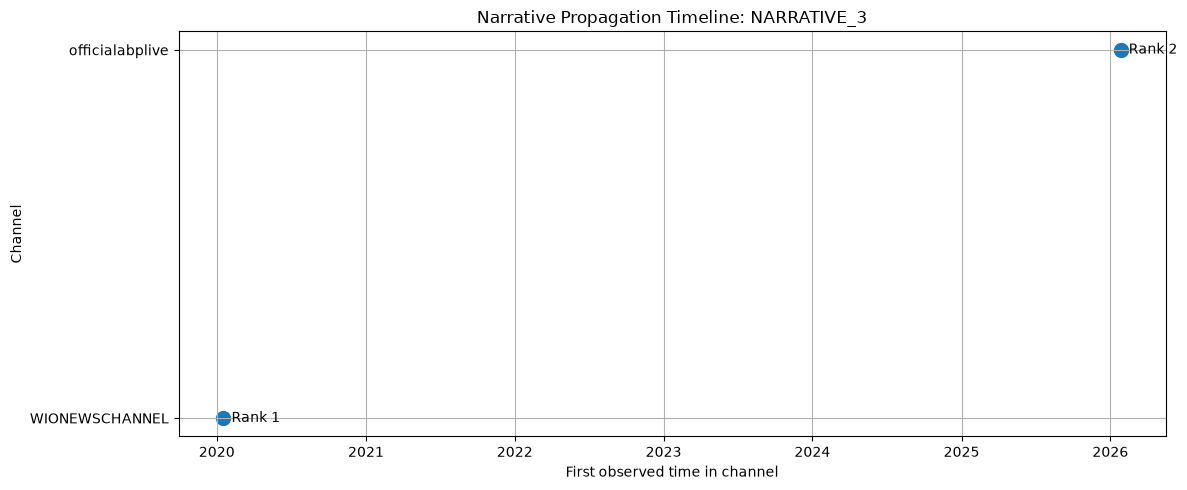

,narrative_id,narrative_label,channel,propagation_rank,propagation_role,first_channel_post_date,hours_after_first_observed,total_messages
24,NARRATIVE_3,Semantic Narrative 3,WIONEWSCHANNEL,1,first_observed,2020-01-17 10:10:12+00:00,0.0,391
25,NARRATIVE_3,Semantic Narrative 3,officialabplive,2,early_adopter,2026-01-26 10:46:03+00:00,52824.6,134


In [112]:
# ============================================================
# SERIAL 6C — CELL 10
# Plot propagation timeline for one narrative
# ============================================================

import matplotlib.pyplot as plt

# Select the most cross-channel narrative by default
selected_narrative_id = narrative_propagation_overview.iloc[0]["narrative_id"]

plot_df = propagation_sequence[
    propagation_sequence["narrative_id"] == selected_narrative_id
].copy()

plot_df = plot_df.sort_values("first_channel_post_date")

plt.figure(figsize=(12, 5))

plt.scatter(
    plot_df["first_channel_post_date"],
    plot_df["channel"],
    s=100
)

for _, row in plot_df.iterrows():
    plt.text(
        row["first_channel_post_date"],
        row["channel"],
        f"  Rank {row['propagation_rank']}",
        va="center"
    )

plt.title(f"Narrative Propagation Timeline: {selected_narrative_id}")
plt.xlabel("First observed time in channel")
plt.ylabel("Channel")
plt.grid(True)
plt.tight_layout()
plt.show()

display(
    plot_df[
        [
            "narrative_id",
            "narrative_label",
            "channel",
            "propagation_rank",
            "propagation_role",
            "first_channel_post_date",
            "hours_after_first_observed",
            "total_messages"
        ]
    ]
)

In [113]:
# ============================================================
# SERIAL 6C — CELL 11
# Build narrative propagation edges
# ============================================================

propagation_edge_rows = []

for narrative_id in sorted(propagation_sequence["narrative_id"].unique()):

    subset = propagation_sequence[
        propagation_sequence["narrative_id"] == narrative_id
    ].copy()

    subset = subset.sort_values("propagation_rank")

    if len(subset) < 2:
        continue

    rows = subset.to_dict("records")

    for i in range(len(rows) - 1):

        source = rows[i]["channel"]
        target = rows[i + 1]["channel"]

        propagation_edge_rows.append({
            "source": source,
            "target": target,
            "narrative_id": narrative_id,
            "narrative_label": rows[i]["narrative_label"],
            "edge_type": "narrative_propagation",
            "source_rank": rows[i]["propagation_rank"],
            "target_rank": rows[i + 1]["propagation_rank"],
            "lag_hours": rows[i + 1]["hours_after_first_observed"] - rows[i]["hours_after_first_observed"]
        })

propagation_edges = pd.DataFrame(propagation_edge_rows)

display(propagation_edges.head(30))

,source,target,narrative_id,narrative_label,edge_type,source_rank,target_rank,lag_hours
0,WIONEWSCHANNEL,officialabplive,NARRATIVE_1,Semantic Narrative 1,narrative_propagation,1,2,52800.74
1,WIONEWSCHANNEL,officialabplive,NARRATIVE_11,Semantic Narrative 11,narrative_propagation,1,2,52477.24
2,WIONEWSCHANNEL,officialabplive,NARRATIVE_12,Semantic Narrative 12,narrative_propagation,1,2,51675.64
3,WIONEWSCHANNEL,officialabplive,NARRATIVE_13,Semantic Narrative 13,narrative_propagation,1,2,52727.73
4,WIONEWSCHANNEL,officialabplive,NARRATIVE_14,Semantic Narrative 14,narrative_propagation,1,2,44692.51
5,WIONEWSCHANNEL,officialabplive,NARRATIVE_15,Semantic Narrative 15,narrative_propagation,1,2,53182.64
6,WIONEWSCHANNEL,officialabplive,NARRATIVE_16,Semantic Narrative 16,narrative_propagation,1,2,50784.66
7,WIONEWSCHANNEL,officialabplive,NARRATIVE_17,Semantic Narrative 17,narrative_propagation,1,2,52462.84
8,WIONEWSCHANNEL,officialabplive,NARRATIVE_18,Semantic Narrative 18,narrative_propagation,1,2,48837.99
9,WIONEWSCHANNEL,officialabplive,NARRATIVE_19,Semantic Narrative 19,narrative_propagation,1,2,52294.43


In [114]:
# ============================================================
# SERIAL 6C — CELL 12
# Analyst interpretation
# ============================================================

print("=" * 80)
print("NARRATIVE PROPAGATION ENGINE — ANALYST INTERPRETATION")
print("=" * 80)

print(f"\nNarratives analysed: {narrative_timeline['narrative_id'].nunique()}")
print(f"Channels analysed  : {narrative_timeline['channel'].nunique()}")
print(f"Propagation edges  : {len(propagation_edges)}")

print("\nChannels most often first observed:")
display(first_observed_channel_summary.head(10))

print("\nChannel role summary:")
display(channel_role_summary)

if len(narrative_propagation_overview) > 0:
    top_spread = narrative_propagation_overview.iloc[0]

    print("\nMost widely spread narrative:")
    print(f"• Narrative ID: {top_spread['narrative_id']}")
    print(f"• Label: {top_spread['narrative_label']}")
    print(f"• Channels involved: {top_spread['channels_involved']}")
    print(f"• Total messages: {top_spread['total_messages']}")
    print(f"• Spread duration hours: {top_spread['max_hours_to_spread']}")

print("\nAnalyst notes:")
print("- First observed channel means earliest occurrence in the collected dataset.")
print("- It does not prove true origin.")
print("- Early adopter means among the first few monitored channels to post the narrative.")
print("- Later amplifier means the channel posted after earlier observed channels.")
print("- Propagation edges are useful for visualization, but should be interpreted cautiously.")
print("- This layer becomes much stronger as more channels are monitored.")

NARRATIVE PROPAGATION ENGINE — ANALYST INTERPRETATION

Narratives analysed: 20
Channels analysed  : 2
Propagation edges  : 16

Channels most often first observed:


,first_observed_channel,narratives_first_observed,narrative_ids
0,WIONEWSCHANNEL,18,"[NARRATIVE_15, NARRATIVE_2, NARRATIVE_8, NARRA..."
1,officialabplive,2,"[NARRATIVE_0, NARRATIVE_9]"



Channel role summary:


propagation_role,channel,early_adopter,first_observed,later_amplifier,total_narratives_participated
0,WIONEWSCHANNEL,0.0,18.0,0,18.0
1,officialabplive,16.0,2.0,0,18.0



Most widely spread narrative:
• Narrative ID: NARRATIVE_3
• Label: Semantic Narrative 3
• Channels involved: 2
• Total messages: 525
• Spread duration hours: 52824.6

Analyst notes:
- First observed channel means earliest occurrence in the collected dataset.
- It does not prove true origin.
- Early adopter means among the first few monitored channels to post the narrative.
- Later amplifier means the channel posted after earlier observed channels.
- Propagation edges are useful for visualization, but should be interpreted cautiously.
- This layer becomes much stronger as more channels are monitored.


# Channel Correlation Engine

## Objective

This section creates an explainable correlation score between every pair of Telegram channels.

The goal is not only to say that two channels are similar, but to explain why.

Each channel pair is scored across multiple evidence layers:

- Narrative similarity
- Shared narrative participation
- Source/reference overlap
- Shared domains
- Shared URLs
- Shared Telegram mentions
- Temporal posting correlation
- Narrative propagation relationship

The final output is an evidence-backed channel correlation table.

In [116]:
# ============================================================
# SERIAL 6D — CELL 1
# Validate required data for correlation engine
# ============================================================

required_base_objects = [
    "all_messages",
    "semantic_messages",
    "channel_narrative_matrix",
    "propagation_sequence"
]

for obj in required_base_objects:
    if obj not in globals():
        raise NameError(f"{obj} is missing. Run the previous serials first.")

print("Required objects found.")

print("Channels in all_messages:", all_messages["channel"].nunique())
print("Channels in semantic_messages:", semantic_messages["channel"].nunique())
print("Narrative matrix shape:", channel_narrative_matrix.shape)
print("Propagation rows:", len(propagation_sequence))

Required objects found.
Channels in all_messages: 2
Channels in semantic_messages: 2
Narrative matrix shape: (2, 20)
Propagation rows: 36


In [117]:
# ============================================================
# SERIAL 6D — CELL 2
# Rebuild source/reference overlap tables
# ============================================================

from urllib.parse import urlparse

corr_url_rows = []
corr_domain_rows = []
corr_mention_rows = []

for _, row in all_messages.iterrows():

    channel = row["channel"]
    message_id = row["message_id"]
    date = row["date"]
    message_link = row["message_link"]

    # URLs and domains
    urls = row.get("urls", [])

    if isinstance(urls, list):
        for url in urls:

            normalized_url = str(url).strip()

            if normalized_url.startswith("t.me/"):
                normalized_url = "https://" + normalized_url

            try:
                parsed = urlparse(normalized_url)
                domain = parsed.netloc.replace("www.", "").lower()
            except:
                domain = None

            if normalized_url:
                corr_url_rows.append({
                    "channel": channel,
                    "url": normalized_url,
                    "message_id": message_id,
                    "date": date,
                    "message_link": message_link
                })

            if domain:
                corr_domain_rows.append({
                    "channel": channel,
                    "domain": domain,
                    "url": normalized_url,
                    "message_id": message_id,
                    "date": date,
                    "message_link": message_link
                })

    # Mentions
    mentions = row.get("mentions", [])

    if isinstance(mentions, list):
        for mention in mentions:
            corr_mention_rows.append({
                "channel": channel,
                "mentioned_username": str(mention).lower(),
                "message_id": message_id,
                "date": date,
                "message_link": message_link
            })

corr_urls_df = pd.DataFrame(corr_url_rows)
corr_domains_df = pd.DataFrame(corr_domain_rows)
corr_mentions_df = pd.DataFrame(corr_mention_rows)

print("Correlation source/reference tables created.")
print("URLs:", len(corr_urls_df))
print("Domains:", len(corr_domains_df))
print("Mentions:", len(corr_mentions_df))

Correlation source/reference tables created.
URLs: 7377
Domains: 7377
Mentions: 59


In [118]:
# ============================================================
# SERIAL 6D — CELL 3
# Build temporal correlation matrix
# ============================================================

all_messages["date"] = pd.to_datetime(all_messages["date"], errors="coerce")
all_messages["date_only"] = all_messages["date"].dt.date

daily_activity = (
    all_messages
    .groupby(["channel", "date_only"])
    .size()
    .reset_index(name="message_count")
)

daily_pivot = daily_activity.pivot_table(
    index="date_only",
    columns="channel",
    values="message_count",
    fill_value=0
)

if daily_pivot.shape[1] > 1:
    daily_temporal_correlation = daily_pivot.corr()
else:
    daily_temporal_correlation = pd.DataFrame()

print("Daily temporal correlation matrix:")
display(daily_temporal_correlation)

Daily temporal correlation matrix:


channel,WIONEWSCHANNEL,officialabplive
channel,,
WIONEWSCHANNEL,1.00000,-0.43596
officialabplive,-0.43596,1.00000


In [119]:
# ============================================================
# SERIAL 6D — CELL 4
# Build propagation relationship summary
# ============================================================

propagation_pair_rows = []

if len(propagation_sequence) > 0:

    for narrative_id in propagation_sequence["narrative_id"].unique():

        subset = propagation_sequence[
            propagation_sequence["narrative_id"] == narrative_id
        ].copy()

        subset = subset.sort_values("propagation_rank")

        channels_in_narrative = subset["channel"].tolist()

        for i in range(len(channels_in_narrative)):
            for j in range(i + 1, len(channels_in_narrative)):

                source_channel = channels_in_narrative[i]
                target_channel = channels_in_narrative[j]

                source_rank = subset.iloc[i]["propagation_rank"]
                target_rank = subset.iloc[j]["propagation_rank"]

                source_time = subset.iloc[i]["first_channel_post_date"]
                target_time = subset.iloc[j]["first_channel_post_date"]

                lag_hours = (
                    (target_time - source_time).total_seconds() / 3600
                )

                propagation_pair_rows.append({
                    "channel_a": source_channel,
                    "channel_b": target_channel,
                    "narrative_id": narrative_id,
                    "a_rank": source_rank,
                    "b_rank": target_rank,
                    "lag_hours": round(lag_hours, 2)
                })

propagation_pairs_df = pd.DataFrame(propagation_pair_rows)

print("Propagation pair rows:", len(propagation_pairs_df))
display(propagation_pairs_df.head())

Propagation pair rows: 16


,channel_a,channel_b,narrative_id,a_rank,b_rank,lag_hours
0,WIONEWSCHANNEL,officialabplive,NARRATIVE_1,1,2,52800.74
1,WIONEWSCHANNEL,officialabplive,NARRATIVE_11,1,2,52477.24
2,WIONEWSCHANNEL,officialabplive,NARRATIVE_12,1,2,51675.64
3,WIONEWSCHANNEL,officialabplive,NARRATIVE_13,1,2,52727.73
4,WIONEWSCHANNEL,officialabplive,NARRATIVE_14,1,2,44692.51


In [120]:
# ============================================================
# SERIAL 6D — CELL 5
# Helper functions for correlation scoring
# ============================================================

def safe_jaccard(set_a, set_b):
    """
    Jaccard similarity:
    shared items / total unique items.
    """
    set_a = set(set_a)
    set_b = set(set_b)

    union = set_a | set_b

    if len(union) == 0:
        return 0.0

    return len(set_a & set_b) / len(union)


def safe_corr_lookup(matrix, ch_a, ch_b):
    """
    Safely look up correlation between two channels.
    Returns 0 if missing.
    """
    try:
        return float(matrix.loc[ch_a, ch_b])
    except:
        return 0.0


def normalize_count(value, cap=10):
    """
    Convert a raw count to a 0-1 score.
    Anything above cap becomes 1.
    """
    if value <= 0:
        return 0.0
    return min(value / cap, 1.0)


def confidence_label(score):
    """
    Convert numeric correlation score into analyst-friendly label.
    """
    if score >= 0.80:
        return "Very High"
    elif score >= 0.65:
        return "High"
    elif score >= 0.45:
        return "Medium"
    elif score >= 0.25:
        return "Low"
    else:
        return "Very Low"

In [121]:
# ============================================================
# SERIAL 6D — CELL 6
# Build channel correlation evidence table
# ============================================================

from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

channels = sorted(all_messages["channel"].unique())

correlation_rows = []

for ch_a, ch_b in combinations(channels, 2):

    # ----------------------------
    # Narrative participation similarity
    # ----------------------------
    if ch_a in channel_narrative_matrix.index and ch_b in channel_narrative_matrix.index:
        vec_a = channel_narrative_matrix.loc[ch_a].values.reshape(1, -1)
        vec_b = channel_narrative_matrix.loc[ch_b].values.reshape(1, -1)

        narrative_similarity = float(
            cosine_similarity(vec_a, vec_b)[0][0]
        )
    else:
        narrative_similarity = 0.0

    # Shared narratives count
    if ch_a in channel_narrative_matrix.index and ch_b in channel_narrative_matrix.index:
        narratives_a = set(
            channel_narrative_matrix.loc[ch_a][channel_narrative_matrix.loc[ch_a] > 0].index
        )
        narratives_b = set(
            channel_narrative_matrix.loc[ch_b][channel_narrative_matrix.loc[ch_b] > 0].index
        )
        shared_narratives_count = len(narratives_a & narratives_b)
    else:
        shared_narratives_count = 0

    shared_narratives_score = normalize_count(
        shared_narratives_count,
        cap=5
    )

    # ----------------------------
    # Source/reference overlap
    # ----------------------------
    domains_a = set(
        corr_domains_df[corr_domains_df["channel"] == ch_a]["domain"]
    ) if len(corr_domains_df) else set()

    domains_b = set(
        corr_domains_df[corr_domains_df["channel"] == ch_b]["domain"]
    ) if len(corr_domains_df) else set()

    urls_a = set(
        corr_urls_df[corr_urls_df["channel"] == ch_a]["url"]
    ) if len(corr_urls_df) else set()

    urls_b = set(
        corr_urls_df[corr_urls_df["channel"] == ch_b]["url"]
    ) if len(corr_urls_df) else set()

    mentions_a = set(
        corr_mentions_df[corr_mentions_df["channel"] == ch_a]["mentioned_username"]
    ) if len(corr_mentions_df) else set()

    mentions_b = set(
        corr_mentions_df[corr_mentions_df["channel"] == ch_b]["mentioned_username"]
    ) if len(corr_mentions_df) else set()

    domain_overlap = safe_jaccard(domains_a, domains_b)
    url_overlap = safe_jaccard(urls_a, urls_b)
    mention_overlap = safe_jaccard(mentions_a, mentions_b)

    shared_domains_count = len(domains_a & domains_b)
    shared_urls_count = len(urls_a & urls_b)
    shared_mentions_count = len(mentions_a & mentions_b)

    # ----------------------------
    # Temporal correlation
    # ----------------------------
    temporal_similarity = safe_corr_lookup(
        daily_temporal_correlation,
        ch_a,
        ch_b
    )

    # Correlation can be negative. For relationship scoring,
    # negative correlation should not add positive weight.
    temporal_similarity = max(0.0, temporal_similarity)

    # ----------------------------
    # Propagation relationship
    # ----------------------------
    if len(propagation_pairs_df) > 0:

        pair_prop = propagation_pairs_df[
            (
                ((propagation_pairs_df["channel_a"] == ch_a) &
                 (propagation_pairs_df["channel_b"] == ch_b))
                |
                ((propagation_pairs_df["channel_a"] == ch_b) &
                 (propagation_pairs_df["channel_b"] == ch_a))
            )
        ]

        shared_propagation_count = pair_prop["narrative_id"].nunique()

        avg_lag_hours = (
            pair_prop["lag_hours"].abs().mean()
            if len(pair_prop) > 0 else None
        )

    else:
        shared_propagation_count = 0
        avg_lag_hours = None

    propagation_score = normalize_count(
        shared_propagation_count,
        cap=5
    )

    # ----------------------------
    # Weighted overall score
    # ----------------------------
    overall_score = (
        narrative_similarity * 0.30 +
        shared_narratives_score * 0.15 +
        domain_overlap * 0.10 +
        url_overlap * 0.10 +
        mention_overlap * 0.10 +
        temporal_similarity * 0.10 +
        propagation_score * 0.15
    )

    overall_score = round(float(overall_score), 4)

    correlation_rows.append({
        "channel_a": ch_a,
        "channel_b": ch_b,

        "overall_correlation_score": overall_score,
        "confidence": confidence_label(overall_score),

        "narrative_similarity": round(narrative_similarity, 4),
        "shared_narratives_count": shared_narratives_count,
        "shared_narratives_score": round(shared_narratives_score, 4),

        "domain_overlap": round(domain_overlap, 4),
        "shared_domains_count": shared_domains_count,

        "url_overlap": round(url_overlap, 4),
        "shared_urls_count": shared_urls_count,

        "mention_overlap": round(mention_overlap, 4),
        "shared_mentions_count": shared_mentions_count,

        "temporal_similarity": round(temporal_similarity, 4),

        "shared_propagation_count": shared_propagation_count,
        "propagation_score": round(propagation_score, 4),
        "avg_lag_hours": avg_lag_hours
    })

channel_correlation_df = pd.DataFrame(correlation_rows).sort_values(
    "overall_correlation_score",
    ascending=False
)

display(channel_correlation_df)

,channel_a,channel_b,overall_correlation_score,confidence,narrative_similarity,shared_narratives_count,shared_narratives_score,domain_overlap,shared_domains_count,url_overlap,shared_urls_count,mention_overlap,shared_mentions_count,temporal_similarity,shared_propagation_count,propagation_score,avg_lag_hours
0,WIONEWSCHANNEL,officialabplive,0.3878,Low,0.2927,16,1.0,0.0,0,0.0,0,0.0,0,0.0,16,1.0,51717.3


In [122]:
# ============================================================
# SERIAL 6D — CELL 7
# Generate analyst explanation for each channel pair
# ============================================================

def build_correlation_explanation(row):
    """
    Creates a readable explanation for why two channels are correlated.
    """

    reasons = []

    if row["narrative_similarity"] >= 0.7:
        reasons.append(
            f"high narrative similarity ({row['narrative_similarity']})"
        )

    if row["shared_narratives_count"] > 0:
        reasons.append(
            f"{int(row['shared_narratives_count'])} shared narrative clusters"
        )

    if row["shared_domains_count"] > 0:
        reasons.append(
            f"{int(row['shared_domains_count'])} shared domains"
        )

    if row["shared_urls_count"] > 0:
        reasons.append(
            f"{int(row['shared_urls_count'])} shared exact URLs"
        )

    if row["shared_mentions_count"] > 0:
        reasons.append(
            f"{int(row['shared_mentions_count'])} shared Telegram mentions"
        )

    if row["temporal_similarity"] >= 0.5:
        reasons.append(
            f"similar daily posting pattern ({row['temporal_similarity']})"
        )

    if row["shared_propagation_count"] > 0:
        reasons.append(
            f"co-participation in {int(row['shared_propagation_count'])} narrative propagation chains"
        )

    if not reasons:
        reasons.append("limited observable overlap in the current dataset")

    return "; ".join(reasons)


channel_correlation_df["evidence_explanation"] = channel_correlation_df.apply(
    build_correlation_explanation,
    axis=1
)

display(
    channel_correlation_df[
        [
            "channel_a",
            "channel_b",
            "overall_correlation_score",
            "confidence",
            "evidence_explanation"
        ]
    ]
)

,channel_a,channel_b,overall_correlation_score,confidence,evidence_explanation
0,WIONEWSCHANNEL,officialabplive,0.3878,Low,16 shared narrative clusters; co-participation...


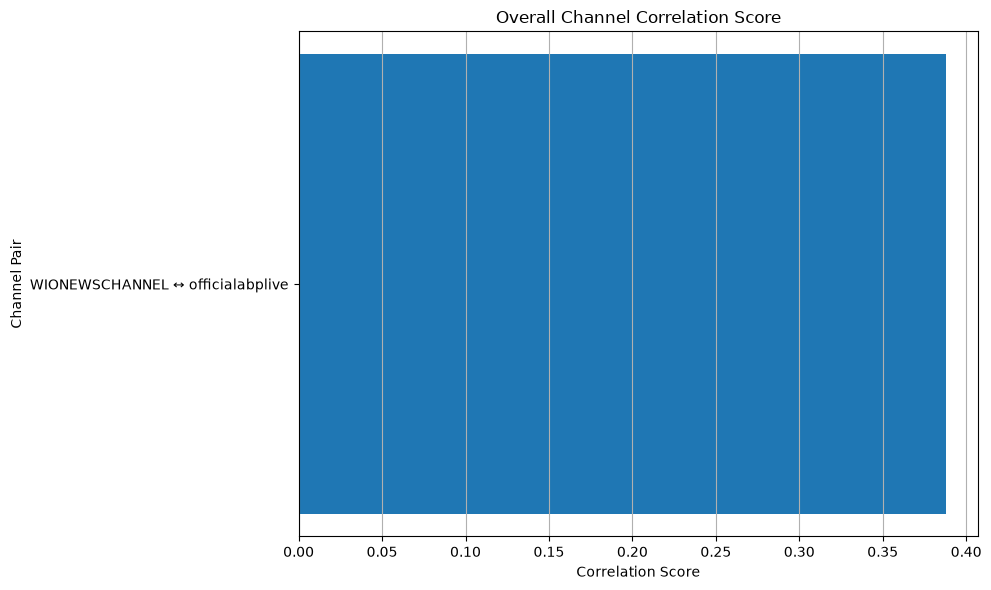

In [123]:
# ============================================================
# SERIAL 6D — CELL 8
# Plot overall channel correlation scores
# ============================================================

import matplotlib.pyplot as plt

if len(channel_correlation_df) > 0:

    plot_df = channel_correlation_df.copy()

    plot_df["pair"] = (
        plot_df["channel_a"] + " ↔ " + plot_df["channel_b"]
    )

    plot_df = plot_df.sort_values(
        "overall_correlation_score",
        ascending=True
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_df["pair"],
        plot_df["overall_correlation_score"]
    )

    plt.title("Overall Channel Correlation Score")
    plt.xlabel("Correlation Score")
    plt.ylabel("Channel Pair")
    plt.grid(axis="x")
    plt.tight_layout()

    plt.show()

else:
    print("No channel correlations available.")

In [124]:
# ============================================================
# SERIAL 6D — CELL 9
# Show strongest channel correlation evidence
# ============================================================

if len(channel_correlation_df) > 0:

    strongest = channel_correlation_df.iloc[0]

    print("=" * 80)
    print("STRONGEST CHANNEL CORRELATION")
    print("=" * 80)

    print(f"\nChannel pair:")
    print(f"• {strongest['channel_a']} ↔ {strongest['channel_b']}")

    print(f"\nOverall score:")
    print(f"• {strongest['overall_correlation_score']}")

    print(f"\nConfidence:")
    print(f"• {strongest['confidence']}")

    print("\nEvidence:")
    print(f"• Narrative similarity: {strongest['narrative_similarity']}")
    print(f"• Shared narrative clusters: {strongest['shared_narratives_count']}")
    print(f"• Shared domains: {strongest['shared_domains_count']}")
    print(f"• Shared exact URLs: {strongest['shared_urls_count']}")
    print(f"• Shared mentions: {strongest['shared_mentions_count']}")
    print(f"• Temporal similarity: {strongest['temporal_similarity']}")
    print(f"• Shared propagation chains: {strongest['shared_propagation_count']}")

    print("\nExplanation:")
    print(strongest["evidence_explanation"])

else:
    print("No correlations available.")

STRONGEST CHANNEL CORRELATION

Channel pair:
• WIONEWSCHANNEL ↔ officialabplive

Overall score:
• 0.3878

Confidence:
• Low

Evidence:
• Narrative similarity: 0.2927
• Shared narrative clusters: 16
• Shared domains: 0
• Shared exact URLs: 0
• Shared mentions: 0
• Temporal similarity: 0.0
• Shared propagation chains: 16

Explanation:
16 shared narrative clusters; co-participation in 16 narrative propagation chains


In [125]:
# ============================================================
# SERIAL 6D — CELL 10
# Build correlation network edges
# ============================================================

CORRELATION_EDGE_THRESHOLD = 0.25

correlation_edges = channel_correlation_df[
    channel_correlation_df["overall_correlation_score"] >= CORRELATION_EDGE_THRESHOLD
].copy()

correlation_edges = correlation_edges.rename(columns={
    "channel_a": "source",
    "channel_b": "target",
    "overall_correlation_score": "weight"
})

correlation_edges["edge_type"] = "channel_correlation"

display(
    correlation_edges[
        [
            "source",
            "target",
            "weight",
            "confidence",
            "edge_type",
            "evidence_explanation"
        ]
    ]
)

,source,target,weight,confidence,edge_type,evidence_explanation
0,WIONEWSCHANNEL,officialabplive,0.3878,Low,channel_correlation,16 shared narrative clusters; co-participation...


In [126]:
# ============================================================
# SERIAL 6D — CELL 11
# Save channel correlation outputs
# ============================================================

channel_correlation_df.to_csv(
    f"{OUTPUT_DIR}/channel_correlation_scores.csv",
    index=False
)

correlation_edges.to_csv(
    f"{OUTPUT_DIR}/channel_correlation_edges.csv",
    index=False
)

print("Saved:")
print(f"{OUTPUT_DIR}/channel_correlation_scores.csv")
print(f"{OUTPUT_DIR}/channel_correlation_edges.csv")

Saved:
telegram_osint_outputs/channel_correlation_scores.csv
telegram_osint_outputs/channel_correlation_edges.csv


In [127]:
# ============================================================
# SERIAL 6D — CELL 12
# Analyst interpretation
# ============================================================

print("=" * 80)
print("CHANNEL CORRELATION ENGINE — ANALYST INTERPRETATION")
print("=" * 80)

print(f"\nChannel pairs analysed: {len(channel_correlation_df)}")

if len(channel_correlation_df) > 0:

    top_pair = channel_correlation_df.iloc[0]

    print("\nHighest correlation pair:")
    print(f"• {top_pair['channel_a']} ↔ {top_pair['channel_b']}")
    print(f"• Overall score: {top_pair['overall_correlation_score']}")
    print(f"• Confidence: {top_pair['confidence']}")

    print("\nPrimary explanation:")
    print(f"• {top_pair['evidence_explanation']}")

print("\nAnalyst notes:")
print("- The score is evidence-based, not a standalone truth claim.")
print("- Narrative similarity is weighted heavily because this is a narrative intelligence workflow.")
print("- Source/reference overlap strengthens correlation when paired with narrative overlap.")
print("- Temporal similarity and propagation co-participation help identify behavioural relationships.")
print("- Correlation does not prove coordination.")
print("- Higher confidence means more independent evidence layers point in the same direction.")

CHANNEL CORRELATION ENGINE — ANALYST INTERPRETATION

Channel pairs analysed: 1

Highest correlation pair:
• WIONEWSCHANNEL ↔ officialabplive
• Overall score: 0.3878
• Confidence: Low

Primary explanation:
• 16 shared narrative clusters; co-participation in 16 narrative propagation chains

Analyst notes:
- The score is evidence-based, not a standalone truth claim.
- Narrative similarity is weighted heavily because this is a narrative intelligence workflow.
- Source/reference overlap strengthens correlation when paired with narrative overlap.
- Temporal similarity and propagation co-participation help identify behavioural relationships.
- Correlation does not prove coordination.
- Higher confidence means more independent evidence layers point in the same direction.


# Interactive Correlation Network Graph

## Objective

This section visualizes relationships between Telegram channels as an interactive network graph.

Each channel is represented as a node.

Each correlation relationship is represented as an edge.

The edge weight is based on the overall channel correlation score created in Serial 6D.

The graph helps identify:

- Highly connected channels
- Isolated channels
- Strongly correlated channel pairs
- Possible clusters or ecosystems
- Channels acting as bridges between groups

Important:

A correlation edge does not prove coordination. It represents observable similarity based on multiple evidence layers.

In [128]:
# ============================================================
# SERIAL 6E — CELL 1
# Validate required correlation objects
# ============================================================

required_objects = [
    "channel_correlation_df",
    "correlation_edges"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"{obj} is missing. Run Serial 6D first.")

print("Required correlation objects found.")
print("Channel correlation rows:", len(channel_correlation_df))
print("Correlation edges:", len(correlation_edges))

display(correlation_edges.head())

Required correlation objects found.
Channel correlation rows: 1
Correlation edges: 1


,source,target,weight,confidence,narrative_similarity,shared_narratives_count,shared_narratives_score,domain_overlap,shared_domains_count,url_overlap,shared_urls_count,mention_overlap,shared_mentions_count,temporal_similarity,shared_propagation_count,propagation_score,avg_lag_hours,evidence_explanation,edge_type
0,WIONEWSCHANNEL,officialabplive,0.3878,Low,0.2927,16,1.0,0.0,0,0.0,0,0.0,0,0.0,16,1.0,51717.3,16 shared narrative clusters; co-participation...,channel_correlation


In [130]:
# ============================================================
# SERIAL 6E — CELL 2
# Set graph threshold
# ============================================================

# You can tune this.
# Start low for small datasets.
GRAPH_CORRELATION_THRESHOLD = 0.25

graph_edges = channel_correlation_df[
    channel_correlation_df["overall_correlation_score"] >= GRAPH_CORRELATION_THRESHOLD
].copy()

print("Graph threshold:", GRAPH_CORRELATION_THRESHOLD)
print("Edges included:", len(graph_edges))

display(
    graph_edges[
        [
            "channel_a",
            "channel_b",
            "overall_correlation_score",
            "confidence",
            "evidence_explanation"
        ]
    ]
)

Graph threshold: 0.25
Edges included: 1


,channel_a,channel_b,overall_correlation_score,confidence,evidence_explanation
0,WIONEWSCHANNEL,officialabplive,0.3878,Low,16 shared narrative clusters; co-participation...


In [131]:
# ============================================================
# SERIAL 6E — CELL 3
# Build NetworkX correlation graph
# ============================================================

import networkx as nx

G_correlation = nx.Graph()

# Add all channels as nodes, even if they have no edges
for channel in sorted(all_messages["channel"].unique()):

    channel_message_count = len(
        all_messages[all_messages["channel"] == channel]
    )

    G_correlation.add_node(
        channel,
        node_type="channel",
        message_count=channel_message_count,
        title=f"{channel}\nMessages: {channel_message_count}"
    )


# Add correlation edges
for _, row in graph_edges.iterrows():

    G_correlation.add_edge(
        row["channel_a"],
        row["channel_b"],
        weight=float(row["overall_correlation_score"]),
        confidence=row["confidence"],
        narrative_similarity=row["narrative_similarity"],
        shared_narratives_count=row["shared_narratives_count"],
        shared_domains_count=row["shared_domains_count"],
        shared_urls_count=row["shared_urls_count"],
        shared_mentions_count=row["shared_mentions_count"],
        temporal_similarity=row["temporal_similarity"],
        shared_propagation_count=row["shared_propagation_count"],
        evidence_explanation=row["evidence_explanation"]
    )

print("Correlation graph created.")
print("Nodes:", G_correlation.number_of_nodes())
print("Edges:", G_correlation.number_of_edges())

Correlation graph created.
Nodes: 2
Edges: 1


In [132]:
# ============================================================
# SERIAL 6E — CELL 4
# Calculate graph metrics
# ============================================================

if G_correlation.number_of_nodes() > 0:

    degree_centrality = nx.degree_centrality(G_correlation)

    if G_correlation.number_of_edges() > 0:
        betweenness_centrality = nx.betweenness_centrality(G_correlation)
        pagerank_scores = nx.pagerank(G_correlation, weight="weight")
    else:
        betweenness_centrality = {node: 0 for node in G_correlation.nodes()}
        pagerank_scores = {node: 0 for node in G_correlation.nodes()}

    graph_metric_rows = []

    for node in G_correlation.nodes():

        graph_metric_rows.append({
            "channel": node,
            "degree": G_correlation.degree(node),
            "degree_centrality": round(degree_centrality.get(node, 0), 4),
            "betweenness_centrality": round(betweenness_centrality.get(node, 0), 4),
            "pagerank": round(pagerank_scores.get(node, 0), 4),
            "message_count": G_correlation.nodes[node].get("message_count", 0)
        })

    graph_metrics_df = pd.DataFrame(graph_metric_rows).sort_values(
        ["pagerank", "degree_centrality"],
        ascending=False
    )

    display(graph_metrics_df)

else:
    graph_metrics_df = pd.DataFrame()
    print("No graph nodes found.")

,channel,degree,degree_centrality,betweenness_centrality,pagerank,message_count
0,WIONEWSCHANNEL,1,1.0,0.0,0.5,2762
1,officialabplive,1,1.0,0.0,0.5,3000


In [133]:
# ============================================================
# SERIAL 6E — CELL 5
# Add graph metrics back to NetworkX nodes
# ============================================================

if len(graph_metrics_df) > 0:

    metrics_lookup = graph_metrics_df.set_index("channel").to_dict("index")

    for node in G_correlation.nodes():

        metrics = metrics_lookup.get(node, {})

        G_correlation.nodes[node]["degree"] = metrics.get("degree", 0)
        G_correlation.nodes[node]["degree_centrality"] = metrics.get("degree_centrality", 0)
        G_correlation.nodes[node]["betweenness_centrality"] = metrics.get("betweenness_centrality", 0)
        G_correlation.nodes[node]["pagerank"] = metrics.get("pagerank", 0)

print("Graph metrics added to nodes.")

Graph metrics added to nodes.


In [138]:
# ============================================================
# SERIAL 6E — CELL 6
# Create interactive PyVis correlation graph
# Fixed for Jupyter display using cdn_resources="in_line"
# ============================================================

from pyvis.network import Network

net = Network(
    height="750px",
    width="100%",
    bgcolor="#ffffff",
    font_color="#000000",
    notebook=True,
    cdn_resources="in_line"   # Important for Jupyter display
)

# Improve physics layout
net.barnes_hut(
    gravity=-50000,
    central_gravity=0.3,
    spring_length=200,
    spring_strength=0.05,
    damping=0.09
)

# Add nodes
for node, attrs in G_correlation.nodes(data=True):

    message_count = attrs.get("message_count", 0)
    degree = attrs.get("degree", 0)
    pagerank = attrs.get("pagerank", 0)
    betweenness = attrs.get("betweenness_centrality", 0)

    node_size = 20 + (degree * 8)

    node_title = f"""
    <b>{node}</b><br>
    Type: Channel<br>
    Messages: {message_count}<br>
    Degree: {degree}<br>
    PageRank: {pagerank}<br>
    Betweenness: {betweenness}
    """

    net.add_node(
        node,
        label=node,
        title=node_title,
        size=node_size
    )

# Add edges
for source, target, attrs in G_correlation.edges(data=True):

    weight = attrs.get("weight", 0)
    edge_width = 1 + (weight * 8)

    edge_title = f"""
    <b>{source} ↔ {target}</b><br>
    Overall correlation: {weight}<br>
    Confidence: {attrs.get("confidence")}<br>
    Narrative similarity: {attrs.get("narrative_similarity")}<br>
    Shared narratives: {attrs.get("shared_narratives_count")}<br>
    Shared domains: {attrs.get("shared_domains_count")}<br>
    Shared URLs: {attrs.get("shared_urls_count")}<br>
    Shared mentions: {attrs.get("shared_mentions_count")}<br>
    Temporal similarity: {attrs.get("temporal_similarity")}<br>
    Shared propagation chains: {attrs.get("shared_propagation_count")}<br>
    <br>
    Evidence:<br>
    {attrs.get("evidence_explanation")}
    """

    net.add_edge(
        source,
        target,
        value=weight,
        width=edge_width,
        title=edge_title
    )

# Enable interactive physics controls
net.show_buttons(filter_=["physics"])

output_graph_path = f"{OUTPUT_DIR}/interactive_correlation_network.html"

# Save graph
net.write_html(output_graph_path)

print("Interactive graph saved to:")
print(output_graph_path)

Interactive graph saved to:
telegram_osint_outputs/interactive_correlation_network.html


In [139]:
from IPython.display import IFrame, display

display(
    IFrame(
        src=output_graph_path,
        width="100%",
        height="800px"
    )
)

In [135]:
# ============================================================
# SERIAL 6E — CELL 8
# Analyst interpretation
# ============================================================

print("=" * 80)
print("INTERACTIVE CORRELATION NETWORK — ANALYST INTERPRETATION")
print("=" * 80)

print(f"\nGraph nodes: {G_correlation.number_of_nodes()}")
print(f"Graph edges: {G_correlation.number_of_edges()}")
print(f"Graph threshold: {GRAPH_CORRELATION_THRESHOLD}")

if len(graph_metrics_df) > 0:

    top_pagerank = graph_metrics_df.iloc[0]

    print("\nMost central channel by PageRank:")
    print(f"• {top_pagerank['channel']}")
    print(f"• PageRank: {top_pagerank['pagerank']}")

    top_degree = graph_metrics_df.sort_values(
        "degree",
        ascending=False
    ).iloc[0]

    print("\nMost connected channel:")
    print(f"• {top_degree['channel']}")
    print(f"• Degree: {top_degree['degree']}")

    top_bridge = graph_metrics_df.sort_values(
        "betweenness_centrality",
        ascending=False
    ).iloc[0]

    print("\nPotential bridge channel:")
    print(f"• {top_bridge['channel']}")
    print(f"• Betweenness centrality: {top_bridge['betweenness_centrality']}")

print("\nAnalyst notes:")
print("- Nodes represent Telegram channels.")
print("- Edges represent evidence-backed channel correlation.")
print("- Thicker edges indicate stronger correlation.")
print("- Hover over edges to inspect evidence.")
print("- PageRank highlights channels connected to other important channels.")
print("- Betweenness centrality can indicate bridge channels.")
print("- This graph does not prove coordination; it visualizes observable similarity and relationship evidence.")

INTERACTIVE CORRELATION NETWORK — ANALYST INTERPRETATION

Graph nodes: 2
Graph edges: 1
Graph threshold: 0.25

Most central channel by PageRank:
• WIONEWSCHANNEL
• PageRank: 0.5

Most connected channel:
• WIONEWSCHANNEL
• Degree: 1

Potential bridge channel:
• WIONEWSCHANNEL
• Betweenness centrality: 0.0

Analyst notes:
- Nodes represent Telegram channels.
- Edges represent evidence-backed channel correlation.
- Thicker edges indicate stronger correlation.
- Hover over edges to inspect evidence.
- PageRank highlights channels connected to other important channels.
- Betweenness centrality can indicate bridge channels.
- This graph does not prove coordination; it visualizes observable similarity and relationship evidence.


In [136]:
# ============================================================
# SERIAL 6E — CELL 9
# Save graph metrics
# ============================================================

graph_metrics_df.to_csv(
    f"{OUTPUT_DIR}/correlation_graph_metrics.csv",
    index=False
)

print("Saved graph metrics to:")
print(f"{OUTPUT_DIR}/correlation_graph_metrics.csv")

Saved graph metrics to:
telegram_osint_outputs/correlation_graph_metrics.csv
